03_Health_Evaluation.ipynb (v4 — Shape-Template Margin Loss + Per-View Thresholds)

Automatically generated by Colab.

# 🌿 VedaVision — Module 2
# Notebook 03 — Health Evaluation Pipeline (v4)

---
### What changed from v3

**1. Margin loss: reference shape template instead of a single hull ratio**

v3 estimated margin loss with one number (leaf area / convex hull area)
compared to a species baseline. That's a rough proxy -- it can't tell
"this exact notch is missing" from "leaves of this species are just a
bit concave here naturally" as precisely as actually overlaying the
damaged leaf onto what a healthy leaf normally looks like.

v4 builds a real reference shape per species:
  - Every healthy calibration leaf mask (both top AND bottom photos --
    the physical outline is the same leaf either way, so pooling both
    views just gives more data for the same shape) is aligned to a
    common canonical pose: PCA rotation to make the leaf vertical, tip
    pointing up, rescaled to a common length.
  - The aligned masks are averaged into a probability template: for
    each canvas pixel, what fraction of healthy reference leaves had
    tissue there.
  - A query leaf is aligned the same way, then scored by how much of
    the template's "usually-leaf" area is actually present. Missing
    area = margin loss.
  - Falls back to the old hull-ratio heuristic automatically for any
    species you haven't calibrated a shape template for yet.

**2. Colour thresholds are now calibrated PER VIEW (top vs bottom), not
just per species**

The adaxial (top) and abaxial (bottom) leaf surfaces genuinely look
different -- bottom is often paler, duller, sometimes fuzzy, less waxy.
One shared colour threshold risks flagging a healthy pale underside as
damage, using thresholds tuned on the glossier top side -- the same
class of mistake as the original Diya Na bug, one level down. So
`SPECIES_THRESHOLD_OVERRIDES` is now nested `{species: {'top': {...},
'bottom': {...}}}`, and `evaluate_full_leaf_health` automatically passes
the correct view when scoring each photo.

Shape templates, by contrast, are NOT per-view -- the leaf's edge outline
doesn't change depending on which side faces the camera, so combining
top+bottom calibration photos for shape just means more usable data.

---
### Calibration folder structure (updated):
```
health_calibration/species_name/healthy/top/*.jpg
health_calibration/species_name/healthy/bottom/*.jpg
health_calibration/species_name/damaged/top/*.jpg      (optional)
health_calibration/species_name/damaged/bottom/*.jpg   (optional)
```

---
## Cell 1 — Install Libraries

In [ ]:
!pip install opencv-python-headless scikit-image matplotlib numpy tqdm pandas -q
print('✅ Libraries installed!')

## Cell 2 — Import Libraries

In [1]:
import os
import re
import base64
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
import gc
from glob import glob
from tqdm import tqdm

In [2]:
print('✅ All libraries imported!')

✅ All libraries imported!


## Cell 3 — Mount Google Drive & Configure Paths

In [3]:
HEALTH_RAW_PATH         = 'C:/Users/User/Documents/UOM/L4S2/Research/health/Health_raw'
HEALTH_CALIBRATION_PATH = 'C:/Users/User/Documents/UOM/L4S2/Research/health/health_calibration'
HEALTH_RESULTS_PATH     = 'C:/Users/User/Documents/UOM/L4S2/Research/health/health_results'
LOGS_PATH               = 'C:/Users/User/Documents/UOM/L4S2/Research/logs'

In [4]:
VIEWS     = ['top', 'bottom']
WORK_SIZE = (512, 512)

In [5]:
# --------------------------------------------------------------------------
# Colour-quality thresholds. Structure: {species: {'top': {...}, 'bottom': {...}}}
# Only include keys that differ from DEFAULT_THRESHOLDS -- get_thresholds()
# fills in the rest automatically.
# --------------------------------------------------------------------------
DEFAULT_THRESHOLDS = {
    'HEALTHY_HUE_RANGE': (35, 85),
    'HEALTHY_MIN_SAT': 40,
    'HEALTHY_MIN_VAL': 40,
    'YELLOW_HUE_RANGE': (20, 35),
    'YELLOW_MIN_SAT': 40,
    'BROWN_HUE_RANGE': (5, 25),
    'BROWN_MAX_VAL': 150,
    'BLACK_MAX_VAL': 60,
    'BLACK_MAX_SAT': 60,
    'PALE_MAX_SAT': 30,
    'PALE_MIN_VAL': 200,
}

In [6]:
MIN_DAMAGE_BLOB_AREA = 15

In [52]:
SPECIES_THRESHOLD_OVERRIDES = {
    'Diya_Na': {'top': {'HEALTHY_HUE_RANGE': (34, 43), 'HEALTHY_MIN_SAT': 78, 'HEALTHY_MIN_VAL': 11, 'BLACK_MAX_VAL': 33, 'BLACK_MAX_SAT': 204}, 'bottom': {'HEALTHY_HUE_RANGE': (28, 39), 'HEALTHY_MIN_SAT': 106, 'HEALTHY_MIN_VAL': 39, 'BLACK_MAX_VAL': 56, 'BLACK_MAX_SAT': 156}},
    'Gammiris': {'top': {'HEALTHY_HUE_RANGE': (36, 47), 'HEALTHY_MIN_SAT': 72, 'HEALTHY_MIN_VAL': 18, 'BLACK_MAX_VAL': 44, 'BLACK_MAX_SAT': 188}, 'bottom': {'HEALTHY_HUE_RANGE': (29, 39), 'HEALTHY_MIN_SAT': 53, 'HEALTHY_MIN_VAL': 57, 'BLACK_MAX_VAL': 75, 'BLACK_MAX_SAT': 104}},
    'Ingini': {'top': {'HEALTHY_HUE_RANGE': (36, 48), 'HEALTHY_MIN_SAT': 42, 'HEALTHY_MIN_VAL': 10, 'BLACK_MAX_VAL': 46, 'BLACK_MAX_SAT': 173}, 'bottom': {'HEALTHY_HUE_RANGE': (34, 43), 'HEALTHY_MIN_SAT': 65, 'HEALTHY_MIN_VAL': 29, 'BLACK_MAX_VAL': 51, 'BLACK_MAX_SAT': 131}},
    'Iriveriya': {'top': {'HEALTHY_HUE_RANGE': (31, 40), 'HEALTHY_MIN_SAT': 118, 'HEALTHY_MIN_VAL': 20, 'BLACK_MAX_VAL': 49, 'BLACK_MAX_SAT': 218}, 'bottom': {'HEALTHY_HUE_RANGE': (29, 38), 'HEALTHY_MIN_SAT': 69, 'HEALTHY_MIN_VAL': 45, 'BLACK_MAX_VAL': 81, 'BLACK_MAX_SAT': 121}},
    'Kapparawalliya': {'top': {'HEALTHY_HUE_RANGE': (28, 44), 'HEALTHY_MIN_SAT': 96, 'HEALTHY_MIN_VAL': 19, 'BLACK_MAX_VAL': 54, 'BLACK_MAX_SAT': 206}, 'bottom': {'HEALTHY_HUE_RANGE': (28, 39), 'HEALTHY_MIN_SAT': 62, 'HEALTHY_MIN_VAL': 49, 'BLACK_MAX_VAL': 78, 'BLACK_MAX_SAT': 121}},
    'Kora_Kaha': {'top': {'HEALTHY_HUE_RANGE': (36, 48), 'HEALTHY_MIN_SAT': 56, 'HEALTHY_MIN_VAL': 9, 'BLACK_MAX_VAL': 20, 'BLACK_MAX_SAT': 198}, 'bottom': {'HEALTHY_HUE_RANGE': (34, 37), 'HEALTHY_MIN_SAT': 86, 'HEALTHY_MIN_VAL': 34, 'BLACK_MAX_VAL': 46, 'BLACK_MAX_SAT': 184}},
    'Kuringchan': {'top': {'HEALTHY_HUE_RANGE': (36, 43), 'HEALTHY_MIN_SAT': 129, 'HEALTHY_MIN_VAL': 14, 'BLACK_MAX_VAL': 31, 'BLACK_MAX_SAT': 213}, 'bottom': {'HEALTHY_HUE_RANGE': (33, 35), 'HEALTHY_MIN_SAT': 118, 'HEALTHY_MIN_VAL': 52, 'BLACK_MAX_VAL': 62, 'BLACK_MAX_SAT': 177}},
    'Kurundu': {'top': {'HEALTHY_HUE_RANGE': (32, 51), 'HEALTHY_MIN_SAT': 44, 'HEALTHY_MIN_VAL': 13, 'BLACK_MAX_VAL': 41, 'BLACK_MAX_SAT': 146}, 'bottom': {'HEALTHY_HUE_RANGE': (29, 43), 'HEALTHY_MIN_SAT': 34, 'HEALTHY_MIN_VAL': 23, 'BLACK_MAX_VAL': 76, 'BLACK_MAX_SAT': 84}},
    'Masbadda': {'top': {'HEALTHY_HUE_RANGE': (34, 45), 'HEALTHY_MIN_SAT': 87, 'HEALTHY_MIN_VAL': 14, 'BLACK_MAX_VAL': 28, 'BLACK_MAX_SAT': 235}, 'bottom': {'HEALTHY_HUE_RANGE': (29, 37), 'HEALTHY_MIN_SAT': 112, 'HEALTHY_MIN_VAL': 25, 'BLACK_MAX_VAL': 62, 'BLACK_MAX_SAT': 196}},
    'Na': {'top': {'HEALTHY_HUE_RANGE': (34, 45), 'HEALTHY_MIN_SAT': 51, 'HEALTHY_MIN_VAL': 13, 'BLACK_MAX_VAL': 34, 'BLACK_MAX_SAT': 191}, 'bottom': {'HEALTHY_HUE_RANGE': (23, 125), 'HEALTHY_MIN_SAT': 13, 'HEALTHY_MIN_VAL': 77, 'BLACK_MAX_VAL': 101, 'BLACK_MAX_SAT': 43}},
    'Rathu_Koboleela': {'top': {'HEALTHY_HUE_RANGE': (35, 43), 'HEALTHY_MIN_SAT': 101, 'HEALTHY_MIN_VAL': 27, 'BLACK_MAX_VAL': 55, 'BLACK_MAX_SAT': 162}, 'bottom': {'HEALTHY_HUE_RANGE': (31, 40), 'HEALTHY_MIN_SAT': 81, 'HEALTHY_MIN_VAL': 36, 'BLACK_MAX_VAL': 68, 'BLACK_MAX_SAT': 117}},
    'Sudu_Koboleela': {'top': {'HEALTHY_HUE_RANGE': (35, 44), 'HEALTHY_MIN_SAT': 109, 'HEALTHY_MIN_VAL': 18, 'BLACK_MAX_VAL': 47, 'BLACK_MAX_SAT': 184}, 'bottom': {'HEALTHY_HUE_RANGE': (30, 40), 'HEALTHY_MIN_SAT': 78, 'HEALTHY_MIN_VAL': 37, 'BLACK_MAX_VAL': 68, 'BLACK_MAX_SAT': 118}},
    'Wali_Kaha': {'top': {'HEALTHY_HUE_RANGE': (35, 48), 'HEALTHY_MIN_SAT': 48, 'HEALTHY_MIN_VAL': 14, 'BLACK_MAX_VAL': 18, 'BLACK_MAX_SAT': 195}, 'bottom': {'HEALTHY_HUE_RANGE': (30, 35), 'HEALTHY_MIN_SAT': 121, 'HEALTHY_MIN_VAL': 48, 'BLACK_MAX_VAL': 56, 'BLACK_MAX_SAT': 192}},
}

In [8]:
# --------------------------------------------------------------------------
# Structural damage config
# --------------------------------------------------------------------------
BG_COLOR_TOLERANCE = 35
HOLE_BRIDGE_BREAK_PX = 5

In [9]:
# Shape-template alignment canvas (used for both building templates and
# scoring query leaves against them -- must match between the two)
SHAPE_CANVAS_SIZE = 400
SHAPE_TARGET_LENGTH = 340

In [10]:
# Fallback hull-ratio heuristic, used ONLY for species with no shape
# template calibrated yet.
DEFAULT_HULL_RATIO_BASELINE = 0.88
SPECIES_HULL_BASELINE = {
    # 'Kuringchan': 0.79,
}

In [53]:
# Per-species shape templates, stored as base64-encoded PNG (grayscale
# probability map, 0-255). Populated by calibrate_species() -> Cell 14 export.
SPECIES_SHAPE_TEMPLATES_B64 = {
    'Diya_Na': 'iVBORw0KGgoAAAANSUhEUgAAAZAAAAGQCAAAAACl1GkQAAAeqklEQVR4Ae3BrZojRrKw2zdZBAyYCROqYME2bGhDX+WhGxq6oaAEE2bCgBHwqGfm23t+7HaJKeaptRqfXkrj00tpfHopjU8vpfHppTQ+vZTGp5fS+PRSGp9eSuPTS2l8eimNTy+l8emlND69lManl9L49FIan15K49NLafyXkOS/QuO/g0Dy36Dx30Eg+U6S0hr/HQRIQJRICmsUJDwkkvwvARIwxEnqatRjEDwoASTfiQIuGGSQlNUoRxQCUAi+S8BAMsDIgJSkqEY5ohCoQAYPSiSGmLsiSSQWSVGNekQjESNxAQUkQw0iRYMklEhqalQjifBgJJFgCKBISjpCCgk4NTWKEY0UHlRSPAExUNFQ4oQipCQ4NTVKEZTgb1QgnQczMAH8IJZsS4ikpEYlAhqQAoqgTpAg2lVUnKU8OA+RlNQoRAANSAEFUYcAjQHWwd1R5PAQSUmNQoR/SEElRSP5TgzMyEgikUMokZTUqET4uxQUSQsSczoKHVLSHclwhUgqapQikAIkBiauhAZqkmKAxgnIyFAiqahRi/A3KQomrkgiqIVaaCgrIANXIqmoUYtACt8pYqThdFcTJVBzuQcZkOBU1KhF+DsNVDAFwsAwMkyD5ZBBglNRoxbh7zQwNAaIhiJqAQpxNmRA4lTUKEb4Gw1UlJ6CIpaYpKAe6ZsM1HEqahQjQApKqJjGCAMVDQNF3DMWZCgeSUGNagQSURAVjWGhAkMcFeCEu5OAB0k9jWoEElFEDUkTtVBMSFHJcPf0SEnCSepplCOQosgAQWVISnYUhGTnTg9I2CT1NMoRSFExSyxUJooFlqIE/nAISDZJPY1yhAe1TmKh3VDrxxASwj23Z0CyISmnUY7wYGakqBhqMiQtNBIiN34ig8SDpJxGPQJqJqSomGLWGYGGJ8GJ9I1DepCU06hHUDMBRQwV084E0iMJVrpHBulEUk6jHsEGAkpXSbEhZmgkcSAO7h4OnkFSTaMgMxNAzQTUTGxqZGSkg3vkdgdOkFTTKKjbCFC6oYKpyVScSHdgp+/0AHeSahoFdTMlVMwUM1GmQSThGaS77wwHd5JqGgX1YTyYiaET5A2IBI+MjBPuucnASYpp1NPVDMRQE6ZKTuPBEdwzMo57nEjCSYpp1NNtgKgYKmamYsqDI6SHZ/h3ByIjKaZRjoyuIGqGMMQeku8CcMcfjscBwpNiGuVYH4ComRhmKkNIEDIg3dmevnMnRDrFNKqRIQOQgXXUTIZo8F0GZLh7uu+MA7hTTKMYYZiBqNGNISpTCb5Lggz39PATfoBIp5ZGNV0nIKbWwYaYKYEGkEGGkzt9ux8g0qmlUY2MCYJpN7SbmiiBQpBEEs5K3+6eEOnU0qjG+gBRMxOGmE7+IUgiCXyl+3Y8iYyklEYxotNA1CZiajJMEkkegowk8NzuK8MTwpNSGsWI9gFiNgTTbmrCQwJB4gSOH1/hHAgnqaRRi6h1BeumojLETAUNku88SCLD3Zc7nkQGSSGNWkRtgqh1FdOuZoISkDyEQwbu6X5zPCGcpJBGLaI2QcxMxYaYqSgQJA/hkER6+NknPCGcpJBGLUYfCFMNk4mZigJB8t2GJDjs477TITKSQhqliHJRhGlKH4KZivIQJA/hJIGnbz8bTyIjKaRRiqgMQ3QaYkO0q6B8F8l3m4RI9zhr4yThJHU0SjHMDLGpmJmYqSh/E8lDZJBEeuTaJ/AMnKSORiWidBWV0ZWu9oAofxcJRAYJkc417oHjOCRlNCoRpRsq01TsQQ3jHyKByIBEjuO3e4DjGSRlNCoRFTPU+kBsiJka/ysSIgkSyZ2+rqGR4RkkZTQqMcwEnWZ07QxR4/84BBkkkjtjrUNkeAZJGY1KDBmCja70IWqixv9xCJIgJcNz3xeRbJykjEYlJkwYfWAyRLuK8k8cIgkgw9Ovi0jCM5IyGoWIihlqfYjKEDMV5Z9EQqRkgHvymzuR4RlJGY1CRMUM7fY3mKko/8yBIAM8nXU7REaGk1TRKERUzNBpYg/aMZR/FgkBDhmea9+JxMNJqmgUYnQVbJiZDDFTUf6VQ0AGuKff7hAZ7iRVNAoxMRWGfde1Yyj/KhKCDHCOr1sSyc5IqmgUYmKGdp1iZtpVUP5VJAQ4OO7n6kSyM5IqGoWYmGGDaWKmXQXlX0VCQAaOu39zItkZSRWNOsQwwwbTZIiZofw7BwIc3J3/wSPZGSRFNOoQYwg2ZGpXkyEo/y4SAhycE7+lR+IeJEU06jBhCFNlajftKij/IZIAnIwT9+VBejhJEY06TJhoV3mjD7oKyn+IhAAHd1/rBMnOSIpo1GGiHe06TWzQDeUPRBLg4J7x2yGSnZEU0ajDxAwzmypTTQzlD0QSkIFz4jfPSHZGUkSjjo6ZmslUmdox5Q85ATjOievxIHdGUkSjDDHMtKt1+w5T/pBDgJNx4r7CSfdIimjU0THTrtbVpomK8ociCcjIcF9nO+lxqKJRhhhmOumDPjqm/AknIIOMtc520uNQRaMMMWPIMBkytWPKn3ACMshY62wnwz0polGGmKnJMBndtKsofyIyIImMs9fxyHBPimiUIWam9tDNtJvypzyAjAw/t9ye4Z4U0SijY6bWdcqQIab8qciAjMT3NbdnZByKaJTR0SnDZJjJNJQ/5wEZpO91dnpkHIpolGGi3YbJ1K7dUP5cOOCkb7+7h2ccimiUYWJmw7ppH2IoP7ABJ1l7HY/0OBTRqEIMM50ybcg0UH5gAxnJXitXpIcnNTSqEGOqTEYfMg3lRzaQkexzy+3p4UkNjSrEmGqdN+vaDeVHPCAj2fl7+s7wdGpoVCHG1G42uukUlB/agCc7b8c37p7U0KjCRLt2G9bNhqD80AbS2Xk77uGeTg2NKsRsMK1rt2Gi/JgHZKTHuscJ94ykhEYVYjaYNpkyTJQfC4eM9Fj3OOGekZTQqMLEhgybXHQKyo+FQ+Lh6/iK3BkkFTSqMLEhU6dMnYLyF8JJIvfyEyvdg6SCRhX2IHOITZ2C8hfCSSK3rxPH3SMpoVGEqD30ITZtovyVcJLI7evEcfdISmgUIWpduw0ZfXSUvxJOgu+8ua+ME0kJjSIMM5syZPRpKH8pnMTj3HKvjBNJCY0iDDObMrWPbih/KTISj7N854oTSQmNIgyzbjZ19iHKX4vEcdZy9xUnkhIaRRhm3UbXyzBR/lokjrOWu684kZTQKMKwPmR0m6OjfIATGbmWeyw/kZTQKMLow2QO69NQPsCJjNx391i5IimhUYRoH2Z9mL0LygdERuLxLU6sXJGU0KhB0D7MpnV7E5QPiIzE45rbF/dISmjUIGif2qd2e0f5iMhInN9z++IeSQmNGgTtU2c3s3eUD3Ec5+rbF/dISmjUIGh/42Jmc6J8iOM4V9/ufo+khEYNovQ3Ljb66Cgf4jjOWr7d75GU0KhBlP4m04ZdDOVDHCdy32O533FKaNQgypzyJsMuhvIhTiTu11i570RSQaMGUeaUN5n6BZSPcRz3a5xYKyOpoFGDKJchb93GBeWDnEiPb+FnrwySAho1iHIZ8tZtTpQPciLDv4WffTwgeX2NGkS5DLuYzYnyQU5k+NX9+PIgKaBRgyiX0eew2VE+yIkMv+Y+cfdIKmjUIMplzD76NJQPioxk332fuHskFTRqEOXdZh+zG8pHOc6++85990gqaNQgKm82+5jdUD7Kidx336x1IqmgUYKgNuWtz2mG8lFO5L77Zq0TSQWNEgTtZm/9rZuhfJQTue++WetEUkGjBtFu9tbfLpjyYU6w7u6x1omkgkYNot3sfcwLpnxYZOQ+K3ydFUkFjRpEu43LnFNF+TiP3L7c11mRVNCoQXTKeO/vA1E+zoOzl/s6K5IKGjWIThnv8zIE5eM8OHvlXmdFUkGjBuHN+nx7F0P5OA/OXrmXL08qaNQgvNnF3t/EUD4unLNX7pU3Typo1CC82cXe38SUJ0TG2SfW8ZuTFNAoQeDN3uX9HVOeEBnHV6yVNycpoFGCoNPe7fKOKU+IDD/bzy3XJimgUYJgw95nf8eUZ3j48X1uuTZJAY0SBBv2PucFU54Rnr72uflykgIaJQg27MscF0x5Rnj62mft5SQFNEoQbOqX+dYx5Rnh6Wv7WstJCmiUINjUL++jY8ozwtPXinXWJimgUYJgb3x5H11FeUZ4+tq+ztokBTRKEOxNvs7RVZRnhKev7ed2NkkBjRIEe5Ovb9YN5Sk74+773HyRFNAoQVTe5OubdUN5ys64xzo3XyQFNEoQlTf5ZXYzlKe4c4111l4kBTRKEJU3+WVOMZSnxOF2tt/3IimgUYKovPWfLkMM5SlxWGvndS+SAholiMrbfH83MZSnxGGtnde9SApolCAq7+PLm4mhPCUO++5+3YukgEYJovI+vk4TQ3lKHPbd/XdfJAU0ShCV9/F1mhjKcxb7Hud3XyQFNEow5H18nSaG8pyda/v53RdJAY0SDHkfPw8zQXnOzhVr3f0GyetrlGDwZfw8rIPynJ0r1rrmDZLX1yjB4Kv9PLWD8pydO2/rmjdIXl+jBEN+4deuHZTn7HS/rWveIHl9jRKM/pN97dpRnrTT/bauuYLk9TVKMPpP9rNpR3nSTvfbuuYKktfXKMHo7+Nn047ypJ1x1u2aK0heX6MEo7+Pn80M5UnurHW75gqS19eoQJR5GT8PMZQnxWGt291XkLy+RglGf59fhxjKsxZrf1u+PSmgUYJof59fhxjKs3audV3bPSmgUYLovMyvg47yrJ1r3b6Fe1JAowTRy/zpMugoz9q577dv4Z4U0KhA0Mvb+2WYKE/bue+3b+FO8voaFQj6Pr/MYaI8badf13WfIHl9jQoEvby9X4aJ8rSdvq63dYLk9TUqEPTy9n4ZJsrTdnK93s4KktfXqEDQ+f5lDhPlaTu5Xm9nBcnra1Qg6Hz/MoeJ8jSPvF5v5wbJ62tUIOj88j6HifI0j7zermcFyetrVCDo/PI+h4nyrMDzelv3FSSvr1GBoJf39zlMlGcFntfbuq9ICmhUIOjl/X0OM54WeF5v674iKaBRgWDz/X0OM54WeF5v674iKaBRgTD6T5d3NeNpgef1tu4rkgIaFQijf53vasbTAs/rbd1XJAU0KhBsfp3vDONpQca321r3SApoVCDY/KW/M4ynBRnfbmvdIymgUYFg85f+zjCeFmT8tta6R1JAowLB5i/9nWE8Lcj4bd33PZICGhUINn/p79qVpwUZv637vkdSQKMCweYv/V278rQg49t17XskBTQqEGz+0t+1K08LMr5d175HUkCjAsHmL/1dzXhakPHtuvY9kgIaFQg2v853NeNpQca338++R1JAowJh9PefppnxtCDj2+9n3yMpoFGBMMfl6zAznhZkXH87a0VSQKMCYY7LT9PMeFqQ8dt9rRVJAY0KhDkuP11MjacFGb/db2dFUkCjAmGOy08XU+NpQca3683vkRTQqEC0j/nzNDWeFuS+X29nRVJAowLRPubP09R4WpD7/vs6y6mgUYGY2fzVphrPi/Tr73dfTgWNCsTM5q821XhepN9+W2c5FTQqEDObv9pU43mRe327LfekgEYFYmZvP9tU43nBff/PPtuTAhoViJm9/WxTjecF9/3/+dmeFNCoQMzs/euYGM8L7rff/GxPCmhUIGb29vMcGM8L7rff/GxPCmhUIMNk/jomxvOC++1/4vhOCmhUIMNk/jq6Kc8L7rf/ieM7KaBRgQyT+evopjwt4H77baXvpIBGBWbG5dfRTXlawLr+ttJ3UkCjAjPj8uvopjwtYF1/W7k9KaBRgQzj8uvopjwtyH39dsvtSQGNEqZx+XV0U54W5L5+u+X2pIBGCdNk/jq6KU8Lcl/vv+f2pIBGCdNk/jK7KU8Lct2u19yeFNAoYZrMr2/dlKcFvu63+z6RFNAoYZqMn9+6KU8LfN1v930iKaBRwjQZP791Q3lSwNn3232fSApolHBRmV/fuqE8KeCs21rrRFJAowKZKvPruxnKkwLOuq37PpEU0KjAzGS+fzVDeVLAWdd9Xx5JAY0K7KHPX7WjPCngrOu+L4+kgEYF9tDnLzJEeVLAWde1lkdSQKMCe+jzFxmiPCngrOtayyMpoFGBPfT5Ux+iPClIX9e1lkdSQKMCe+jjax+C8pwgfV1vZ3kkBTQqsIc+vvYhKM8J0td1rVtGUkCjAhlm094vQ1CeE3je7mtfM5ICGhXIMOv29mUIynMCz9t97btHUkCjAhkyur5/GYjynMB93ddeJ5ICGhWYyej6/mUgynMC93Vfe51ICmhUIENG1/cvpqI8J3C/nrXXiaSARglTRtcv76aC8pTA/XrWXieSAhoVyDDr+uXdVFCeEvi53f3mJ5ICGi9OEpAho+uXt4mgPCXwte5+8+NU0HhtAgkyxKZ+mVMF5RmBs9Z9Lz9OBY3XJpAgZjb1fV4UUZ4ROOu+7ytWUkHjtQkkmJhNvbxdFFGeETj39eA7qaDx2gQSxMymzbd3EOUZgXNf63Z8JxU0XptAgpjZtPl2QUV5RuDc17od30kFjdcmkCBm9ibzbYoKyhMCz7XW7cRKKmi8OCFBzMa0/mZdBeUJkZHrutdiJRU0XpyQIDbkzfocXQXlCZGRt/u+b45TQePFCSQyTN7MLqOroDwhMvK21tU5TgWNFyc8qJm8mV2GmaA8ITLydt/XdHcqaLw44UG78m42p4mhPCEy8nbf13R3Kmi8OgF0wrtZfxMzlCeEc/Z93dLdqaDx6gTQCe9mfZqpoHycB8vv153uTgWNVyeATng3s4uZCsrHebDOuu50dypovDrhYSqzD7uYqaB8nAfr7G87PQ4VNF6eAFOZfdhFuwrKx3mwzrouPA4VNF6eAMPoc9hFzQTl4zxYZ11XZBwqaLw64WEYdhk2TcxQPs4j91rXExmHChqvTngYhl3M3sRMRfm4jft9X09kHCpovDrhYRh2MXsTMxWUD9ucuPvvJzIOFTRenfAwDLuYXswGgvJhm5VrX0+kOxU0Xp3wMAy7mF7MTAXlwzbLfV1PpDsVNF6d8DAMu6hdTM0E5cM2y/1+3aQ7FTRenfAwDHlXu5iaCcpHRcbZZ1036U4FjVcnPNjA+rCLqQxB+ajw9L3OdcNxKmi8OuHBBmbTLqYyEOWjwtPXXvcNx6mg8eqEBxuYTZtmMhDlo8Ldl6+rw3EqaLw64cEGZn1MMxmI8lHhJ9Y6N4eVVNB4dcKDDWT0Mc3EVJSP8jix1roHrKSCxqsTHnQiNsc0E1NB+SB3j7vf7gF3Smi8OuFBJyZzWB9iKigftNPjvtYKclFC49UJ371hMof1IWqC8kHbM+5r34NclNB4dcJ3b5hMGzZFDVE+JtzT17q5k4sSGi9PeHjD5E2GPYiK8jHhnn4713D8UELj5QkPb5hMG2YmpoLyIXEcv92XB34oofHyhIdhxuxDhomaoHxIHGffbysDP5TQeHnCwzCjTzMboiYoH+LucffbysAPJTRenvBgw+jTzIYwBOVD3D2ueVsZ+KGExssTHmwYfdp3DET5EN8Z17ytDI5TQuP1CaDTsNlNu8pAlA/ZnnHNq4dznBIar09AmYbNbmomaqJ8yIrc6yz34DglNF6fADpFbXZTM1ETlA+I4+x11s7gOCU0Xp8A2gfWh9gwUROUD4jjrH1unpFxKKHx+gTQPpA5xIaJiqF8wPaMs+8rMnInJTRenwDaTZndzIagHeUDtmcsv6/IyJ2U0Hh9Amg3ZXbjzQQ1Qflry4l1bicy3JMSGq9PAO2m9Kk2TVATlL8Ux4n7zReOe1JC4/UJD9OUPtVsIiqG8pfiOHG/bsc5kZTQeH3Cg03FLio2VVQM5S/FcXxdt+OspIbG6xMebCryrmJTRUUF5a/ESva5rsBZSQ2N1yc82BDl3cSmCmqC8hcid3LL6wo8d1JDowABbIhyGVg3FRVD+QvhnrH8egJ3T2poFCCAaVf6G9ZNRUUF5cfCPX2fqwfuntTQKEAA0670qdZNRUUF5cfiONuvKwN3T2poFCCAWkftomZdRUUF5cfcneW3lZHhntTQqEBAraN2UXtA1ATlx3Z6rLzdifTwpIZGBQKMjsqbmdhA1ATlh8I9Y+XtTniGJzU0KhBgiKm8yRAbiIoKyo94ePr2+yI8PZIaGhUIMMRU3mSIDUQxQfkRdw93vx7CPSOpoVGBgJqYMruZdhXFBOUHwtN9c26HOOFJEY0KBDAzZXY16yqKCcoPeKT7zn134oQnRTQqEEC7KbOrPYhiiPIDHu65c90yWBlJEY0KBFDraB/2ICqKifLnIuOEe97uRO6MpIhGCQJqJipvopOughqi/KlwFn786kRuJymiUYIAw0RldDXriqghyp8KZ2Uc/z0JdycpolGDwBDDRlezroiKYvyZwN3Td/5GcMJJimjUIDAwsdHVTAaiGKL8icCPs92vGawMkiIaNQgMTMyGyRBTQQ1R/kRkHGf5zTNyZ5AU0ahBYGCi1s2GmAoqivEnwnMRx2+e4e6QFNEoQjClq3W1bqaCiiLKHwvPRZx9d+KEk1TRKEJQo6t1NeumAqaI8sc8/LBYy3HfkFTRKEJQo6v9TVcEFRWUPxB4xonj+zjuG5IqGlWIipoMsSGjK4KKCsofCDzdd+6zwLeTlNEoQ9RMzEz7MFFRRBHlD0SGH1b4OuDbScpolCFqdO1q1oeoKIhi/KfA8RMnznLC3UnKaJQhaph1ldHNFFFEMf5T4LkzTpxbEiuDpIxGGaIG08RGVzNEEcX4DwGHnXHivpNYDkkZjTrMoNvfDFFREBXl3wWeO3HfyzNOOEkdjTpMlK4T6zZEBUUU498EeO6ME36PDHcnqaNRh6gho6tZNzUBFUWUfxXguYLlfhx3j6SQRiFmMM1MbJghYIoo/yyA9DiR2487vp2kkEYhJso0M/owQwBTjH8WQLp7HPedHrkdkjoahZgoNg3jYgMBTBHl/wQP7rlZ7icyVgZJIY1KzOAyMGY3FUBFRflfwYOnh+d2P5FxJ0gKaVQiA/owzKYZAiqKKP9P8ODpHrnPzkhfAUkhjUrEFHkzxOYQFVBBRfl/Asjw3LjfPZLlAUkhjUqEgcyBaH8TRVBEBeVvgu88w52zdkb6dkgqaZQipvQ3RPsbhoAKKigPwXcZnhv35en4CkgqaZQiashPiPJuhoAiKigPwUMSnpvjy/HwE5BU0ihF1JAxRelvogKoYCgQPCTsDM/tx8NzBZBU0qhFTLFporybCaCCoRB8l3i4J2t7xmEFkFTSqEUwNZui9GnGg6GCBt8l4bgnVw9PjwUkpTRqEcXEpqF2MRVARYUUvsvAOZH7HrjndiAppVGMqJhNFZU3MwFUUBAeknByZ9w9POOEQ1JLoxhRulo3bExRARXSQEggHPfcZ6fjOwOSWhrViMowM1GZQwywBOPvNu7Jzd0z3DMgqaVRjaiYdjNsmnYeFET5zgP39LVw3MOBpJZGOYaZTBXTKUNIDLBQYJPhx5dHhqcHJMU0yjHoZkNURh88iIKg4EHG8b3S2bgDSTGNckTpal3FbJiAIhoqqBMZuc9yPNwzIKmmUY8hOk20m5ohioAi6kTG2csT9zgEJNU0CjJkWFcuKqaCIqCSRMZxvyXu4RlAUk2jIINuw+imMpAUA4VIYh1fRHocAkiqaRQkChdTMxlMQjEBjSSOL3fi4E4ASTWNigxmZ4iaiQFmCZKO73tkHMKTgKScRkWidDPt2Y2BwOAhMs5yZyfuBJCU0yjJkNHVoJupQE4gMtbZ6U4cgoeknEZJhmi3QdiQwUMnhbP9eHiykwCSeho1mTBVVJimBmI46b49PXInBCQFNWrqMFUw9IKKChrJ2u54hicBJAU1ajJBO9rBBh1Uku1nScYhMnhICmrUJBhDGALDxNQN33cHwjkEkFTUKEnAYKKiyOgKyFkLByIjIUgqalQkgCJDsitiQ4DcZye4cHiIpKRGQcLfmBp0pasJnntlaGS48hBJSY16hO9S1ERjmKiMSHxtUpJwFHBqatQjPKSAiqF9uE0nzk2dB48UIKmpUY3wkAgPg44NzIm8aSQQngiQ1NQoRvguER7MVKaKJ7FSNFI8IwFJimrUInyXIKAgo6OS7h6YRoLjVNYoRXhIQHhQmJOAxREVyCADkroalQgPyYOgAYYN8HBIQSHIAJKyGoUI3yUgCqFCio2tmxRHRR0IHpKqGoUIkDwIiqSQSCIkkQKWAeoCJFU1ChFIHgSMhyRSFIjkb4R/SKpq1CFA8iCoQEKQQkryD8J3KUlZjTIESP7OBDJI/p3wXVJWow4h+QfR0IDkPwgPSVmNkoQUSP6A8JBU1ShJUoDkv0/j00tpfHopjU8vpfHppTQ+vZTGp5fS+PRSGp9eSuPTS2l8eimNTy+l8emlND69lManl9L49FIan15K49NLaXx6KY1PL6Xx6aU0Pr2UxqeX0vj0UhqfXkrj00tpfHopjU8v5f8HexSekKc1yGAAAAAASUVORK5CYII=',
    'Gammiris': 'iVBORw0KGgoAAAANSUhEUgAAAZAAAAGQCAAAAACl1GkQAAAgAElEQVR4AdTBrZJzCa4o2LWZBAVtmLD7/R9hYMFumNCGghKcbX/1FxMTceOeU850rnX4gQIrnNb/n2D9LrB+jMMPFFjhtP4mrIdwWr+Eh/VDHH6ecFrhtP4SWKdwWk+BNNbPcPh5wmmF0/pLYJ3CaT0EkrF+hsPPE04bHtZfAusUHtYpkIz1Mxx+nvA36w/htAhP6xTSw6yf4fDzhL9ZvwtPS3hap5AeZv0Mh58n/M36XY2HJZDDEtLTrJ/h8POEv1m/FOO0BMlYQnqa9TMcfp5wSuNh/VIYLCExrEi/zPoZDj9P5JDGL+sUicES0sOs8of2Mxx+jFhPkYw0flmnchqsIAlrtmL90n6Gw08R1kOQfhlyrFM5DVZIhBUbrKf2Mxx+iMDGBtLvRjKLSKfBCrWCFU7rYdbPcPghwp8SsRjJLMrDOG0UG6wyrIdZP8Phhwh/SsI6TTJLpIchp8jZYCMN62GsH+HwQ4Q/JMI6TWJWpIdJRK1o5NQa62GsH+HwQ4Q/JIFFLGajrNOk2ChrSGo22iLa+hEOP0T4QxJOS1hmo9iwk2Kj0JIy7FhhZz3FemuHHyL8LgnUjg3rIdganSGFnEXFjuyxws46BZZY7+rwQ4TfJUGGnQ1WrKB2dEYScpYoi2kr1ljCaQXrTR1+iPC7JMiw47Rig4w1nZFBMivKYvSGNZZwWsF6U4cfIvySBDJstKeMTrGmswTJrCg2dnY2rFnCwwrWmzr8EOGXFE4ZcnbIkbHCms4KErOR4bRjO6Ru4S/rTR1+iPBLBpKQkz2JYIOdvoqcxGyUp7ZOsx3+Zr2pww8RnlIggzQ5i5AGO1shYz2FNLStWbPGU47TelOHHyI8ZQ1KihXuCGmwYUNZTyEZO1tjZ42nHKf1pg4/RHjISKYkFU2vUJZBdihLZAvJ0Ftjx46nHKcl1hs6/BDh6eoUSRStNxQWk0axRLaQGL01tB0PaZw2sH6J9TYOP0R4yEIkkSH13CMDOXYyNpw2ko50Ghs77Ox4SON365dgvYvDDxFOGUkkKkjTViDHTla0p2Skh9nqYWcNifG79Uuw3sXhhwinIkWigjS2wyljR9FO6W8mTbNmR2L8YT2E03oXhx8inIoUSShSuI9TecrRZCyx/jSa1Sadhhyn9RBO610cfohAIRVCSUXfUMjY2LEmwylnPUS2NtaspyHHaZ3Cw3oXhx8iyEBGIpQiddynkJH0WAI5OeshcraZFdseRhqndQoP610cfoiQ4ZTKqSJD0tEbkshYPeQgY80ikm60WO00yWCdwtN6F4cfIpRTUoRS0mm0JFK1npwcUth2KvQsHcssJhnWKfyy3sXhZ4gMp0QhKpVTdMadSJGzs2GNws4S6dRN9GLW07AIv1vv4vAzRAbSqYKMVMRGjt5Q0qCtyXDqpTx0EzuLWU9jCb9bb+PwM1yc0ikKqRShNDtFIrbHxoaH3khPN6zGsE5jhT+st3H4ESKDRJBBRoZUQstxSoHuNDkeWvrdDTvrNGzs2PCn9TYOP0IJSThlSBWkS44V7KTwsLOT46HusR5ip1mzYmOHNf5mvY3DT1BCIpwyZAl8pLEhxwo55KxZhoxmEXSzDDk7Tjv+Zr2Lw09QIoVfMlwJ6YNRLSdjRzrN0owUmg2nvWFNosep/d16F4cfIFKUNB4yslCqjIxF5CyxTqPXyGDH7/bGxnq4pdH+br2Lw/uLFJVO45RxJWSFjA3ZIo0cS6zRi0Cn8bA9abDMDjv+st7G4e1FUuVhkC4ZqAxZQ84WsZgN1uzYcMpmPGwzydAa7S/rbRzeXUhx9cuQcQ1kFJUeJpVZdDi1jUbSGA/bJmON3sGOP623cXhzIYmr343KC1KUkk6xIZkldpx2cnYSswxy9AZWmx12/GW9i8N7CzIy0p/iGqRIF5QtsR5mwxpyrFkPjUmMNezYsaP9zXoXh7cWZKRIf4irkEJWoCish8GaRIdep1kPge1hhx1tjT+td3F4Z0FGCul3cRWSEhlkZI006xTNihVr2PbQ4ZRD71hD2zb+Zr2JwxsLUhHS76oiiaSEVGWSWYQdpxw5O9wROctIw70xaL2MP6x3cXhfgSyE9BSVokgihcpIsZgV2MlJp6HtSGYRa+i2DK3X+NN6F4e3FU6VhPQUlSJDEolLBmWdxkOOFayxtIdZwZp1W6eh9Y6/rDdxeFuBq1NITxUZKaSQVAUZlrCDZDztZGh3D+Ohl7ljWLN6/GW9h8O7CmQhSA8VsoQkkooMUqxgTTrFGtJgZ9vToBc9a1izmvGH9R4O7yrIcgrSqUIlRUiqiEQ4LZME2ZOIxk4vYQ07i5s11lg9/rLewuFNhVROQTpVyCKSyJCFSKcyrFhBMhvYQe9sYMcay7Q11ixt/GG9hcObilQegkSFjBRJqFQIkkiMnA0pZHx62EGvcerFsHqWWWb1+NN6C4f3FFJ5CIkSGSmkyEiRBFKQiCWQQreHxupx2lkMvWOZNWvaX9Y7OLylkCKdQqKEjAwpMlIk4SGDFHLIWAR6hzWyZ4dllmFnZ9HMjvan9Q4O7ygk5SEkkSKjSKFSSMJDOWUkghWe7k7t1LOzTrMM22OZNWvW+MN6A4c3FJJIp5BEiowMUlQGSTglgUrCacMv25g026PXwyxD71izxurxp/UGDu8n0qk8RBIpUhQysoIknJJAFpGGHL/rJZZxn7ZOswy6LbPGzo4/rDdweDuRTuWpiCQyMsjIKKRwSqdQMiQjGb9rD2u617DMGqf7WNqw0/60vt/h7UQi0kOhiAxFRkaRwkN6iAxXp1gP4yndPOzsbBsPvQbbY80aO+0P6w0c3k2kU6SHooQUGTJShRQe0kNkZEiB9TBOiR52aNvGqdc4dVuaWdP+sL7f4c2EdIp0ilREihSpopDCKT2UyCDDw3oY0sONNfTOGqemnbrXWGOn/Wl9u8N7CekU6SGyiBQyVLoghYckNioFMjysp6n1MG0ZepvBDmvs9A47bI8/rG93eCshnUI6RSqRIoWSF6cMDxnIEk4pPKxfYj1NW0bbZrBjGTu9w46d9qf13Q7vJKSHSA+lKJFEyQpkeMhAlkA6hYf1EKynHsvonWXQLKbdB83e/GV9s8M7ifQQ0ikqKZFEyQpkeCinLIH0EB7WKZzWU49ldnaWQVun2emm0e1P65sd3kikp0gPl6SEpMKHh3LKcMoop/RLeFjhaf3SgzU7d8apLWbpmx325k/rmx3eSKSHkE6XJFIkUaqcyikDyYWc9LvwsOF362l2WLPjjmFnnZq+sUO3P63vdXgj5SnSqYqQIbmokoIkkiCF9DfhlOMP62l22LGj2WHbadb0jh1785f1rQ7vI9JDSEQlkUFGuUYSSZAEJYP1p3BK40/raXZYs7ODHb1OzbTtsTd/Wd/q8DYiPYREZBEZZFRGRhIpSCJFRnqY9RROifGn9dSGHTs7LG6LWXrsNJ/+tL7V4W2UhyAJV0JGhspQSaSgkKKkXwYrnNJp/GU9zI5T79hhmbbM0qN39uYv6zsd3kV5CpKoFDIyVEZGIrIQZCjpT+OX9DT+Zp1mBzs7GmsaO8s0d7M3f1rf6fAmIj0EiSrCVciKDCkyEiGJSn83TukP4y/rYXbQdjTWNHbWaL3m05/Wdzq8iUgPQRKVIkvIqBRFhiQSkeX/Y9LfjL+spx60plmmsc3s7Oxsjz+sb3R4DyE9hCTyIqmQkZEVpEgiiSz/J+P/Y3vQtGaZHWyPHTs7d+N36xsd3kOkp5CiilRCZUUGqQRJZPk/G9Kkh/HQy+xojTWNHTs7tqeX8cv6Poe3EOkpJJeMJIqsCxmJEpLI8n9rPPSitWmsaeys2dGtd/xhfZvDW4j0EGSUSlSorJCFSJFOl/R/b5x2llmz06zR7FjTdrrX+N36Noe3UJ5ChqtCVKoorogUEh/+R8ZpG21sG2t2aMvs9Pas8bv1XQ7voPwSSmU5fVBRVCIyJC7pf2Q8tKWNXmZHs2PN6nZbjIf1bQ5voPwSMiojURUZGbIQGekUV/9D47RjNeOO2dnRrFlu27MYD+u7HL5fpF8io2QRJSMrZDlFJSIj/Y8NdpZmejG2x441a7p7ncZpfZfDGyhPkaIyUmRkZIksp1KIkv7nBjtWM+4Y9qZZs/Tc28M4rW9y+H6RHiK5pBIpKiNDFiEjUeV/ZdCsWbONsT2aNWt6b+s0TuubHL5feYjkIlUoWSpkETIScfW/NOyws8w2xvasWWP19N3DOK3vcfh2kR6KKHmhqJKRRciQxNX/1mDHmjV6Mb3cLLOmu9fDYH2Pw7crD5FUZIWiSqUiuDpVpP+1wY41SzdGr2lr7HS7exrW9zh8t0inkFwyiuIjlUhCJT4m/QOGHVZj7oyd1c1Yc59tT2N9j8N3Kw+RVFShXCOLyKCSyPKPGKyxs8wdY9tsM9atd9bTWN/i8M0inUKGrApKVRaRQRaq/EOGZXYsc2fY1mPHmvvsrKdZ3+LwvSIRJBV5oVSlChlkIa7+MWMZO8u4M3bcjR3r1mvWw1jf4fC9IglkuIbK4BpZIgNZwtU/aFizY5lew87dsLNuvcY6jfUdDt+rEGTIiowMVRkZClkiyz9qLLOacWesuQ/a3nZ2WKdZ3+HwrSIJMriGrOAjQ8mQIkWlf9ZYY2cZd2O57aDXbduwTu07HL5VEciQFRkZqkpGhqSEq3/arKEXs7Nj+Rzs7K3XYNG+w+E7RQqkyAql5KVkCUmULP+4scbOMtpqbjusuffsOC3aNzh8o0gCGRklo2RVZGRIIUOlf94so5exY2f5HKd2v63BYtbXO3yjSIEUGSVLXCOjUsggo9IrzDJ6GXo1t8aa/Y8drNOsL3f4TiWQkS5UqktGlpAhRaWXmMX0MvSa5XNYs5+zBouxvtrhG0UGMlJUhoxrKRUppFDpNWbRjbFN0zenbZ+z47SG9dUO36gESrrIyMhLllKCotKrzDLuDL1mR7dT910bLGN9tcP3iQynShUZGVkflBIUrl5m1unTafTOjm6n7W49TmtYX+zwfaKcKkWWCvlRIiOFDK5eqTF3jF6z0xrb3bPGaYf1xQ7fJjKQkaIyMvJSKbKEDK5eaha3xezs7Oh22k89O05rrC92+DYVTpVKRaq4RoarkEGl12p0Y/Rq0zvY7p4dpzWsr3X4LpHhVKmiZNQ1ZFyFFLK82Cx61tjZ2dE76N6eHacdrC91+C4VTpVKlGtkhasLUrh6ucZsM9rOTrfT3npnx0NjfanDN6lwylKiVMZVZEWRQaWXm0XPGjurZ6ex0709HhrrSx2+SYVTZaSorKgMVRlSqPQF2qmbsbOzbRrd27PjobG+0uF7RDmVjIxKVSUqo5Kg0ldop25jx/bs7NCtd9rDDtYXOnyPCmRkZKisqHRRGSmo9CVm0bPDmu41jb7raU87rC90+B4Xp1JKxjUqVWRkpFDpi7RTt7Fmb2t26J27aQ9rrC90+BYVyMjIUFkXlSpkCa6+yljcdrDTvWOH7u1pT836QodvUYFSMtQ1KiMjIyNDRvo6jW5jmf8yi771unnYYX2hw3coQSkZ8sOlZKQKGbJ8oVncdrBzb2bp7tlppzXWFzp8hxIyVAZ1jWvI4kKp9KUa0zus/mSWm/usm9Ma1tc5fIcKMjKK/KgoJV2kKOlrNboHO/dmdnRvm8Ya1tc5fIMSMlyFyktWZKQKKSp9scZsGzu9zbTunXVzWmN9ncM3KCEjK6hrRUZJFylK+mqNuRt27s306unVgzWsL3P4BlFUlpDx78jIEhlJla/XTnM31q2XHt07e/Oww/oyh68XSskK8nItUSkyUlx9g1nM3bDdzWzrm3XDMqyvcvh6UbK4kPHvyMiiIkWW7zCLuQ/rc5a5m/vYHtZgfZXD14tKpULG9ZIiS2SkKt+jMXfD9m1x2+m2PazB+iqHLxdZigrl35GRRSmR5XvMYrrZuc/SPe6zs8MarC9y+GqhMlKFrPhIFSkyMjLSN5llulm3Xnp27mN7WMP6KoevFlkiXaj8iEolZJSM9F3a6dbs3Ge57fi0bazB+iKHrxZZkVxkxYdKFVRGKt9mFremdS83O/fRO6xhfZHDF4uMkqIy8lJZSihXyjdqp8+ht5uenW69YxnWFzl8sciK5JKR/pVFBVVJ+Uaz6Butt81Ob8+2WYz1RQ5frKKkqIysS6USKiOVb9VOt7bT7vTs3EevxrC+xuGLXVJRJfKjigtZivKtZtE3WuudnXuPXrMM62scvlYVxYfIulSKojJS+V6zmPtorfXOfXa2zTKsr3H4UnGlRJaKuhZRXEVG+maz6B69s9O2bzvuNIb1JQ5fKq6UyFJ1qeRCXqRI32wW0zutddu599g2y7C+xOErRRYlKivqGqmCa0jlu41F9+zs7PS63ce2Wcb6GoevVJFUuKqKj+Qio8hI36+dbr2zo9ve3GfbLMP6EocvVIpSkZGXqlQho6j0BsZy22nrtrM399nZWYz1JQ5fqERGRl6kj4t0kVFkeQuzTPfOuu3Y295sz2KsL3H4OpEiIyMvsj6KC3lBpbcw1mxP7+idvW3PTluG9RUOX6eoUFnhWlWiZAVZ3sQsbnfNp9H36bazGOsrHL5MpAoqK7IulaJSBZXexFj6trNudrq3b2sWY32Fw1eJpEKWi7pWUSWKjPQuZtG3XrM9PrdvOyxjfYXDFwkpMuQlI+uSJSpVSOVtjGXu3Wan9X26m2VYX+DwRUKKoqpkXTKyIl1kSG9jLLN9W7Pd0723xhrWFzh8jZBUcI1SH6lclErlncxi7rc129N7255mjfUVDl8jpMjg36LykpFRGSWVdzKW6f00ulv3fZo11lc4fIkgReHfoa4lsqJUivROxjLutx3bPZ/ubtixvsLhSwQpSlVG5SVDfogsynsZy9x7mrvbfbZ72GF9gcNXCJIKVRlVV6GuKpLyXoY127cdvT2f7tOssb7A4SsESUVGZVwvKVyrIlHezLCzt97RO32f+zR2rC9weL1AEhmVpS5V5EcUKdKbGdbc5252uu/TrdmxvsDh9QJJlKr0EdfgeslIlHczrNafRvfeem8abX2Bw+sFUigf8pKXDHmpIilvZ9jW3abbvefTDjvW6x1eLpBERpW8VJWMawUZ0tsZdnb6bvbm3nMfzY71eoeXC6SQcQ1VdQ2VH0IK6e0Mq916zX187ufYsbO+wOHlgiRkVWTVJUNdKySR3tBYredO39xv97FmZ32Bw6uFUxJ5KXnJS/HvyJBCekPDtp4787l9u481O+sLHF4tnJKoD6ryX1wrihTSGxp2drqXz9nbf43V2hc4vFh4SnG9yLjGh6yqIIX0hoad1XPn1tufPdZs+wKHFwunpCIrrpF1yaiskIL0lmZn9dyZe/ftPtbsrNc7vFg4JRVVWZEfJeoapJDe09jW02vu89n3sUyv1zu8VnhKFZVVFR/pkhdSkN7TcNe6+Zz7Zw9rer3e4bXCU0aVyrpci0sVKUhvatzNzp1b9/3TWLq93uG1wlNWVMbV5SP5qJAC6U2N3tm5M/fb/dYs3V7v8FLhl6yojGvUv7lkhRSkdzV6Z93s9P7nv4PV7fUOLxV+qXKNyvooPiJDCtK7Gr3a9E7v5+0Tq9vrHV4qPGVFZVT+KyN9RIoUpHc1es1O7/R+zm9Y3V7v8FLhqTKuovJfV6oilUB6W7Ozs7PT25/zG1bPernDK4VfKuMqKv9VGdeQSiC9rdFtZ9225/Ozsa293OGVwlOWuKqof0dWRYoUSG9rdFuzt+25f96wrb3c4YXCL1mqVFw/IusiRYZTeluj25q96b7fPllt1qsdXij8khVZLlXX8i9ShYf0vqZ31uz06f4fVpv1aocXCk8pPmRUfWTFB6nCQ3pfsz12dnpv/vsf9BrrxQ4vFJ5SfChVH3mpIlU4pTc222Nnp7fn/tvQy6wXO7xOeErqkpFVl7xUkZHhlN7YbI81vT3d/8+ws2O92OFlwi9JXTKyPiI/KsjIcEpvbHrHmnaf++1+Y2eH9VqHlwlPibpkVH2kjwqpwkN6Z7c1tmdv+n67j50d1msdXiY8JS5Vqq5RH0Wq8JDeWTezPXuzt/7v0Dus1zq8THhK/Eu5VsXHNSQVHtI762Z2tnv21v8deo31WodXCb8k/pWRdcm4foSkwkN6Z7dldrant/u3oddYr3V4lfCUiI+MvFRWfYTk4im9s9syO/o++vOz6TWslzq8SnhK1CWj8pKX/BfJxVN6Z9200b3T/5377KxhvdThRcIvibpkVF7qeilSlIf01ubO7Oje2d/mPnoN66UOLxKe0ulSWVF1rbqQojyktza9Zkf3zv7m1rYN66UOLxIe0sOlKqOqrnUhVXhIb216zY7unf3NrfUyrFc6vEh4SA+Xa2RUXS95IV08pbc2vfS4z5rf9tZ6GdYrHV4jPKVT1IeMqo/KC+niKb21aavHfez8tt3Ty7Be6fAa4SE9XT4yMuqj8kKq8JDe2mzTptvObzvdvQzrlQ6vER7S0+UjI6s+Ii+kCg/prc02bbrt3D/dupdhvdLhJcJTOoW6RpWPa0VGigwP6a3NzmpzHzv3T7e+Y1ivdHiJ8JROkXGNysu1ojJSZHhIb21Waz7HTn/ubW/WYL3Q4SXCUzpF1sXV5VpxFamEh/TWmjbrc+z0f/WtF8N6ocNLhIf0EHkpV5drxVWkEh7SW2ua9h92+r/mv7MY1gsdXiE8pKfIuri6XCuuIpXwkN7ZLE37HDv9X33rxbBe6PAK4SE9RdbFNepaVVSk8JDe2SxNzydtf9O3XgzrhQ6vEB7SU2RdXKOuVSUyUnhI72yWpvtG68/tvi2G9UKHVwgP6SFkXTKuca2ojIwUHtI7m2XW3G/0zr1Ps8Zpvc7hFcJDeghZl8qquEZlZKTwkN7ZLLPm3qP1vU+zDNbrHF4hPKSHSPFRGde4RpWMDE/pnc3SzL1H63vPvWcZrNc5vEJ4SA+R4SMrPlyjSkaGp/TOZmnm3qP1vefes4zTepnDC4Sn9BAZecmKj6yokpHhKb2xsczq247e7vncnmWc1sscXiA8pYfIyEtlfGRFXmRkeEpvbBaz+razs93zudOLwXqZwwuEh/QUxUdlXKsiK1KFp/TGZjHr1js72z2fO70YrJc5vEB4SE8VfFRWXVRepApP6Y3NYna6V8/edj53ejFYL3N4gfCQnir4qKy6qLxIFZ7SG5vFbPesnr119842xmm9yuGfF57SUwUfVZWXjLxIFZ7SG5vFbPfs7Ozn9M52Y5zWqxz+eeEpPV1wvVTlJStKigwP6Y3NYrZ7dnb2c7ptt9Ngvcrhnxee0tMF10te8pKRFUmFh/TGZjG9PTs7+5+dtnN3GqxXOfzzwlN6iML1knWpFNdIKjykNzaL6e0eq38zbefuNFivcvjnhaf0EEXGR9al0iULUR7S2xoW09s92v3TtJ270zitFzn888JTeogi46PyUqmqEOUhva1hMb1zH9u3u2k7d6dxWi9y+OeFp/RQQcb14npJVZFEeUrvalhMt0+2b3du2t3DYL3I4Z8XntIpMsi4VtQ18qKSKE/pXQ2Lnt4b+9nNTbt7GKwXOfzzwlM6RSGrKuoaGVVJZHhI72pY9HQ3/tvNzc7dw2C9yOGfF57SKQpZFde4RkZlIcpDelfDoqe78d9P3OzcPQzWixz+eeEhPUQhK+pDVUZlJFEe0rsaFj19H/x2N3Z27h4G60UO/7zwkB6iUFnxoSpdUhEZTuldDcvs3Nvs7d7Gzs7dw2C9yOGfFx7SQxQqKz7kJVWJFBlO6V0Ny+zc2+xnt7Gz3U7jtF7k8ALhlB6iUP9ve3Cs5NiiGwawTwaECMlwQ/n/P8UONyRDhEDow5m9T09VtkrSu+RwtrY743pRlSpSiQyn9K7GYnq7Td9va+y4t4fBepLDE4RTeqhAZVRVXlJFilQC6T0NltHbbfpnr7Gje50G60kOTxBO6aECVVwveUlVhCyB9J4Gy2y7rbnfeo3mPus0WE9yeIJwSg9RqOJH+ZGRkUSWQHpPgzX25m66e3vscG8Pg/UkhycIp/QQhcpwvfiRkZGEK0F6T4M19rZt7t167HBvD4P1JIcnCKf0EIXKUD8yrpGRhCxBek+DNbq3zf22euxwbw+D9SSHJwin9BCFynCtiquKRGSkIL2lwRp91z17Wz12bLeHwXqSwxOEU3qIQhV1rXCNSkIqQXpLgx36rm/21nbs2G4Pg/Ukh2cIpIcKVIa6VrhGJUGWIL2lwY7tnvvsdNuxY7t9GNaTHJ4hkB4qUErWj3CNkoQMGdJbGtbYPk1vjx079rY+jPUshycID+kUhVKyfkRWlCRkyJDe0Djt0L0/R2+PnTX2tj6M9SyHJwgP6RSFUlwvGdfISEIGJb2hcdrhp/05ftrR1tjb+jDWsxyeIJzSKRRKUdeoyopEyJCR3tA47dib+417G20N9/ZhrGc5PEE4pVPIoBSVl8qqSIQMKr2hwQ7bt/vYn4y2hnv7MNazHJ4hkE4hg4wMWZfKqpCEDCq9ocEOe+uf9J3R1nCf9TDWsxyeIZBOIYMMJeuSFdeQCEVGej+DHdtz73Fv2lhje9bDWM9yeIZwSoQMMpTKS0b+CImQISO9n2GH7r3tuDdtrNE762HW0xyeIZwSIYOMDJVVkT9CImSQ5e0MdrhP381202YZvbMeZj3N4SkCiaAoGTLqGnUNEpFBlnczTs3e3HvcG22WcTfrYdbTHJ4ikAiKkiGjKuuSIREyZHk349Tsbbtnu5k1a7ib9TDraQ5PEUgERUYKlZe8XIVEkKHSmxns8HOnd/a2zI413M16aM9zeIpAOoUiI4PKS/q3DIkgQ6U3M2g7P7VePzHNGttmPbTnOTxHkE6RgVJUVuS/ZZAISpY3M+h1a72z3Yy2zGqzTrOe5/AcgURkoBRZFVWVIREUV+9lsLNzH72tm9GWWW3WadbzHJ4jkFh/8BEAABATSURBVAiFkpEqKuuiJIKi0lsZbLs13eu2zI5ldtas06znOTxJkAiFkiErKquiSAQly1sZ9E63dh93xo41tpl1ak90eJIgETIoSpaqqCoSQcnyVgZ33aN7x52xs4y2ZjHriQ5PEiRCBhlKRlapS4Z0CiUjvZHBtlvTvdNr2FlG21mnWU90eJaQTpGBUrLEVVwjQyJkZKQ3MuxsT3Nvc2fYWUbbWadZT3R4lkgPUU4lI0tcRVWGJFAZ6Y2MNd07/NxxN+xYZmfNOrVnOjxJIBHlVDJcqXLJKImgMqS3Mezs9I7und7Bzjr1rFmn9kyHJwnSKTJQMlSqUuVCElSG9DaGne7GT613WLOYnTXr1J7p8CwhnSIDGakiw1WVC4ngGtLbGGvu0/i54z5Ys5idHYtZz3R4lpAeKpAhozJU+iFKImQJ6V2MbT3N3pr7YGedpu1YtKc6PEtID5FBhoySFSmuUSQhQ0nvYla3aXvbWTennXXqWbOY9VSHpwnpFIUM6SJLiasLichQpDcxO72zo3tnbx52FrOzZjHrqQ5PE9LDxamkiiyRcVVBEimK9BbGuu3Y2eltNw/bTtPWLGY91eF5Ij1cnDJkZFRGqooMiRIZpHcwa+5G227d47TaqWeZZdZzHZ4n0kMFMpKKykhxVSGJFBmkd9Bme+idbnvzsLOYnTWWWc91eJ5IDxVOlVSFLC7pQgoZKUhvoM3drNm5z7p52HaanTWWWc91eKJIpxLIIq4iIyNLhQxSKNLXa+ZuVrvtbI+HbafZWbOM9VyHJ4r0UIEsKjKyRJYKGaRQSF+utR6r3dzdPKx26lljmfVkhyeK9HBxykhRGVlUZGRkIEUG6avN6mlrtmdv2sPOYnbsWGY92eGZIp0uHipFKVmiZClBigykrzVL91it5z47HradZsfOYtaTHZ4p0qnCqVJklCyRkZElkJGB9KVmmb2xs9N+2vGw7TQ7S2PWkx2eqpyiPFSqKBkpSlUSpMhA+kJj6RurdfdoD2uWadYss57t8FTl4eIhS7mQkVFcIwVSCaSvM1ZPs7OzfbPjYWcxO1Zj1rMdnqucKjxclQqpIsM1kiBFCtLXmR29o3P25j7aw2qGnTXLWM92eKpIpygPV5EVZIWScSVIkQLpq4yd7bFD997seFizhp01a6ynOzxXOVV4uFIqZIkMVTJIkQTpiwytdzS676M9rFnGjtWM9XSH54pElIcskRVShVIZKciQAukLjNPOzs4Oe9sb7WHNMnaWNtbzHZ6snCqcMjKyhCyRkRVJSJEE6fXGaWdNa/S9x46HNcvsWLPGer7Dk5VTlIfKUEWWyMgKKaSQAunlBjt2dnbY/jm0h9UYO1Yb6wUOz1aI8pAV8oKsSFEZiRKSIL3aOO2sHo393037sBpjZ80a6wUOz1aIDKeMoooskVEZUsggBenFxmlNr9Fs/xzahx1LG2t2rFc4PFlIRHnICnlBZaSLkkIKKUivNR7Wbelh595jx4dtzJo1a9ZLHJ6uEOUho2QFlSIrVCIySCG91jitnjU7bP8cOz7tLM2s2bFe4vBskU4XH/KSolAZGUWWkEEK0guND9tm9bDT97Hjw7ZTGzs7rJc4PFtIRHnIihRFZcgLWahAEumFxmnpWbND36et8WHbqc2aHes1Dk8XichwSlWiKBkZRRZRTimklxmnpWe5Ybun1/jUy1izs8N6jcMLFJHhIaPShYyMFCUjuTglkV5mnJbbMo0+WePDNmbNmh3rRQ7PF5IoDymuXMgSGRkyUpRTEulFxmnpxg172541Pm2jGb3DepHDKxSRgSQqVVAZKTJScXFKQnqJcVp002NN38can3ppjPuwXuXwAiFFBhJR6YJrpEiRIiuckkgvMU5LNz3stJ/W+LAajekd1qscXqKIckpUiaIqUSJVlFMi0vON06JnTbOj72ONDzvLLKMb61UOrxBJKCSiUoWsSCJFRmU4JZGeb7CYbW7YHj+t8Wkbs8zesF7m8BolFBJRskKqQhGqyikR6dnGaZltetjpnV7Gh51llnEfrJc5vEakyECiQlbIqBRSyKpwSkR6rnFa9KxpdNueNT71Ypa5G9brHF6khAzSqUKVVEUkoap8SJGea7Bos3ronXVbxodtxjLuw3qhw2uEFClIp4rKkBUppJBR5SFRnmlYDz22B72zt2V86mUscx+sFzq8SqTIIJ0io0qqSJFEhmt4SJTnGdbD9OpB76zbMj5sY6y5G9YrHV6mRArpITJ+kC4ppJCRFU6JSM8yrA83vYa7cZ9lfOplFt3DeqnD65RIIT2US0lxFRIlssIpUZ5jsD7c7OzQa/a2jF/ujGW6sV7q8EKlhPQQKitSXIVERYZCItJTDNbDzc4a7sbPZfxyxyxuO6zXOrxQZMhIH0JVlqgMkhIZGUhEeoJhfbhZzegdfWf80mtY5j5Yr3V4pQoy0qe4RqVLCkmkChlIIv39hvVh2s4avcb/wfil17DmPlgvdnipCql8Cte4isoghawgA0mkv91YH3qsNraNvjN+aTsst8Z6tcNLRYZUPoVrRVYJUsgKFJLydxvrQ4+dZbaN/Wn8pe2w3NppvdrhtSJDKp/Cj4ysEqTIKKciifS3GtaH2aaZbcO9xz+0HdbcB+vlDi8WJUX6FPlDuaSQqAqnIgnp7zPWp9lGG3dG38c/9I7TujXW6x1eLIpUPoX8oaKUdLpkIIMkpL9N+0s3s0OvcZ8df2k7LN2D9XqHV4silU+hrupCSURloJCC9DeZ9Wn0GjvcjXsbf9lZY+kerC9weL0LGelTqKtLUel0UU6FFKS/R/s0eg3N3ei78csaO6zuYX2JwxeokJE+hWtFlZJOlwynDFKQ/g7t0+g17OidnV7j0xo72J7G+hKHr1Aiyy9RGXUNJREZhRRkIP3LZn2anTXs7OzsbBuf1rBD7+ywvsbhK0SqSL9EZVwvikRkCVKgkP5Fsz6M1YadNb26jU/L2MF9dlhf5PAlIl2kTyHrUqWkU0USUpCB9C+Z9WnW7LBjW+vZ8Wkxjb3RrK9y+BqRKtIvkXWpypAIlYQUZCD9C2Z9mp01aL1jp3d8WswOe6Oxvsrhi0SqSJ9C/oi8ZEhERhIykOEh/c8M68Ps2MFOa6t7fFin2bE9NNaXOXyZilQ+RfoRVSmSUJKQQgoP6X9iWA9j23jYm7a6x4d1mjXugx3r6xy+TkUqv1Rco1wVQkYSUiThQ/pvG9Zpltnx0G1nZ3t8WKexszenHesLHb5QlUi/VFSlSxZCRhIyJMJD+u8ZLMYyO07bmh738bBOY8fdYMf6SocvFFki/VJRlaoiBRlSyJAID+m/Y1inscyO0842Pe6D9WGsuRvsWF/q8JXClfJLVJWrihQUGWSkU3hI/2WDdRpr2EHrpWfbsD6M1c2wY32tw5eKLMovFZWRl5KCDBmU9BBO6b9onBaNYcept83OtrF+Ge3OYGd9scMXuyQhfaiojLxUCmRQlPQQHtJ/xTgtGsOO033W6J2d9ZfR2+Nh25c7fLVLEqSHilLqWoIUFFk+hA850n9qfNixDNawrZneufuH0Ts7Hnp9vcOXq0gifYjKivSjgnSKDFk+BUtI/5nxYcfOBtaspk27z/qH2WnaQ683cPh6kZFEOoWMyorKCxJFZPk00inS/8/4S69GWNPW2OmdXv8we8OOU693cHgDkZFEOkWKkpeqQjoVl5zEIJ0i/b+Nv2xrn6at2dZ6rL/0NHaws97C4S1UUE4ZZGT4X3EVSBQX/y4R6f9lfFpt1sPI245to5v1aewNa5x6vYfDe6hABgoZ5VqXDCQiFcIvSaQh/Qfj0+pZn24avWZ7rE/D3lgGO+tNHN7FBSlkOFVWxbUI6aEK4S8ZNjyk00jGh2VWexh3jbGzN9ansdMsw471Lg5vI8opqUBWVP4ohFOKLIRf0imskAYbHhazZhnbxhp6e1gfZs1qp7FmvY/DG6lwSkJGRuX8yAsySJGRhE8bksnJ8LAEllmm1+SssWbbaDs+rLFmMcusN3J4IyHDh0JWRakqUlBkpPCwhL+kT7Fo3OxgmaZ3dpb2MHLs5Cxjx3onh7cSiUA51bUEP1QiChkyrIdJgjVZJo0cS48drNlZs22axbBGGsvsrDdzeC+RHiKdwo8rkRUypMiQAskgmSU2UmAntdlx2sZPenawBst4WHrW2zm8m0gPISlRqFMSSQlJLLGCtk4Vciyj09jZobfHGnac1mnWabT1fg7vJ0hCiqRCurgKMjZk2CBNjq4V7FzLQzOWHjvrZpkdrA+zPvSsd3R4SyEVwilDXSuU04olUiSzYsMirgRr1uzsbNODxvqlPcxq7+nwpkokglWisi5WjTVllXDakOOUcxWl2dazbexYs/4yi7HMelOH9xSkIiwiIyMjVYdPGaTTOKWQIWvW9P6M1WYx65exmGXW2zq8pfBQSB8qkshAIlYUibGxlJCjuHfPTg5LexjLOC2z3tjhHYVPiUCKVJis2FhBFiG1SUQKO+TPaes0dnKs03hop/XODm8o/JMMD4WMFRkZGzKkYGcROSqNXrc1TjvrL8OOD+utHd5Q+LQCiZDCKQXXKYUMaxaTkZHajftYtH+YHb+sN3d4Q+HDIpBOkYQNGXKySpDRLCNFhp07Paxpv+z4h/XuDm8oPKyHIJ1CeoiMFdegyGFjx4ZSO92yjZ22GP9svb/D+wkP65eQCJJJseFHLcJGZ7CCkrM9srltG//R+hYObyg21r8LKZzSpClZgZydssVspCirGz22jX+2vonDNxAZPq3IkBUb1k3VCltDRvZstNVu/qP1XRy+gcjwsESKLIHuVSIJS+TcjdOO9s/W93H4Dio8bCCjEuOOkIgcKbZnhTVr/GV9K4fvIDKcNpAVSZtFSGLFhkUTa9Z4WN/O4f0FKfxSV4buRDjlSMY9rLoVy1jf0eH9BVL4VJXDTkvChhwy+i4sI8dpfUuH9xdIYQOlcrA36SHSYLWwjE/rWzp8A4GcJKgU2B7SSGXY2cmwhg0P6zs6fAfBhnSqyKCtkUNGGlqn07CE0/qODt9FkERGBr2MD1dG2yGHdQqn9R0dvo1AhizR1viQkWZnx4f1IVjf0uHbCKciyyzjQwqdPTas7+/wfQQpKOs0HpKxxvotHL6RkAS1TuOXxVi/hcM3EpJwSsanncSs38PhOymn8M/WSGb9Hg7fSjmFf7cGqf0mDt9KJCbDX9Z4WL+Jw7cSicnwyzJO63dx+F4iGRk+LONh/S4O30zkkMJpMR7W7+Lw3dQg/WU8rN/F4dsJp/RpfFi/i8O3E07p0/iwfheH7yec0sP4sH4bh+8nPKTTOK3fyOEbCqd0GtZv5fANhYdkWL+XwzcUPuSwfjOH7yg8bKzfzuGPt3L4460c/ngrhz/eyuGPt3L4460c/ngrhz/eyuGPt3L4460c/ngrhz/eyuGPt3L4460c/ngrhz/eyuGPt3L4460c/ngrhz/eyuGPt3L4460c/ngr/xcvWQE1cnjpfAAAAABJRU5ErkJggg==',
    'Ingini': 'iVBORw0KGgoAAAANSUhEUgAAAZAAAAGQCAAAAACl1GkQAAAgAElEQVR4AezBsXYrCY4gykgPMGGKpszZ//+UaVMmZcIEzJeUblVRvTvzdqebEu85FXH421M5/O2pHP72VA5/eyqHvz2Vw9+eyuFvT+Xwt6dy+NtTOfztqRz+9lQOf3sqh789lcPfnsrhb0/l8LsK678W1m/p8DuKDaf1XwnWh3Bav43DbyhIBit8WF8E1k04rf9drGd0+A0FicGGD+teOK2bcLO+Cqf1hA6/oSCdhg0f1i9hCad1E27WV+G0ntDhNxSkm/GH9SGwws06hU/rTviwntDh9xNInybHzboJNxs+LMKn9Zfwy3o+h99PIP0S7WbdhHuL8Mv6Q/jDej6H3084pU+hsW7CnZxF+GX9IfxhPZ/DbyfcpE9B+7DhJsdN0gi/rGAJf1pP6PDbCTfpFE457S/JkIRewr0Nd9YTOvxuwqdEyMnwPv6UYicR2gqf0iDHnfWEDr+b8Cmdqjpoa3KcMtZNkD0rfEpDGnfWnbCeweF3Ez6kU1Qaa2zsyFE52bFB0uOXxCTjzvpDuFlP4PC7CR/SKepi3sPSpnYqiZ0cMrbHKY0kFuPO+hR+WT/v8LsJHxLhUmZb2FkiY9WsQYb3QboJVmSPv6xT+NN6AoffTPiUiMoy28LGtqjUNcuQ4d2QbgJbZsef1in8sp7C4TcTPiUqKo3eyNErKk3OYmTkvI8kfEra+NMKf1rP4fA7CX9KSlQa7yK52qgMbYWdrMlrSyLHKdEY/wfrSRx+I0GOT0kpZbZD2SsqI6+W2JCTbyNFMig7i/Epx1/Wkzj8PgI5PiWllI73yLDTMipdLYEc74h0Ghl2FuNTjj+tZ3H4fQRpfEqRSg0tw7rKF+lqCWpNL+VmFDuWcZPGn9bTOPw+gmR8qqSUySbYq7pMulrK1EavSR8mgx3LOCXjD+t5HH4bQWJ8yEhKmZwVeMu4xLpagaI3rF+CHYtBMv6wnsfhtxFIxk2KDKmItoLeuITtsUEG75Hap8CaxZAYv6wncvhdhFMyblJkSOWl2wrZo4r3sUFGxlutWadws2adJp3GL+uJHH4XgXQapxQZUkV1s5FcXcL2uMkK77FmncJp0Yh1M35ZT+Tw2wjpZpBEkaqimy3irTLsrCEr5OysRrhZzIr1YfyynsjhdxHSpyFFBqoydloSdjLs2KEy0uzYWYEci3FaN+OX9UQOv4tIv4wkMvCaQrckfGi0jIxqjd5AmvVhWDfjl/VEDr+JSF9EBlkldnbKRqqrnTRsZNROO7VTmhWsYd2MX9YTOfwmQroXGTJcxBrkZNjYaxrZUVk9jXQlMU5rsE7jl/VEDr+HkP4QligyKsWqWaZkxzaxplK1K8ksQjstw7oZn9YTOfwmyp/CUiEjIwU5lkijnVbURs62D02wwzrN+jA+rSdy+D1E+kNgKyglhTRWqGXWWHEZcrbdTI5TYzHWzfhlPY/DbyGkPwS2QsmQIifNBrWiN9aoJHbyzU3sYAeLsW7GL+t5HH4HQfolnFJkkCIjTTIZyB6LEhtWzxJ2sIN1mnUzPq0ncvgdhPRLuMlQSFHJyLBBmh0blw6knpaTs4YdrNOsD+PTeh6H30CQfgk3WeGU4oJRctJkbJssHTLW9BJ2dtBYp1kfxqf1PA7PL5A+hZuMyzill3QTaWpr6I2ysYSdNVizxg7rZtbN+LSex+HphVP6FE4ZlYMUFx8ihdLYcMoONppmmaWHdTPrZvyynsbh2YWb9CHcZBUjlUKsomqyJ6ORGHI6XbFmmR3rw6zT+MN6FocnFz6kU/iQFclIpQiklxR2yCZW5DVpZoc1SzPrZtbN+LSexuHJhQ/pFD5USSZFFoHaqpBc1ZocGzkbenHFmjVrrA/tND6tp3F4buFTInzIqAw3qYRTVoUMtkMO62ZsowfbjB2sUzuNT+tpHJ5Z+EMSPqSqQLX04qbyRQpUb2gy3mMZ25jGtrHjtE6N8ct6FocnFv6Uwof0koGy4xJuqkoGstpgRV4t492ph9Vjx4dlFuPTehaH5xX+kuFDqgpk0FVO+aKk4EJsTw5JzzLbTlfsNO2X1Yxf1rM4PK3wl/IpqRenDFtTyKpQNlwEmh2JNmvenaZZPdovqxm/rGdxeFrhTxk+JJEvyJBTKagMhSwhGTs76TQ7q9upx5od7ZedZXxaz+LwrMKfUviQygtSVK0aGUrhdYlEbBvrZtrOu5sra3Z2/LKN8WE9i8OTCn9Kwk0qUaiMQprKkEHVhkTYWZOzTtO8z6LHMtvjD+9O42Y9i8NzCn9KhFOKjIykSpkUSYkUWSYJrDZyLGZnexbTrJ4dv/Ri3KxncXhK4U/pFEiRkZFCviSTkSJDiowUS7jZNmkWs01r9FizPX7pxfiwnsThGYU/pZtAqsiQIqucIoWMVCIFGz6sWQZrts1qXNnZ2fHLNsbNehKHZxT+kD4E6UUKGfmSTpEiozZSZDil8Wk1xtKmrWaanZ0dn3aWcbOexOEJhT+kT5G8JCLFpdyUyChkUKTT+LBmGezs7Fizeuzs7Pill3GznsTh+YQ/pF8ivUhCxmu6eVkvSgZSkE7jU17Zcdo2zZqdHTs77ZdtjNN6EoenE/6Q/lBREpH+I928yFCUFCvSL+Mm29hx6jXajp2d1aN9Ws04rSdxeDbhT+mXiiynkK/lpiIrUFKw5Q/jJrWxg7Zc2bGzs820DzvLuFnP4fBkwp/SLxWVTkG9plNURpbJUE61/jROaXbYYYftYYf38U6PTzvLYD2Jw5MJf0ifQr5Ip/Ba6VSRoTJylFM5rT+MRDPsrGGnabanl6tf2hqsJ3F4LuEP6UPgEilspNdy85KRKlJsIMNpfdUMqxl2mrazPWvapx1rsJ7D4amEP6QPQUbJkHipRInKUCnSkOHDxvoQFo2xZhm2R7NXO3bahzXaaT2HwzMJf0o3IUXJIEVloVSkqBTpJvxpncJptdNYswzeaDvbQ+/40NZgPYfDEwl/SjchRUkhqVJClqIiI92EO4tws+1m7LCGvdrRrdE7PrQdp/UUDs8j/CWdQuIlUVSJjBQZKarSTfgnGz5tuxk7rGGvdnqnnbp9aNppPYXD8wh/SqeQRBZCRqVIUVxEZbkJ/7VeN6Oxw7ranp3Gurpp1mA9g8PTCH9Kp0iESoSqFClUyciKdBP+WRqfdizGDnbYNt1rmjU72LHjtJ7B4VmEvyRCIi4IKkukSBWqlHQK/ywxPu1Yp9lBo1dPr2lWj9POGqxncHgS4U4SEpGFkFVChpJRskIi/LN0Mz7sYBk77LBt9rr0WNrQlsF6AofnEO4kIRGpCJWRQcnIyAqpJoV/lj6NDztudjR22OntsbOzzBrbGKwncHgK4U4SEiEjhaxQZJRUUZKg/JP0p3Gz40PbQWO7Z8f2LGaNd6dhPYHDUwh3UkhErchIkaGoypAvOVKgfJXujA87brYNO+h302zPYuy8Ow3rCRyeQvhLElLIQJYoMtJLRkYlk4EU7qUvxs2OD+8MO2y3Hva6GPa6TmM9gcMzCHdSSCFDmgsVUolLZGQkAincS1+Nmx2fWqPR2z20dwz63WmsJ3B4AuFOiiRkkEKWSFHyJaMkAkn4S/pn48OOD82OHey1G93LOL3PYtYTODyBcCdDChmk4CJSZGRUZSRCTjqFP6T/zfiwxs0OzQ4777PD+6xxeh/WrCdw+HnhToYUkkiBSySRFZdQSbhJH8KH9H8wbpZxs4O2Y2evO3hbhm3DznoChx8X7mUkkYIMVCUlLhUqCTfpl3BK/0fjtIybNeysWT3deFuMXoZtT+Dw48KdLEISUlBZQpZXkZGEU7E+hfRfGSzGaQ07dmzPTtM7a+ysYWf9vMNPC/cqBSmkoFyIjIxLyEjhlIF1E9J/bVinwTKsWT07uu1sD3oZO+vnHX5YuFcpSEEGlZFBZUVGigynDKd1U/5bY90MlmHNTmu9Y3t22GbYWT/u8MPCvYtABhlSZAWVpSKFDKcMN4uQ/ltj3QyLYUdvj522Wo+dNaz24w4/K9zJyEAGKVJUBlUZSgopJOFmEdJ/a6wPw2IsV9vDXlfrsbOGNeunHX5UuJOhkIKMDCVDuYSSQgpS+LDCTfrvzPowrNPY2dkeq9usnjU7LLN+2OEnhTspMkghRYYMpbIiRRJJSMKHDTfpvzfWzVg3s7OzV8u803qsNpaxftbhJ4U7KYoUXAgplEtFUiiCFH5JQ/r/1T7NTho7q3sW16X1rDYWs37W4SeFOxlFCi4IGRkuL5JIIYNE+JD+b836MNppNX21uK7Z2aaNxawfdfhJ4S8ZGaRwcYqMDJe4OJWQQiJ8SP/32qdpNzvL21h6Vpt3Zs1i1o86/KDwl4wUkopEqBSXqEQUhXQKN+n/RbsZO047S/cs07a5rlmzGOsnHX5OuJORQYZKp8jIqMpCKArpFE7p/007DXaws2bnHdPbdNNmnWb9pMPPCX/JSCFFllNkZFTG6yIKGdJNIP2/msWwDL206zLbZqfXrFmM9YMOPybcyUghI8tNRXrJuIQVGZJIN0H6n2gGi9lZzRt6dnZ2Vpt1mvWDDj8l3EklpIp0iiwVVRk2FEm5CdL/yNBOi9lZ7bqMbr1jZ8di1g86/JBwLyNDqkinyEgvl8hwKonyIaT/obHjtJidba7LbE/vWG0sZv2cw88I99ILMiqdIkPlqwpkqKV8COl/bKzBMnq1aband3ZsG4tZP+fwI8IXWYHKcgol6zUykEqQPkX6F8wyTmtWt9FWd48dvWad2s85/ITwVRUqy01kZL1kZCBLkD5F+pc0Bmvs7KzpNftmdnhn1qn9mMMPCF9VBuriJjLSa0UGKgXpU/kXjWWcdnK6rek1/2B29I51mvVTDj8gfJFRyCqnEvyvigxkEdKn8q8ay7hZZq/L9Lq+m9Wzxjq1n3L4AeGLUmSVmxIuL5WCjCTSL+VfNSyGnDU77+g2b2vWdY11aj/l8P3CvRQZ1MWHCpeqEjKkkD5F+pcNVnRi1uwbZtv1nZ6dNes01s84fL9wJ4WMVOUUGaryJYMihfQhpH/dYGOdxs5eLT3b1zU7vcY6zfoZh28X7mWQkXFxU8JrVokMMkgfQvp3GHLWzax2Xab5x+idnTXrNNaPOHy7cCcDGZXlVERVXYQiBekmpH+fWaexet4Zrd9sj7azbmb9iMN3C/cyUBmVKKJOKQoZpJsg/fvMOg0727NmZ7t7dtqadZr1Iw7fLHxRTpfIQqTIl8oSGSikmyD9G7WbWXp6jdbverqtWaexfsLhm4V7GciKCyJF+o+MjAxkkG4C6d9o1mnYaa3t+IfZ684ai2H9gMM3C/cKGfmShBT5cglZggykUyD9G411Gnb0zs7Odo83bc06jfUDDt8r3MtAeZWCVPGaoTJQSKdA+ncaFoN11Ts7+t28z84ai7F+wOF7hXsZqCoZksiXynARZCARTunfaZyWwV7t6Nbbrq3tWKdZP+DwrcIXhcqKFJJ6ySiVgkI6BdK/12AZrKvWO/pdzxt21mms73f4VuFeBqpKIVVURmVkkIFEIP2bjdMap73a6TX9brqbHYuxvt/hO4UvChmXyCCpV5FRGaQgCaf07zZOa9x07+jV17bzPnYsxvp+h+8UvihUlQzSS2WojAwySMIp/duNmzVOe7Xj3fQb/T7WWIb17Q7fKHyRgdeiSPGaIqNkyJBO4ZT+7cbNGjfda3r12+j3YccyrG93+E7hXgb5UjLIyFehVIoUEoH0CONmjdNel27XbnvdscMa1rc7fKNwL4WsF4pUVUKpVIQUbtJDjJsdN+9Nz15be++xwzLWtzt8o3AvhcoXMmTUJcjISCUk4ZQeY3xoN92rp73ZeZ+dHZZhfbfD9wn3klCXIENWVaRIJTIkAulBxocdp+3Z2Z732XmfHTuWYX23w7cJXySR9UKKrIqMFKlERiKQHmZ8aDfvetr2dad7zQ5rsL7Z4duEe4moKklFZRUhVchyCqTHGR/aTZ/s9Ptsz47GDtY3O3yX8EUSGReRIquikkiRoRKB9DDjl3azfd3Z2e7pXrODdlrf6/BNwheJ8JohVVzEBZEhwwXhlB5m/KGddt5bm36f3jY72MH6XofvEu6kU+RLhoy68IpIIeOCcEqPND6103a32entN7OmnRrrex2+S7iTTlGVkapKXBAZlAvhlB5qfNpx6n43q7vnfdbsoJ3Wtzp8k3AnnaIqRUa+pFdEBhlZwk16sPGhnd5dd2zP++x16UE7rW91+CbhTjpFVYasKlUoQcZFOKXHGx927GzPjt7unndcndppfafD9wh30k1corhEVlSiAlkvbtK3GKdmx161ne73aauHHaf1nQ7fI9xJp8iK4hKXyEgig4xLOKVvMk5thzd6Z697bXYa7WZ9o8P3CHfSKSorMiorMhIvqMpwSt9knHbWeGPb9Hv32Nmh3axvdPgW4U46RVaUjMqKSkTJyMhA+jbj1Gt0sz3d7z20pn1Y3+fwLcKdRMh6kaEukZEoFRkZpO806GVa23btve7QO3bcrO9z+BbhTiLUJWRUZWQkXlIpQfpOg15Gt52d93lr7LQdN+v7HL5F+EsieC0ZLlEykopUSkjfa2jL7Gyb7Wu/YWdH+7C+zeFbhL8kgstLiqyKDKkiqcggfa9hZ5mdbbPd/TbYHjtu1rc5fIdwJ52iXqWqKBlJFVEK6XsNepkdvaPf+9rY2dnxYX2Xw3cIf0mncHlJpaJSJC9JhSJ9s0FbpvWOvfbbDmu2jZv1XQ7fINxJp8jXSBWlUqSXpEIG6ZsN2tJjZ2fn/W0aOzs7PqxvcvgG4U46xaWiZEVJkXERigzSNxu0ZdrOmu5/TGNnZ42b9U0OjxfupVPUpSIjo2TIlxRFCunbDTvWtDW69+3aWNN23Kxvcni8cC8RXvMlVagU6hIKGaRvN2h2dtbo3v7PHda0HR/W9zg8XvgiiXypysgoGfI/kiAF6dsNmh29Rm/PP3qwrta4Wd/j8HjhiySqLiVKych6RZCC9P2GZkevsd39No2dHWvcrG9xeLjwVRKXqlKhMtJ/JEES0g8Y1uzYNna636+anR1r3KxvcXi48FUSl5dKFRlZ6hVBEukHDHZo24Z+n37T7KxZxml9i8PDha9SVL5GRsmo9FJJSCL9gHFao20z+n36zY6dNcu4Wd/h8HDhiyQuVZFRGRlZVQRJ+QnjtEwvbey1+82aHTuWcVrf4fBo4ask/pcXpbIiVRVBKj9jnNZs04Z+f5teeuxYxml9h8OjhS8S9RqlsiIjoyoFsvyUwdJNG97nH65LjzXLuFnf4PBo4YvEyyVKVZbIqEpBRvopg6WbNrz7z70u09ZY42Z9g8ODhS/S6eUSpS6RyktJQZYfM06rZ80O7/5ze5aeNZZxsx7v8GDhi3R6rQp1iVRRJQVZfs5gzTY9bF/7fZaeZZZxsx7v8GDhi0RcXopLVIpLlBRc/KTBmndc2e5+M6tnGWvcrMc7PFj4IhGvVfKlKJcSKWT5UcOaXq5sd193lm7GGh/Wwx0eLHyRqJeq9BoySmWkyEg/aliuSw9v29edpZuxjJv1cIcHC18kUaeMV0plZMjISD9qsOadad68d8/SzVjGzXq4w2OFr1JkVF28FKUyClXpp40126Z5897TSzdjjQ/r4Q6PFb5I4sJreSlKVhSq0k8ba7bNju7e6zbeMMu4WQ93eKzwRRIX8Zpeg5JVQUalHzc7ts2Obm+9jesyy/iwHu3wWOGLJC7iNeMSMlJVkC/pCbTROzu6vbV3ppdZxqf1YIeHCl8lVaqiXsmo9CKp8gRmR++s6fbWO8t1mWV8Wg92eKjwRRKVXrLqhcrIuCAqPYHZ0TtruvXbznJdZjE+rAc7PFT4IokLL1kvRZWsQlR6ArNjW5tu/d6zXK1ZjA/rwQ6PFe4lceEl66Woki+JqPQEZs222elebz3L1ZrF+LAe7PBQ4YsULqLyNYpX8iVRkZ7ArNlZra/2P9vSs8Yan9aDHR4q3Esiy4t8jVJFviQq0hOYNau1vup/DKtnjTU+rQc7PFS4l0KlF/kalRVUJZGRnsDopbW+en8bVs8ya3xaD3Z4qHAvhUov8rUiK7hEEhnpp0z6ZXhHa9f2/jbs6GXs+LQe7PBQ4V4KlV7k60uq4BJJZKQfMk450qzRWH3tvb6PNTvL0D6tBzs8VLiThEov6TUuKrgoIiP9iHFnjWbpa/d7jzU7y9A+rQc7PFK4l4LKqPRa5QUXRWSkHzHurNHWZF+739us2VmG9mk92OGRwp0kqKzi5VIquCiipB8x7qzZscZe+717rNlZhvZpPdjhgcK9JGRkRaqXiwouIkWlHzHu7dixxva133as2VmGHR/Wgx0eKNxLQUZWpHqprOASMkr6CeOLHWvW2L72ezemLcOOD+vBDo8U7qQgozLSa2RVcAlZIf2E8cUObc3qt3nvNrRl2PFhPdjhgcK9FGRURnqNrBdcQlZIP2Lc22Fnzc6+Tb+3oS3DGh/WYx0eKNzLQEZliXwVr7iEykg/Ynyxwzazs2/T77NjxzKW8WE91uGBwr0MpFcl8lW8khUZGelHjC922GZ29k2/zc7OOo1lfFoPdXigcC8FGReR5ZX/IEtFRvoR44sd9JrV1+232dlZDIvxYT3U4YHCvRRklKqMynglKzIy0o8Y95ahV9PX7bfpNYuxTuPDeqjD44QvUpBRqrIi45WMchHpZ4w7y9A7y7xt/6desxjrND6shzo8TvgiBRmlKqMyLiGjXET6EePeMrRe+tp77V6zGOs0btZjHR4nfJGCjFKVURlVMior0s8Y95Zh5x197b12r3Ya62ac1mMdHiZ8lYGsUJVxCfkiq1SknzHuLcNOL33tvXavWYZ1M07rsQ4PE75IgaxQlXEJ+SKrVKSfMe4tw06v2bfZa/eaZVg347Qe6/A44V4KVIZLpJeSFXURGelnjHvLsLNt+n269w3NsG7GaT3W4XHCvRSoDJdILyUrqjIy0s8Y95axZtu8d89ee2mGdTNO67EOjxPupUBluCgvJSsukZGRfsT4Yhk7tk2/9+y1l2ZYN+O0HuvwOOFeClSquPBSKqsiIyP9iPHFMnZsm/fu2WuvWQbrNFgPdniccC8FKlVceMnIqoqSkX7E+GIZO3Z23rvbtdcsw7oZp/VYh8cJ91KgUsVFVEZWVZSSfsT4Yhk7a1r3e+tus6FZHwbrsQ6PE+6lQGVkRcZF5EuWFyX9iHFvMXbWtO63ne3ZQbM+DNZjHR4n3EuBysiochFVWV5SpJ8x7izGzurR/bazrQ3N+jCsBzs8TriXgowMVeUiLuESlSL9iHFvnWabHv1+3daa0Vg3w3qww+OEeynIUC5RWeISLlEp0o8Y99Zpts1Oe9t5n51lNNbNsB7s8DjhXgoyMlyissQlVL4k5WeMv6ybnjU77W279SymsW6G9WCHxwn3UpChvGZkqSj5kkX5EePOurmyrtp7z7uexTTWzViPdniccC8FGcprRkZWlKwqIv2EcWedpllX/a7nXY9lGutmrEc7PE74IoMM5TUjvWSUrCoi/YTxl3XTw7ruvLt618aaxroZ69EOjxO+yCBF5SvlJaNkXCKF9P3GnXXTw/a09+ntsWNNsz7MerjD44SvihSVr1RURsm4RArp+4076zQ79E7r7p3WrGnWh7Ee7fBA4YsiRdYrUVlRMi6RQvp+4y/rZnbo7dHdO61Z06ybsR7u8EDhXoYk8uVCVFZFiqoU0vcbf1k3s2Nne7Z7dlqzerBOYz3c4YHCvRRJ5MuFyJesSFGVgvTtxl/WTY81vbPTvT2a1YN1GuvhDo8U7qRISr1SFRkl1UsSpG83/rRueqye7dHbbZrVg3Ua6+EOjxTupEhUvVIVGSVVFUH6buNP60OP1dM7eq/WldWDdZr1eIdH+v/ag3s1txYbUZS1MiBE2B0qPPP+r6OwO0QIhHeRbG3J1s/Y402Kvp+qwjeSQsVrqaiMkuolCaQHG39ZVz1L656d7Vlvlh6s06z7O9xT+EZShNcqUaUyUsUrgfRg4y/r6s3S3na2dZu29GCdZt3f4Z7CN5LIoF5DZVRWpKhXBOmxxlfrYtrGtredne02bc0OFmPd3+GuwldJZFBVKqMyslRkEUgPNb5aF9PY7mltu/VYs8M6jXV/h7sKXyWRQVWpjKzIyAqvhFN6pPHVOsW20b3TO3p7dqzZYZ3Gur/DXYWvklBknUSqioxSSSA90PjGIvQa3a13dranLbNjXYx1f4e7Cl8lovBaVSJFVUZGFoH0OONbi9hZo7t3dnqntWV2rIth3d3hrsJXSSi8xmuJ5KVUhlfCKT3M+MYS6DU779O2Z6d3LG2si2Hd3eGuwldJyOA1XiNDqqjKyEjhIj3K+MYK7Cxv2z3rzU7vLNqsi8G6u8N9hb8kIYPKT5EhRb5URirCKT3K+M7O8tbbsz32TVtmx7oYp3Vvh/sKf0lCBhn/ExmSyE8VKVI4pUcZf0njoq3p7p3tWW87izbWxTitezvcV/ginUKR8akyJJHxP5EU4ZQeZHyRxlVb896t9WzPzjJrrNO4Wnd2uK/wRTqFQtWnDFLI/1dJpHBKDzK+SONix+p+W+3N9uwszVincbXu7HBn4UM6hULW/8sgifxURSSB9BjjizSuduxsfzY7vXp6mWWs07had3a4s/AhnUIh49OrkETGp1ciCaf0GOOUk4ybHa37XevZ2XnHrLEuxtW6s8OdhQ/posKp6lMGMtSnSpEIpAcZ0sW42qG9d2vdZruZZazT+LDu63Bn4UM6RYZT1WsFMuSnF1lOgfQgI12Mmx07+r3b9JruZZaxTuPDuq/DnYUP6RQpUFmfwinD/1R4dQqkBxs3O2v2bd/W25rtxixjncaHdV+HOwsf0ilSoLJeykX59BpeXQTSY42rNWv6vdv06nnHWMY6jS/WXR3uLdyki8hAZUWVU/lU5dVFID3UuFmzs91vO5QcJvkAABLhSURBVG1bN8My1ml8se7qcHfhKl2UQGVFFVLVi6p0EaSHGjerzXZ/Hm1bt8EaFuMv664O9xcu0kUJZFVUCjJeK/IlXYX0SONmNd3zuXd4N70Ga1jGV+uuDvcXrtKpBLLKixQyKl+yIl0E6YHGzc6a7n6fZntWG9awGF+tuzrcX7hKpxJO9apChoysiqp0FaTHGTc7bd987h16Z5thDYvxjXVPh7sLN+kUGU71KjJSlIw6SVchPcy42dG69/M0OzvbBjssxrfWPR3uLXyRKOFUryJDeiHrJaOki5AeZtzs6O32uceO7VnDGhbjW+ueDvcWPqRTZDhVZaRIFbJeMkq6CulBxs2Onf3sbd/Ysd0MayzGP1j3dLi7cJMIGU5ZFSlkiayXjCJdBOkxxs2Onfd+2x5r9DbDGsv4R+ueDncXbhIhwymrQooskfWSUaSLID3E+LBj5/2tt2cZ/Y5hjWX8o3VPh7sLN4mQ4eI1MlKUjIzXikI6Bekhxs2a9bm7Z2cZ/c5gxzL+ybqnw92FD4nIcFFZkbzIUCeFdArSA4wPa3beu99WY3beGdZYxj9Z93S4u/AhERkusiqSFxkqq6Kc0ilI9zc+7Ni37n7XTtPbjDUW45+tOzrcX7hJRAqnrKikIlVUVmQgnYJ0d+OLnZ3PO++tXbxtM9ZYjH+27uhwf+FDEimcsrxIpZSKrAqki0C6s/Fhzb71abXTvGvDjsX43rqfw/2Fm0SkcPEqKpXIyMio13BKp0C6s/FhzX7u6d5Zp+5mrLEY31l3dLi/8CGJJJxKvshSVGTkSwbSKZDua3yxs2/vs2+2naZ7DWvWaXxn3dHhAcJNUggkVZElZIXyKcMpEU7pnsZftqffe9q203SvYcc6je+sOzo8QLhJFIGkVKmgSlZkBdIpnNL9jK+2573fdnjH+LyMNetifGfd0eERwk1ShFOqyFJBZaiMV0E6hVO6m/HV+uxz9+Ads29rrLEuxnfWHR0eIlwlRTilCllRZJSsqAzSKVykexlfbXe/bQ/bmPce1lhX4zvrjg4PEa6SQiBFhqpCZcgX+YJ0ChfpTsZX/T7v041ezOcd1lgX43vrjg6PEa5SIZAiQ1UhS2RFRpEuwkW6i/HV9tt2vy1mmX1rrFlX43vrjg6PEa5SJIEUik+FLKJKKekiXKU7GN/Yz7Nv7+00y7z3sMy6Gt9bd3R4kHCRFOGUoajXICOp8iIjXYWr9Lcb39h+8/65XfTY2R7LrJvxnXVPhwcJVylSuMgo6jXISFRVyHIVrtLfbny13fM+nxeztJ6dZdbN+N66p8OjhKuMFC4yMpTXICOJyhdZbsJN+nuNb7x36/m8jDU72zSzPozvrTs6PEq4ykjCKSNFRr6QkaiKkuUmXKW/1/hq++St22m1bmZpH8YPrDs6PEy4ykjhlFQor0FJvGSFSjfhJv2NxlfbPdv92Tjt7Gwzq30xvrfu6fAw4SpDhotUkSqKjERUlUo34Sb9jcZX3Tvdn9dgzbY2VvtifG/d0+FxwkUG5SJFpQolQ6LqRUa6CVfpbzT+0tveunsNdlbPDjvrw/iBdU+HxwlXGTJcpJdUIiOFpNSLkm7CRfobjS/au+55b4OdnZ01VvswfmDd1eFxwlUS5SKjUmSkEiQVVRnSTbhIf5/xYafXW2/PDjt2dtbY9mH8yLqrwwOFi8SLq6xIFTKSkCJfMjLSF4H09xk3O969eZ+mc9qabWNnfRg/sO7r8EDhKqlwkV5SiQwpJOVTZEhfBNLfZlyt8e6zt8bqWbOzRlsfxg+s+zo8ULhKRDmllxQZSgqJeskS0odA+tuMi6Wne+ez07bZ0Xa09cX4gXVfh0cKF4lQSPFKhQwpJBX5kkK6CaS/y7hYZt929q2xs6PpHTvri/ED684OjxSukpBCileRQYYMUqkqIn0IpL/JOC2z3bNva6xpzc6OnfVh/Mi6s8NDhaskZJBRGYoMKaRIL1lE+hCkv8k4rfE+2z1r7OxoO3ZW+2L8wLq3w0OFi0SQIb0oSgoZZKSKSiLdBNLfYpyW6Z33nmVsj6ZpO+vD+IF1d4fHChdJICNFFUUGGVIp8UpIN0H6O4zTGr368yxm2zQ7dnbWF+MH1t0dHixcpEBSqkKGDDKkoioSIV0E6e8wWEb39ptF69mxY8e2D+NH1v0dHixcJIEUWVFSyJAhFVFZCOkqSP+5wWK2571nnXp6h2ZntZvxQ+v+Do8WLpJwylJRMmRIISNFZTlFugnpPzdYWk+/a6fZNzu0ndVuxo+t+zs8WrhIwikjK4oMGSlkpChZTpGuQvqPDZbZ9rlpjM/s0GtWuxk/tu7v8HDhlISLrKgiRQoZMlJFlotyE9J/ali8rX5bGt3Djl6zZl2NH1sPcHi4cJHCRUa+pJAiRQqVSkW6KDeR/kPDMjvbb0sz9o1Gr2bWxfix9QiH3yCQhIusigxJERkqlah0EekqpP/IYM1Ob8/STO/QbJs16zR+Yj3E4XcIpHCRkS+KFCkyZGSJSleRLkL6TwyL7tnZppmdZsfOjtUuxo+txzj8DuGU4SqrIkMKKTIyskJJF0E6RfpPDKv1bNO00Zq2s2PNOo0fWw9y+C0CKVxlvUiRQop8kRVKugrpovwHxhrbs82s2dG0Znss7TR+Yj3I4fcIZLjKeA0ZKSRRlV5kpKuQLsp/YHasnp1ldmwPesf2sDTGT6xHOfwmQYarjNegpJBURb5I5SakU0j/V7NjTa9Gm53Gttk2llmMn1iPcvhdghROKV5DRhJSVGVFUm5CIqT/o2mWtzXLrOl26h29w9IYP7Ee5vC7BCmckpcMGUkkL1lRSaSrIAnS/8nsWLOzs2jedpze9eywZjF+Yj3O4bcJlFPiU1BSSFGvXqRINyERpP+D0ZbZ1k6t31zsW1vDaoyfWA90+H2CDKfkpVBSSPEpXyQhXYUkSP++WbPGTq9T83lcdPcy1izjJ9YjHX6fQDkl8RqkSJHitV4kQboISSD9u2ZpZk2vU5v3ceruZdixxk+tBzr8TkEhUSWUJDJ8qkqCdBESgfTvGasZqxuz5n2ctt+sYccaP7Ue6fBbhQwkFRkUGTJe6yURpIuQhFP6tzTNWD47zc6+uejPrLFmjZ9aD3X4rYJCoiJDChkZ9RqvCKSLkMIp/TuaWWbpdurxPmjdltHW+Ln1UIffKygSkSVkyJCfIqsQTomQwkX6180ya5ZuTNONne1ZZocdP7ce6/B7BRkkolLIkOFTRmUhkE6RhIv0r2o0s/jsNL2zw872WHpY46fWgx1+s5BBIjJSyJBRr168OgXSqQgX6V/UTk2j2+ltxw6905Ye7Pi59WCH3y5SSCJFCimyXjKyIhGkUxGu0r9i1qlpdGNa29HWm8Ub2i+sRzv8fpEhERlJSFGvFanKKUhECjfpfzfrNKvRs8y2sbNjp63RtF9Zj3Z4AiVISjlFRr5kRZZIAonIcJP+V7NOzSzTi55m27Bvlja0X1mPdngCkUISqZwiy6fIEpUI0qmEq/S/mcVYs8zO0nq0HbyPNTu0X1kPd3gGRUhKSEKpTyrDq1NIFxWu0v9iFmONNTtr7LwbGu+zaKP9ynq8wzMIGZJIIYmsiqwSGUmQTpHhKv3aLMOONWt22M+MHXy2zJodv7Ie7/AUQkYSUiQiq6IqQyrhlESGq/QrYw1rrNE76HeDZt8sY2fHr6zf4PAUgowUkkhCVaVPIkUKJKFcpV8YdtBotsfp8w476LbGjvZL6zc4PIcglZBEEl6jvMYrIgOJSOGUfmHsoNHstNN7D2vYN2to7dfWb3B4DoGMFIlIwWuF14okMkinEi7ST40dNJqddvHeYxnem2Fnxy+t3+HwJMIpKyQhQ0ZG5adIRCFRTkH6qdFo7PA+Tjs+W8Z628Fq45fW73B4FoFUkYgMVNaFUxQShSD9zGg0y2yPi53uZax5N6zZ8Svr9zg8i3BKLxKRQUZW1Us6RZGIdBHph4Yd2mK2x2lHb6OZXrPMGr+wfpPD0wikKElQlMp6qUSkkES6ivQDg6YtprWLHe+zzPKmLbPGr6zf5PA8AslLOkVR0qfIlyTISJSrcEr/ZOzQ1unNjtPOzjZmp+k17PiV9bscnkc4pchCKErWi/xEoCTlJpzSPxo7O9apxw7Wm51l1vRqwxq/sn6XwxMJp1QKkSEjvVRGZThVEtJFuEl/GfSOdWqzg/XGzpo122YNO35l/TaHpxJIkUXISJFRWVEKGSmkq/Ah3Qy2tdOs0Vhv7KzZ4d1o7PiV9fscnkuQREmRIlVkqYoMZKRIV+Ev6WLYNovGNHY0bUfzmTWs8QvrNzo8lyAJGSlSiYxKVSWQISNdhb8khp1tp1lG27FD07Ru1rDjF9bvdHg2kQRFlpAlsiKrCClkSKfwVTJ29DIWs7NmjR07O7qt09jxc+u3OjybSAIZGYrKSBWvyqlEUi7CVzl2VjMs3tZYY2fp2dlZF7PjF9ZvdXg6hUCGkpGRkeolKZRIkS7CX5ZZs8ZivDNr2FmzPTvratqvrN/q8HwiCaSKDKqST5GEDBkppFP4sJOzzJo16DVr8M7o3lk3b35l/V6H5xOJQEYloirVi0QoGSmQws3OThprNNbsWEPv2Gm9bqb93PrdDk8oknBRlUQp5TUSIUsRLsrFzpo0OzSWaWvoNW2n183s+Kn12x2eUJDCKVUFGVleUiQhQ2W4SIL3wcYOjWWaNXpnTW/7MGv8xHoChycUyHCRFRlUlshQiQpUhlMSn12sscNiduyw/cbOzk66mGX8xHoChycULgpJRQb5kiKDLKFQMpzyzcVOy2Gd2uzQ3ew0WmIs48fWMzg8o3BRJJFR5IsMGWRQRVKCz4loO07r1Ebz3sZOY0cyFuOH1lM4PKNwSkJSSmRFIVEiQ4aM1COZHaybWdO22+h2WkMOi/Ej6zkcnlG4SiKFSlEZRTqVyCBD9qB2FoPErHk329q00zKuFuN761kcnlG4SSFDyVAZRSJkyGCj1RrSWKfI2dmets20i8VgXYzvrKdxeEbhQwYqQ4ZXFSRCipycTmoWXa6iN7Znx7uhndZpsC7GP1lP5PCEwhcZyMhI4jWKdIo0qp1yZLuIJZbp7Nk3px2ndRrW1fgH66kcnlD4IsMpIwtRr0Fiak01amfLSCPpwXZ4H9Y4ratZN+Nb67kcnk/4SwqnrCBDvQY5VhkXO7aYQs6ObafPwjJYN+3D+Go9m8PzCX9JAlmCFPUa6yLojdRiJ4VC29nhnanFYN3MuhlfrOdzeD7hL4mgMpySqhppshEWs0HJ6ZwddNvYmjSsm7Fuxs16RoenE75Kp/CKcEoVJWcN6aIRpA477PTGOpWxboZ1M67WUzo8nfBVuihFrJCjMlLHEq3W2EhGTo5l3ulI1FhXg3UzWM/q8HTCV+kisowUNmTUO4VZkcNGjveoncT0GtI3xmndjPW8Ds8mfCNdRAZS2JCzsV7kLCZjjdSx4aKXsSEZ0mlcrKv2zA5PJnwrnSZVkE7BTlflSAapw8bqyFixbVhBtpCMq2VYT+3wZMI30mmkKNIp1mj1OlY47RQ7OaucZg0rsJMijYs1TuupHZ5L+FaaHFKUizTY4RNrMuzsy5qNpZxmBytYQ4p1M07rqR2eS/hWjoukCLIjZ8365NRR2obTTlJOPU4blnHKSTeD9dQOTyV8a8NVUi5GZZulIs2KpSvQTq+YdrFhGacN6WqwntrhqYSvlnCVRGLIWI3IyFkjdQWajUp6XKxYxmkD6TRYT+3wTMJfFuEqEUkHSWNKxhpXGRobWWY7XGws47TCKRmsp3Z4JuGLdQpXiUizIY3FlByLsJHqDauCnQ2njcVghYscp/XUDk8kfFhX4SoR2CDbxZSNnQxWZGisyNA2nDYWg0X4Yj21wxMJV+tDuEqnsALrNBkrmnJRtoMVSrvZWAzrFL5YT+3wTML6RrhKk8QG62Kk00iBDO1iQ2k2sLEY1kW4Wc/t8MTCVY5kZOwkhsSQsSYjDdZI1UYS62JYF+FmPbfDEwsfEiOHZJAYkiHDGmmksCOdJjGsq3C1ntvhiYXTisS4SsYpzQY5G1KsIU2aNNJptpikXYSb9dQOTyywRGJYQY6bJViUsEaaNE7pNLZGMusiXKzndnhiYZ0KwyJW2MAisISMNdJprEgXsyIx6yawntvh6UViWFexAusULEFOmhRrLJFOTTnNugnWkzs8vUiG9b1gCVYxGWsWIZ0Gyaz/HofnFzmsH4lFsCKH2rEIknFKZv33ODy/YP1KLIKNHOsm1lWw/nsc/gvE+tcE1j+J9V/k8P8nwfrvdvjjqRz+eCqHP57K4Y+ncvjjqRz+eCqHP57K4Y+ncvjjqRz+eCqHP57K4Y+ncvjjqRz+eCqHP57K4Y+ncvjjqRz+eCqHP57K4Y+ncvjjqRz+eCqHP57K4Y+ncvjjqRz+eCqHP57K4Y+ncvjjqfx/FzBsNTkVBpwAAAAASUVORK5CYII=',
    'Iriveriya': '...',
    'Kapparawalliya': '...',
    'Kora_Kaha': 'iVBORw0KGgoAAAANSUhEUgAAAZAAAAGQCAAAAACl1GkQAAAgAElEQVR4AezBrbbkCJKl0U/sHGhQgg4zYb0/HJgwAjqUoEE7cOT35qye357u6nS5olbuvfC3W1n4260s/O1WFv52Kwt/u5WFv93Kwt9uZeFvt7Lwt1tZ+NutLPztVhb+disLf7uVhb/dysLfbmXhX4r4U/hFLfxLEX8Kv6iFfw3iZIZ/E35FC/8axMkM/yb8ihb+FYiTeRn+FH5JC/8KxMm8DP8m/HoWfmHii4EBA8IMEE4Tfj0LvzABHgwMGApEgIEw4dez8OsSGJB5qZrwMkEZAhN+OQu/LoEFVgCVYcyQichAJvxyFn4tAgIi4uSqoQJVY7lR2MlAoAfCL2bhFyK+RJgxJ1UFYdYKIi1o0sBkPGl+MQu/EPFiFIQnqsIirFDmNECnG5igzMEvZuGXITAn4ckKgdWoaJfAfBkawh6UyYTml7LwyxAYBGXGoilcgpQqIDCTCZPJRBkyaX4pC78IcTIIqsxpUqg8rrUJ8mAmA2HaexgygeYXsvCLKF4EhYWVMSrDbKoG86dpoNs9GSB08wtZ+EXInARVYBFZWODHEF5EEGlgyJ4J0PQQfhkLvwRhQFBGYFjBIFw14IGIIMgEmGcYQtND+GUs/BKEAUEZgeEBhdorFm2ghRkgA/STDKFpaH4ZC7+E4qVkQFC4CkRULmhOA2bA9JA5JkMYoA9+GQu/AGFeSkZghKuEkR80pwkwBqY4htCT6TBAN+EXsfALEAZkGQRGlksU1gYTYCICKMpkAnT30ECH5hexcHsCDJQMyJxWqqDYVFZ3gKkMRJDJBOge0gwZOvwaFm5PmJcqTjLIqgI2lQulh5cMHr4cDXQPGZoMHX4NC7cnjDAUCAxylYBHFYXp5kuPeRm6A9OhhyZDJvwSFm5OgBEUFuak8gqUS0Vh0R1OPUaECXMA05lMkyETfgkLNyegMBQIcyp5BcoPGRlBeggTEJBpDmA60M1kAkO4v4VbEy8FhQFZYFYLU6tlZIR7msAEceqmCfSQ6UwmMIT7W7g1AUZQFmAEZrUw6yYLC3DTY5jGA3RDGnpIM02aU3N/C7cmwMjIAopTuZBLZVlYGIbmlB0P0GHS0NATejIEmvtbuDVhBIUFRpzKhfxQWRiEYTA7BHYzNHSGQDd0T4ZAc38LtyaMjCyM+PIwsraShaE4DaYZSIsOTJMJdEMP3QSGcHcLNyYMyMjCiFNRBeVaLXMqTiK0MkR0Bxg6A92hoSfNqbm7hRsTBmRkWXwpl6BeLE7mJKDJgIdjINDT0JkMaaYJNHe3cGPFSZZBFl/KVWgrWRYng3gJjcKQaQI9YUI39NBNYMLNLdyVwIAsg4x48Wqq5NUlXgyIb40b6GlOHabJhDlgzwQm3NzCbcmcZBkZxMmqDdZio8SLAfE/ZAiTyUCaCT1hDmi6OU24tYV7EpiTCiwjXixXifpdxRfzIk4GJgOB6QaaTHrCNBm6A0y4tYV7EmBABS4QL1aVRf2j+GZAfDGnaU5hjoGwk8nQoYcmzUtzYwv3JAyiwDIgXjZtUGtt4sWAOJn/YTIQ6MlAc0BPhx7CHLw0N7ZwT8ICCiwD4mXTBuvDJTBfhPmfTRgI0xmaJj0NnYEOE2hubOGeZISRBeYkMKur5N+KkzkJMP+zgQyB6aaBo5lMZ6DJBJobW7gjYQFGFpiTwHpQW/EQmC/C/K8GaE4dusdzNJPJQJpmwhBua+GOCgSYEuYkTpvK2n6zAPNFmP/dEAYaOvSkm6EbMnQmQHNbC/cjDAIsC3MSp4erSg8L80WY/9MAYaKGPob0NOkh0NMBhnBTC/dTIE4uAeYkKMq1PlzFn2T+74bA0NCZJntgbwLNHmDCXS3cT4E4uQSYk3DpQflRFH+S+b8bAkOY0D1pJt0DGdITmHBTC3cjDAJTAnMSWOV1K/nBn2T+XwYIDGmmM51JN0wGugMTbmrhbkTxYhVgToJyqbYqbXyT+XcMgYHQdPc02cOQId0w4aYW7kUY8VLFyZwEW4l61Fa8CMy/Z4gIMAfdzBO6M5DJZDLhphbuRVh82cTJIMAPVblqNScB5t8znAJM05nsDUcPZMikJ9zUwp0IKF4KC8xJUF7ZqtYyLwLMv2c4hVPT05lujh7IQHoyEO5o4U6EES+FBQYEtSE/SltxEmD+fwbClz2Tnm76GDKQSQ+EO1q4E1G8GGGZF+G1wL9tcnESYP5/BsKXZvqAvbM3AXoyZCDcz8KdiOLFyMi8qMpiqxdAgPmPGAhf9m4yB/PsAJMJEybcz8J9CCjAIAvMS60F/C4/ZMSL+Y+Z8KW7afawH0OAngx0uJ+F+xDFi0EWYCi0yehRVQYB5j9qIJwmPJue9J4J0JOBDvezcB+ieLHAAgOrZXm16sTJY/7jJpwmTB9DHz0dYDoDpLmdhdsQFC+WQRjQJst6WF4tTuY/YwgwHvoZeu9MB6YznDrczcJNCIMAgwzCIJc2iodcJcD8ZzUvQ56T7unsAXrIQCbczMJNFCcBBlmAkUs8KLZ1Ey/mP2sIL3N0T6b7GWAyGQhDuJWFmygQYBBYgEv4gXjgdRNg/hnNy6S76b2PCTANTYDmVhZuoTgJMMggjAprY6WsR3Ey/5QJX/aj59hDN0xDA6G5lYVbKE7iVGAQZcEm8xsuHgLzz2q+7N1hP7onMJkGQnMrCzcgDOKLhYWR5RLFw6pNgPlnNV96ntD9bNIw3bw0hPtYuAFhECcLg9gAuYpirXIJ889rvvQ8Ifw4Jq1MNy+huZGFGyhO4mRhEBuyLFOqehQe888bwmm884SfzwlMk2kgNDey8GkCcxIYhKEo5Crk1aoqzH/NhJeegzl6P2DCdAOhuZGFT5M5iZNBGG0Iq0xVUWuB+S9qvswzE54/CJNpaCBMuIuFjytO4mRhZAphVblkbSUw/0XNl3mS4Xl0w3RDA2HCXSx8lsCcxMnCyBQlqPJqebXMf9kQTtPpoft5ADuZMMDBbSx8lsCcBIYCZFassqgN1SbMX2AI0D1N5ucOGY4JAzSEe1j4LJkvAkMhDA/QJqpMrWX+EkOA6W7gefQEngMZyBDuYeGzZE4Cg8DCcqEqV0GtlvmLDIHpTKafnYY9QwbCQLiDhY8S5iQwyAhchaxylagqzF9lAtN0Js/pJj0NYcJAuIOFT5L5IjCiwFCFtpJVVlmYv8qEU+9hnhw7mfRABjKEO1j4JGFeBEYUuJDRtrpQVWH+OhNOcwzZsx8MfQwEJgOEz1v4JGFeZEBsQMlUqVyoauOvNQF60j3PpsmkJzBkIHzewucI8yIwUBTIsja5KFm18deacOqe9J5uetITGMgQPm/hc4R5EQZhClSmqmRZZW38tQYC9PTR7Ac9dEMGyITPW/gYgXkRRkaYoqDWDUpVlvlrDQSY8CPTRzPZM2SADIRPW/gUAeZFGBlhVoxqK1EulfmLDYSXeXa690ymGzKQgfBpC58izDdhVBgoFVvJYpOr+OsNBJhn06dMd5gMZCB82sJnCDAvwiALU6CtqqAobTJ/vYFw2jt7pl/IZCAw4dMWPkOAeREGuYCCesglyuJh3mGAwN7Zw96Z5gkNgQmftvAZwnwTRpYRpk6y2GRW8w4DBCb9nMzR9BxMcwpM+KyFDxAn800YuUCYqlqN2GRtvMkQGI6e5ug5pkkzEJjwWQsfIE7mWyEsCwPrVgUr1ibzJkM4dfdOHxOeQ3ogMBA+aeETBJgXYYFlYai1XGKDdeNtBghMH8PRe9gz6YHAQPikhU8Q5puwoEwBeljloooq3mZ4CfPMHNMHPZ3JEBgIn7TwCcJ8ExYuZFCVa6VwVfFOA4Q56O7pbp5kMkCY8EkLlxMn861AlpFB22pWNljLvNMAgeHZp0w/IZOBMOGTFi4nTuZbgcoCQ61VFBu1Yt5pgMDw7BPZD4b0ABkIn7NwPQHmW0HJMlClKq+YevBew0tgP7p70pOd9AAZCJ+zcDHxxXwrKFkGea0qC6s23mw4Bbqnj55O74RpIEz4nIWLiRfzpQBtwsDq1doEW8m83UBguju9k70zmQYyhM9ZuJh4MV9k5CpeVq/lkrUJ83YDUdgzneekuycThgzhcxYuJb6ZLzJiK6BUbEXJtZpLDISmmx9NZ890GMhA+JSFS4lv5ouM2AoobaqycK3mEgNhOJpnT2fPZDJAhvApC5cSL+abDMWKYXVpK+FSmUsMhKE7e3fo7smEIUP4lIVLiRfzTYbSBlRRtRauEuYSw6npzDPdTB8TmiFM+JSFS4kX800F5YJS8aAKr2UuMpyaJk/6yaQnczAEhvAZCxcS38wXWbDJUNpYXcJrmYsMp7CTZn/SHJNpmlMTPmPhQuKbeZERbDIqF48SrpK5zhCaaTr9g8zBpAdowmcsXEh8My8ywiumiqqHoDZhrjOEZsKe/kGm6fQAofmMhQuJF/NNRq5CVlG1yfIK5jpDGBqO7j3NHE0PLwefsXAh8WK+qaDKyNqoKrm0cakhDA19yk4fzZABDj5j4TLim3kRFGwFsjbWTXh1cakBQjNNH/PMHEOTAQ4+Y+Ey4pt5ERReDSqvrpJrxVxsCM2E7vnZ7GEnAzThExYuI17MNxlZbHKJ8louFeZiAzQN2fvZmfROhpeDT1i4jHgx32RKsJVcqipc2rjcAE1Deu/udDdDczr4hIXLiBfzIiwsUyUXjyq5KC43QGjonuzPdE+G5nTwCQvXESfzIiyswiWv1FZyUVxuOKVh0r0/M5lumtPBJyxcR7yYU4EoiirrEW0lF8XlhlMahj72g+7ppjmF5noL1xEv5iQjFyWXeFiukikuN5zSMPTRPcdkzzRfOlxu4SLiT+YkIxdVKrxWUYUprjecMhmyN/0kPzJhOHW43MJVxDdzUlmYWgv80IY2oPiEAdJDetI/yJ5pmlOHyy1cRbyYF1kWVm1ik7XJRfEZA6ShJ93PSU92MsDB9RauIl4MCMsUrC6xVVFFyXzGcMqkh2M6vXd6MsDB9RauIl4MiMIUqir8UOGiZD5jOGUymUz3sXd6MkBDuNjCJcSfDIjClLYS+KGiNpD5jOGUyZCeY47pPoYMpw4XW7iG+GZAFIVVmyiXytqE+ZDhlAl0s/cx6ee4h1OHiy1cQ3wziigKayt5daFyCfMhw0uYdNO908ceJgN0uNjCNcSLAWGgiqqSVxdVsjAfM0CYTId+smdvDgbocLGFa4gXA8JArS5ZXl3UaooPGl46k8k8OeboaTIQJlxq4QLiTwaEEZtcqnKxmtUUnzScOpMJ3U/m2EMPhAmXWriC+GZAmKJU5SqKtazCfNJw6gxpunf62MOQCRMutXAF8c3iZIqVh1VmpTZZmE8aTg3ppueYzn4wZMKESy1cQXyzOJlS8bCqeOCShfmk4RQmc9DT2bN3hkxgwpUWriC+WWCgVDyqXKyUZWE+azh15qCHPHl2D6GBCRdauIL4ZoGBknmsZXm1ygjzWcMpzR6ms/M8eggNTLjQwhXENwuMKIvfS2XWKoMwnzWcMjzDdHY/nz0EaCZcaOEK4osRGFFe2UpVVJVBmM8aThmOCd3N3s8whGbChRbeT/zJ4mRRflCnFaoMxacNp8Cepul59jEZQjPhQgvvJ/5UvFiUH6yuWi3KwnzacArsaZrJs5+TgUwGCFdZeD/xp+LF8srDK67VhSzMpw2nQM/B0Hn2czKQgQzhKgvvJ/5UvLhUPLxWUS5kYW5ggPQcDJljfnYPZCBDuMrC+4k/FWAoFQ+v9QAXsjA3MECankwm88exAxnIEK6y8H7iTwVYWMVWa22FCizMDQyQZtKTyTz750AGMoSrLLyfeDEIsHAVVWttJQvL3MIAGTIHk+mjf2TIAE24ysK7iW8GARauB6qtqmQZmVsYIEPmYDLp/nEMZCA0V1l4N/HNIMDC9VB5LZesAnMLA2TIHEwm7D/3hgynJlxj4d3EN4PAsqhNtT2gZBWYWxgPgZ4Dmsn+PHbIcGrCNRbeTXwzCCyLbS3XQ1hWgbmJIdD0pJnsz34CGaAJ11h4N/HN4mRZbGtt2goVFJibGAJNT5pJ/+gnkAEy4RoLbye+WIAFxbbWpq1QQYG5iSHQ9KSZ9J4/BjJAJlxj4e3EFwuwYNOmelQZFZS5jSEw6Ukzme7/NpCBMOEaC28nvliABQ+v5bXKsqDMnUzongyZzPHHNBkITLjEwtuJLxZgmdVr+VGyLChzJxMmPU0mc/wxTfMlE66w8HbiiwVYRXndtJUsC8rcyQSm05MJ+x/ZaV4CzRUW3k18M8KiqNpq3ZBLGJk7mcB0dsLw/CM7zUugucLCm4kvBoRFsVXVuqEqMDJ3MgH27ITh+ZMfNC+B5goLbya+GAEWxe+qrUpWgZG5kwnQ8yQMzyc/J8Mp0Fxh4c3EFyOgoPyb9agyKjAydzIBep4E+HHMz8lwCjRXWHgz8cUIKFw8So8qowIjcycToKfTwN79R3o4BZorLLyZ+GIEFC4epUcVZUGBuZOB0NNpYO/+Iz2cAs0VFt5MfDECCq88XI8SZUGBuZcJk54mdO8/5xhOgYHwdgtvJr4YAWVWr1VbibKgzN1MmPQ0Yfr5c9IDBAbC2y28mXgxCKiivFZtJcqCMnczYdLThOnnM93DSxjC2y28mzgZBFRh/a5tZUMWlLmbCZOeJkw/n+keXgIT3m7h3cTJIKAK6/daN4oSUOZ2mslwTJg8f9DH8BKY8HYL7yZOBmG0IT+0/UZhAWVup6Fh7zB5PtmP4SUw4e0W3k2cDMJUUdpKv2tDnMrcTsOQvcPk2b0fw0tgwtstvJX4ZhCmitKj/NCGwMjcTnPq5wTm2X08h5fAEN5t4b3EF4MwVZS2hx4uBEbmdppT72mYZ/fxHF4CQ3i3hfcSXwzCKlN6PHi4EBiZ22lOvWfCPLuP5/ASGMK7LbyX+GIQVpnS48HDhcDI3E5z6j00c3Q/n8NLYAjvtvBe4otBWGVKjwcPFwIjczvNqSfdzDH98zm8BIbwbgvvJb4YULmg9Pid1YWgwNxOc+pJN9PZf+5hgHCa8GYL7yW+GFC5oOrxG+VCUGBuZwj0pJvp7H90GCCcJrzZwnuJLwZULuF6/OaiEBSY2xkCPelmOvvPORggnCa82cJ7iS8GVGzC9fiHTCEoMLczBHrSzWSeP+dggHCa8GYL7yW+GNBGiartH8KFoMwNDYGe9NCZ5885GCCcJrzZwnuJk3nRhoqq7R8FhaDMDQ2BbnrozPPoJwOEl+bNFt5MgHnRhoqq7R8FRYHMDQ2BbnrozPOYZwYIL82bLbyZAPOiDRVbrb8XqAwyNzQEuukhPc9jnhkgvDRvtvBmAsyLNlRstf5eoDLI3NAQmIMe0vPM/OyB8KV5s4U3E2BetKGNqvWxgcogc0NDYA56SM8z87MHwpfmzRbeTIA5yYWKrdZHGZVB5pYmsKehe47pnz0QXia82cKbCTAnuVC5fqsqozIIc0cT2NNMp3v6Zw+ElwlvtvBmAsxJLlReH1VlVAZh7mgCe5rp9HR+HAPhZcKbLbyZAHOSC5XXR1UZlUGYO5rAnmY6PZk/joHw0rzbwpsJMCe5UPnxkFejMghzRxPYM3Sn6fnjYAinCe+28G4Cc5ILVT02VRmVQZg7msCeoTtNzx8HQzhNeLeFdxOYk1yo6rGpyqgMwtzRBPYMR9P0PI8ewmnCuy28mzAv8opLj01VpgoQ5o4msGc4mqbnefQQThPebeHdhHmRV1x6VHk1JYwwdzSBPczRNHv2o4dwmvBuC+8mzIu84tKjyqspYYS5ownsYY5Js2c/eggvzbstvJswJ5kVlx5VXk0JI8wdTYbOpCdN9370EF6ad1t4N2FOMisuPaq8FhZGmFuaTJPuodO9Hz2El4HwVgvvJsxJpqjSo7ZSYWGEuaXJNOkeOt370UN4GQhvtfBuwpxkiio9aisVFkaYW5pMk+6hM8fe3YSXgfBWC+8mzEmmqNJWj1JhYYS5p54me5rJHHt3E14GwlstvJ3MSaao0laPYsXCCHNPPU32NJO9j+kmvAyEt1p4O5mTTFGlrdZyycIIc089TR80k72P6Sa8NO+28HYyJ5miVmpbyyULI8w9dQ950kz2Pqab8NK828LbyZxkFV7Z1iqXLIww99Q99EEz2Y+dbsJL824LbydzklV4ZVu9umRhhLmn6aYPmsl+NHsTXia82cL7CYMsUyvb6qqShRGYW5pu+qCZ7EezZ8LLhDdbeD9hkGVqZVtdpTKCAnNL000fEyb7MTwz4WXCmy28nzDIMrWyra5SGUGBuaXppo8Jk/2Y/AjfJrzZwvsJgyxTK9vqKpWREZhbms70MWGyH9PP8K15t4X3EwZZlkvb6ipZlhGYW5rO9DMw2Y/pZ/gy4d0W3k8YZFkuHlWqsiwjMLc06elnYLIfkx/hy4R3W3g/YZBltPGoUpVlGYG5pUlPPwOT/Zj8CF8mvNvC+wmDLKONtTZVWZYRmFua9PQzMNm78yN8mfBuC+8nDLKgNqpWlzZZRmBuadLTz8Bkz54f4cuEd1t4P4GFBbVRL9pkGYG5pUn3PAOTPXt+hC8T3m3h/QQWFtRGvWiTZQTmliZ75hmYPtjzI3yZ8G4L7ycwlKA2qmotlywDMrc0eQ7P0JNmz4/wZcK7LbyfwFCC2qiq1VWyDMjc0vQxHE1Pdjo/wpcJ77bwfgJDCby6tK3URsmAzC1NH00309l5Zg+ngfBuC+8nMJTAq0ubvG6UDMjc0vTRdDOdJ3sfvDQXWHg/gaEEXl085LVcMiBzS9NH0810nux98NJcYOH9BEYWuLTxkNeyyoDMLU0fTfdk8uTZzUtzgYX3ExhZ4NLG6joJF8jcUs/RdE8mPzi6eWkusHAFGVng0sbqOgkXCHNHPc/QPZn8oI/mZcL7LVxB4BK4tFHaqkq4QJj7GdJ7mGMy+UEfzcuE91u4gsAr4NJGaasq5AJh7mfo7GGeoedJHxMYCO+3cAWBV05VxVYrWyEXCHM/02TPZA89T449QHOJhSsIvHKqKrYqVVEuTsX97JDnhD30PDn2AM0lFq4g8MrJVTxUrlK5OBX3s5M5JtNhz5PeA0y4wsIVBJQFVvmhcpXKxam4n53MMZkOPzr0HmDCFRauIKCKU5UfKmpTuQCBuZudzDGdCX9M050BwhUWriCgilNZmzZ5rbIwAnM3O+mezjTPbrJngHCFhSsIqOJU1sZqbUWtGIG5l6Ez6XlGzc/uoTNAuMLCNYRLQFkbq7UVVRQCcy9Dp3uyh+Fn99AZIFxh4RrCMqKsjVJtJReFwNzLcEx6sofhZ3czGcI1Fq4hLCPKMmvVVqhcCMy9DMekJ3tont1ND4RrLFxDWEaYKtY6WeVCYO5lOCZ72MPenW56IFxj4RrCiMKovG6qolyUwNzJAMc0x3R4Nr03GQjXWLiGMKIwKq+bqigXMsLcyADHNMd0ePZ0HzAQrrFwDWFkAWVta1VhHsgIcyND6GmO6fCj090w4SoLV5FlAWVta7lkHsgIcxsDdJiDvQM/Ot3NEK6ycBVZFlDWVqVN5oGwAHMTA3SYg2cDP46eNEO4ysJlZBVQVnmtTfCgsABzEwN0Js2z6eljb8IQrrJwGVkWFK5aqyweFBZgbmKA7qbpg+459iYM4SoLl5FlgalS1cNiY8UCzE0MkN5p+uA52bsJQ7jKwmVkWWBUXutBUWzIAnMLw0t6p9PNs3u6CUO4ysJl5AJkVF7rQVFsCAtzC8MpPU2nmx+dniYM4SoLl5ELkFF59eqVoigszC0Mp+4Mne55/hxoQnOdhQuVMKLKq1evmJXCwtzCAOnJcEx6nj8nDKG5zsKFSgYZea2qTWalsDA3MLyke+AZej/2JkMTrrNwoZJBWF7LtVpsKizMDQwv6R54HvTex5ChCddZuFDJgIweRW0lykUJcwPDKT0ZeB48u3fIkCFcZuFCcgEy/FZUlVUWGwjMpw2nbjLws3nu3ZBmIFxm4UJyAcL8Vngtq4wsC8ynDaduMuRHeO7dZMJAuMzCheQChFmrvJZlWZYF5sOGlz4YMs/Os3syhCFcZ+FSqzkV8lqPsgyrZYH5sOHl2IH03n10T4bQXGnhUqs5FfJaJxeslAXmwwYycAx097OzNxnIhAstXGo1pwI9qlwlXKwWmI8aTmnoge7+I+xNGphwoYVLreYk8KPk3yxcrFiYjxpOaeiG5/BHp4c0A+FCC5eSCxD4UfJvFi5WLMxHDacO04Hnnud0ZwgD4UILlxIbIPBD1rYWRttswnzUcOowHXj+SE93htBca+FiqznJK1VblYzMaoH5mOFLd0N6+pmeYzKQCZdauNhqTqK81layLLNagPmU4Ut3Q3r6Z/c0GciESy1crIRBwD9cJ2S5VID5lOHU0A3pOZ7d02QgEy61cLEVDAJ+V9VWyGKjBOZThlNnMpCe47l3JgwZwqUWLiZcgOBBfTEqNoH5lOHUmQx09zN78+TU4WILl9MGCDbWejEyD4H5jOEUJpMhe/eTY6f57+3BsZbkhpFE0Qcv0kwTZZZJmvv/nyBTa5ZZMNOMMBfomhmOeFYSRc000Dx9L8HhnS28u25AUPxSvVY3KtaG4hwGYsiYeBs/4s0DxOGdLby7tQBBsXbfS10q1mZXnMFATBwTb94ezoyBOLyzhXe3FiB299Kv6i7QTSUo3p85xMQxM9v4EWZwMOGdLZxAN0BwL+69lgqVuqF4f+YQE8fM9owf4TkQhne3cIJuQHBD976XCpW6oXh/5hDH5Mlsjh/DDDHh3S2coEUhaLpvd3VB0yuH4l25DATHkCcz23jzDDCEd7dwghaFoFj7ttZaoFLTQPGuzCE4hjwcb38PMyaY8O4WTtDQgIq1WG9riS41DRTvyhyC45jtGebvYcYEE97dwglENaBihfttLdHUSgPFuzKHgTjDcxv4+8QxYTjBwilaFCoa3XqtVqGboCnek3kzgeE58Wa2Z8bEhBMsnELQpQLWrnu3CoUx0KwAAAr7SURBVLpFU7wnc4hjwnMz2wNvjoMJJ1g4haBLBazwa3erWEs0ULwfA8FkwNtzyHNzHAcTTrBwClEqRNHo1vdG1WoaKN6LOcSBAW+PMdszJg4mnGDhJK1CFI1uurW6RJdoivdidjGBYZ7xI57JGILDGRZOIqpFAWvp3rUWrDRN8V7MLiYwzMM8ZmMcxxBOsXASQTcFrNQvza1hpWmK92J2MQMTb+OZjSdxMOEUCycRhboAVeu2dtHNSiEo3oE5xMFT3ng4no0ncTDhFAsnEVBrAapW37ppcRM0FO/AHIbggQfbk8zwGHYmnGLhNKJaBai53dWUuks0FO/AQBxwDH+LNzPxNphdOMXCaUS1ip26b+pqei1RqPjpzCEODh4e8SPmEROzC6dYOI0olYqdqtd7NbrRgobiJzO7mOCBvxHnmWHGBAPhFAunEVAtCtBtvbXorhY0FD+VeRMTPPGDPBgPmQFMOMnCiQQ3VID61r3SXahUqPipzCEmOJ48zOZhmAlgwkkWTiQo1gLUXbq1utSlQsVPZQ4xcRzn4Twwm+OYXTjJwokExZ2DqtfuLnWpoUTx85hdYOAZPBnnwTCOY3bhJAvnEVA0zU63XkvVrVqBUvHzmF1M4BlvzoyHzRAHA+EkC6dSIW4c1Pfq1g3WEpSKn8UcYjI484zZvDkOjIFwmoVTqYBGBfQv9I21aDWUip/EHOLAk4y3cZ7EcRyzC6dZOJmKptnpXrpXqxqVChU/hznEgScZP+IZ4gmO2YXTLJxMRSModK9ulfoGLShU/AwG4rB7xtvMs8bMBByzC6dZOJmAWqGgdVN1t5qboFDxMxiIg4M3z46M44CHQzjNwrnErhpBoVuru+m6i10XP57ZxQRP8DbPjJmY4OFNOM3CucSuoEWB7t10l5pu6OLHMxDDBM8w25M4zgAeXsJZFs4mCmhRwHprulUr3VCo+NEMxMETvI1nYuIMePginGXhbKLYqUShWrtvqpWGhi5+LLMLjuMZMs84zgw7D4dwooULEIVKFKru9YZuaihR0PxIZpcBT7yZPDOOM2AYDuFEC+cTFKgpUOl/im7dENBU8+OYQxzMZh7E2ziOCYbhEE60cD6xK1QqUN/pm+ruQjQlih/F7GLCA4dnxhMPMcHEvAnnWTif2BWoKdBNt5Wmb4imRPGjGIiD2ZgncWYcxwFMzJtwnoUrEBSgUkH3vdVUq2kKmh/EQMwQHvDQhmcG4gADBsKpFq5AUIAKFehed9E7KFGi+BHMLoPZmCdDmGccBzABA+FUC9egAgRdwNq/ilJ3Q6lE8QOYQ57A/8J4iB8DcQATcwinWrgGFQcVKtS/qlRrrUCJQsV/zUDMMGyD48yMIQ5gYt6EMy1chCh2KhXi1nfRNHcoVCr+S2aXMfCYwJg8N0NMMBDzJpxp4RpEcRAlitavK9TKDUFTqPivmN1miDfHccYTEwcwAQPhZAvXIIqXhqZV9xXoGys0aRX/FUM8MJmBJ+Q5YTAxu2B24WQLlyGKnahGJe430TdWKGhQ8aeZ3WbIMw6ejCfwhICBYA7hXAuXoeKloWn1rVXopi4QpeJPM4RxlMfg4DwnDiaAgWAIp1u4DAHFTlSjatZ7oe6GghbFn2N2YZwHDk8yjOOAA5gAhnC6hQtR8dKgYr21ulDdaaAFxZ9gIAxjHsEMeQ5MwGFnAhjC6RYuRECxE5RqLfW9UK0lClAXf4KBMM6TCY6ZzcHBAUM4GMLpFi5FFAdRonSv7kZdKhWoofiPmeCMMwweMk8YiMPOBDCHcLaFSxFQgKBo1mL9FZWqBQWsxX/MBGeeGXDMNg6GCZhdAEO4gIVLEVAcBF2q1r3oVhcqYIXiP2KC45kheMhziIEM5k0AQ7iAhYsRUICgaNai7y1uoqEAlYo/zARw5pkBx5kxMWTA7MLBEC5g4WIEFAdBV6t0L3otGhUgqvnDTFzjmSHOwHMDs5uYNwHMLlzAwsUIKN6IUtNN3UXfREOxa1H8MQ4eMmPijDMDZjcxh3Awu3C+hYsRh+KgQqUu/QrrDRoVO1HNH+Mw44mZDZMHmF0c8yYcDOEKFi5GHIo3KlSqXukueqWhQNDFv+eAJ54BZmOYAbOLh5ewM4RLWLgY8VLsVCC4da+latFUg4BS8e848Bw2M0NMvGEOccxLAAPhEhauRrwp3qhAd7q6W9RKCUpAieJfMXnCMAMzZBwHc9jMSzgYCJewcDnipdipQDea3qlEU6LE4ca/4niGeMNkTLwBZpcxL+FgduEKFi5HvBQHFYJ7id5RLQoaAU3xz5g8YZgJAzOOh5eMeRNezC5cwcIFia8KFaCuRr2DbqBLHDoq/l9mNhNP4DkQT8ybPPkivJhwEQsXJL4qQIWKFe7F2nQJSoU4NMXvmZgJZmYC3kzGvIQnb8KLgXARC5ckvikViC4VvXZDNahaHApR/CMPMJtj4niI45hDGMyb8GJ24RoWLkn8pimgUVc33aoG0dAcmuJ7Do7jeCaAN8fDF0Mwb8KL2YVrWLgk8ZumAFFqqtV3qAbRzaEAFd94IDOOh2AynpiXDGB24SuzC9ewcFXim6YQRata3FboQpRoXrp4ccDxMGwOYObB8MUQ8xK+MITLWLgo8ZuGErvqFapXqkU1rLwU4s2wywyeiQng/8V8sYE5hG8M4TIWLkr8pgBRgluLoltdoilR4k2Hg4mZOM+AifNkeAkMmEP4xkC4ioWLEt8rBA1Nd0HT3TQNKvEmAiImeOIHEHCeDF9s7AyE7xgIV7FwXeKbYqcS3FpQqO80DVSDIGZXPMM4g2ECT4YvwrAzEL4xh3AVC9clvlOAGppaKWCttdagEgWYIMobPIcB4uBheMmwMxC+YwgXsnBZ4nvFrlHR7UKU7jdBIQowUXk2pnEcHBgPX2XYGQjfMYQLWbgy8U3xpkWhpqHuKnRDcUNATIZRHMDBw/CSAcwhfM9AuI6FKxPfFG9aFCpEl0rFLxABNWhDcWbELs6AeckA5hB+YwiXsnBt4qvipVFDqSnRtaZRHBSeNSgOO8UZ85LhYCB8zxAuZeHaxFfFS6OmENWKunTDwdQ4mgIHMMTB7ALDwUD4ngnXsnBx4oviC5VKQKkpoEGFiTYM5QI8w1cTXkz4neFiFq5OvBRfqEQDhapxGpVqQJuDSwUOz/CFw8FA+AcmXMzC1Ymvii9aNBSKalyidBtGU4YSUcZh59IQ3pjwO8PlLFyfeCm+aEGpRMAxJZqecjmoFByHnQkGyuzC7wyXs3B94qviTQtKEQRNaEXVJgqowMEBx1AGyhBD8Q+Gy1n4CMRL8aImqCEwQ6MyFO1yCeIoMIbwlYHiC3MIl7PwEYiX4kXFqIvDmEI1oMI3U4LNncFA2JkC802ZN+FyFj4C8VK8KKBCZcigUpmYYoUSbCbmEHYOB/FFOYhwQQsfhqB4MQUqFBzTHMoUohQcMbwJBsJBHMIbES5o4cMQFAcDBSpDRlCguAB3NS5HGRABTPg4Fj4SFTvz0sEBAYV5U2oYiAtEABM+joUPRYU5BBAEEIcIgigBwVC8DB/JwoeiwhzCPyEoE1DxMnwkC385KoeDeBM+koW/HBHeiDfhI1n4KxOEj2Xhr0wQPpaFvzJB+FgWPl3KwqdLWfh0KQufLmXh06UsfLqUhU+XsvDpUhY+XcrCp0tZ+HQpC58uZeHTpSx8upSFT5ey8OlSFj5dysKnS1n4dCkLny5l4dOlLHy6lIVPl7Lw6VIWPl3KwqdLWfh0Kf8HOiDl+R5Gdn0AAAAASUVORK5CYII=',
    'Kuringchan': 'iVBORw0KGgoAAAANSUhEUgAAAZAAAAGQCAAAAACl1GkQAAAgAElEQVR4AezBsXqDiZEgxkLWHXZIhAzXod8/8ytIIUMg7LA79A+QHM3o7ny7twII+lPVyb+9lJN/eykn//ZSTv7tpZz820s5+beXcvJvL+Xk/6di/Uonv0is/7RYv9LJ7xFY/ymB9Rud/B6B9Q+x/ifCCof1G538HoH1h2D9s/Bt/Uonv0dgfQusfxZIg/Up1m9y8nuEw/oSWN+CdQiSwboJh/V7nPwe4bC+BNancLeExLDuwmH9Hie/RzisL4H1KdwtkQ7D+hLrLliv7+T3CHfrU7A+1WAdIjHWl7Duws16dSe/R8jB+hSsu8jBOkRirE/BuguH9fJOfo+QBusuWDflZtYhJGN9CqybwHp9J68tsD5FCs26CyxCxhoWIRnrU2ARbtbrO3ll4W7dRQbaugssIoUdFiEZrJvAEu7W6zt5YeHT+lSCNesmsEQKdhxWSIa6ugks4W69vpNXFj6tuxIOvbEILCVW7DischhpLIFFuFuv7+SlhW+LyHDYsYhkSLEYh410mC1miTQrfFmv7+S1hU/ZiAzkrLEihbvFuEuH2WJWJMYf1us7eXWBxKzIkBhXFMWg3SWTDrHC6kiH8W29vpNXF0iHFhnpMLZFigzNjg3pMOkQG6ybkcan9QucvLxwSIwU6TDbInkfOzltQzpMOtRg3UwyPq1f4OT1BRKTUxmL1pHUW7Ozg/SHsMHGYpJxt36Dk98gJCZDhmV2pMi3HW0nfYlFsGGDNWl8Wr/Bya8QKaxIYc0yqSr0Tl6kL7EINnxaxqf1G5z8DiVsZGxYs4StCq1ZBFYswlKGbIxP6zc4+R0qSCKHnaXGuxzbYxEbbFgCW4ycZXxav8HJrxBSibJGW2q8y9HXsIgNNqwgdaSRs+Pb+g1OfoWQIkPZYc1WKLXTjSV8WiEZ6TA6x6f1G5z8CrFFlIw11myFd1ZfsIRDjhUSIxmWcbN+hZNfIpRS0sUyGXWebH3BEkhjhcQkg8Vg/Q4nv0TIKFnRO8uc42yyp3uFT2mskMJi2FjjsH6Hk18iMlRtYGenMqrWdPcKn9LYIAXWOKxxWL/DyS8RGSoR9M77RhV9sOEuMQ5F0iOHNQ7rdzj5JYoqU1tjTW1Uybn2xQY5JCZNhrLmGjmscVi/w8nvENJbmtqaNF0qQ86H3g5ySEyOjAw72zUOOw7rdzj5HUJGluE8abpURkZ/2GakSYfJcRbsbNc47Dis3+HkNwhkZDicw+pQGRnduteonXSYHGeB1tUOOw7rdzj5FUIKGSkyZHeojDRte9jYKdakSIHtDjc7WL/EyS8QSJEiRYacpjLStJ2dHORYggyHnXa3g/VLnLy8yEmHSEUROZ1TGWnaMmtStENOhsPOjhzsYP0SJ68upLtQSaQS20qkaYuORddQneGwYyeZNVi/xMmri3QTKCmyCFcl0rTFFK4M1RkOO9Zh1rhZv8LJiwvpLpIosiZDb4mM7VlMYSen1QrsOCzauFm/wsmLK3chiQyyBL0VMrY1Ik3OxnZYge3Aosfd+hVOXlpIdyEFKSoJvRVZs60RWR072cMKh3az9Pi0foOTVxbpJkgEGSkycnqrInUbKyqNZdYlA+3T6vFp/QYnr6zcBOkQKbZERk7vm0o91shibFjTOew45KB33K3f4OSFRboJ0iFSrIqMdNk3lXqsyfJl7OxY45CD3vFp/QInr6vchXQTMtiqcNhQctqKDGyQs9N21jikYad9Wr/AyeuKdBPpLjKQJXwqOau9uUuRLt05vQzSsHrcrV/g5GWFRJDuohwyMuSQU3KWGnclw/5t6VlMMqwen9brO3lZ5RCkm5CBDClsqC45G6rdZCi2Z13srEmM1ePbenUnrylIh0ifopBEhowdtSFHbawhIwXr0ovpdTPWrPFpvbqT1xSSIH0pQYYMMpbYUGk21qSQgY3uq8nR2Rh27Pi0Xt3JCwqHJEifIhVBBlJsdSjJ5OQgg2yz04vZYQfNjk/rxZ28oHBIIX2LSoIUDhnOQ06GNWkoctasHit2dnbQaJ/Wizt5OeEmg/SHiiQkIQlZUxudZaybSGPNmrY1a2wPduz4tF7byasJdxmkL1HpUAgykKXGRsbOIjLWWLOYrraTPWus2fFtvbKT1xLuUiDdhYwkJCKFm3fJmx3bRApr1ixC26aHtg4XX9YrO3kp4S4J0iFWpEgiHYpwyHdEpdkeG4VldpbI2WFbD3ox7ct6YScvJdylQDoESlIOIYMN6lyCNOtCBpaxOhIX1vQOO+yscbde2MnrCJ9SIB3CIQuRghTYyHB+c0iH6N7AMuxkLNPY7sGONTvu1gs7eR3hLgnSIdyUFEmQAvtG1XmQRHJZxjISs5gdrkNjh734tF7XyYsI31IgHcIhQypCEg4ZyrkGKRJj9dhYYZllNL3GDjt22pf1qk5eRLhLhEMS7ipFRroJhwxZb9JQEkHvbGgblrFoY2e1Yce2cbde1clrCJ8SQSLcZRFZ7gKFd6WsKItgW2h2sAyraa2NQ1s97taLOnkN4S4Jh0S4qxQZ6RDIoJyLsCpY4ZBtZPc4LMPOmtXMGjvLxd16UScvIHxKh0AKn0qGLIdwk+EczkGOJGwgHTpsm8Yy2J41llnTVjNYL+rkBYRPiUCGLxkyzu7CTalSGSSBZNJdNE031qTZ2WFnDduzzBqs13Ty08K3RDhk+FIZKglfsqJUBlkmRyLWTbBGo9ti7OywzXA1y+y4Wa/o5MeFT+kQyPAlK1T5lpFKhZIhTRJLWMLNooedXozewTZG76xhDesVnfyw8C0Jh/KHSm8ZPiWRFSmKjBQbbtL4h9WTWs+6mQ/sWMb2rLEO7RWd/KzwJR3CoXzJyLeN8iVFZcjIUCnSOKRD2PFpGTs53dZhPrBmjR1XxmLWCzr5SeEPiUCGT0nkWwo3SXAuilJBGiTCYcendZgdO1eHuY7DNmZdLO0w1ss5+UHhD4lACp9SqHO4SYdwLpGRkSHdjCQ2fNpxt8zGjl5Nt8GOZbqXdhisF3Pyg8KXdBNI4ZCIjHMgfaq3kiqkSF9ihX9Y42YdZsd1lukdNGv0trEY1os5+TnhWyKQwl2iIiuQ7qLOkSWU9CX8j9Y4rJuedmWumDXL7PQay7hZr+Tk54QviUAKN+kQWW8O6SayorJEKn8oxv9gjcNi6KvpbTSzZo3e2Vjj03oZJz8mfEmHQAqku3rLIN1EqgqVkSJ9Cukw/ifazWI6e7Yvy1ijl9lp1vi0XsbJTwnfkkAikG7i/Eb6FFlvqUSWL0H6Ng45/rDjZjE7O9sXy+xYzew0a3xbr+Hkh4Q/JIJEpE9xVpHuQvm/IomSbgLpn41k3C3DuulZc+12aG3W7GjL+LJew8nPCP+QwiEp3+o9SATqkFRIh3BI/yvjZh3GOsxqlw/WrB62uVjGt/USTn5G+JYIJMpdyKpCuMl6y8iQkQg36X9p0rhZjMWsuc5e2KHbarNjjT+sF3DyI8K3dAiJ8iUyqhJBqsiKjBSScEj/38bdumk0sx891uh26O1hxx/WCzj5EeFbIkghfQoZ74lwOJeKUkjCIf1vjU+LsWZnp6+Gdh2sbrPGn6yfdvITwrdEkIR0CId8jww3GZVRpUiEm/S/N+7WYZbR27Ozs7PTDtfRa/zZ+mEnzxf+IREpHNIhUOeQ4ZDe0lvJkIS79J8zDuswa+y4tmk7OzvsxY72Z+uHnTxf+IcUZDikQyDfMhQyMmRFZZDCTfpPG3drcrQdH0vPTmv0jm3jz9aPOvkB4UsiyHBIhEO+l3A4i4yMrCAJh/RfMg7L0HT30np6h53mavzF+kknzxe+JSHDXQp357cUlIyMfEtBIpD+i8bdjmX2QxvtOju4ju3xF+snnTxd+EMGKRzSIRzyvQhZIUWdCZIg/deNux2Ly3Zz0VwN17E9/mr9nJNnC39IQvmUwiErzoSsICPfA0kg/Z8Yd80ye2mr9ew027Mu/mr9nJNnC98SFb5kuDmHM5GRkaHOgUSQ/k8NdrB6rjpab5vmOnT7i/VzTp4tfEtKuEvCIestRRaRylshHUL6PzdYY5mPNTs7rmZnL+zFX60fc/Jk4Q8pypcUbqoqVWQkqiqQCOm/YdzsLObaTLdePXpnXfyT9UNOniz8ISPDpxRuqlRlZEjhPQPpEOm/ZdzsLLPTaz7opedqto2/WD/k5LnCtxQpfErhUKUyKkUS5yjSXfnvGiyN7lndo1fPtm7GX6yfcfJc4Vuq8CkRyArnilQO7xWkm0j/fYM1i49ZPa3p3jarxz9ZP+HkucK3Ur6kcJMVVZWRiHNkkA6R/gXGYTW6TesdvT2t1+z4q/UTTp4qfMvI8CXDTVbkmypJZFWQDiH9KwzWLC5remdnZ3u2Z8eOv1o/4OSpwpcUGT6lcJMVVaUSVSVIhPQvMthZelZPLz3braft+Kv1A06eKPwho3zLcJMVZ1XlEO8ySALpX2VYs6ZX88G4zs61zY6/Wj/g5JnCt4zyrdxVVca7RMWZSIdA+pcZa+zsrHZZprv1zs6Of7Ke7uSZwrdSvmS4qVJZb5LylkQiHNK/zLBmmd7R28ZeenvWrPFX69lOnif8wzl8K3d1jsqoJMpZSIcg/SsNO9ZsD9exZvuy3WaNv1rPdvI84VtGhk8pHNK7OEclorJEOgTSv9KwjHY1Wi/d071t1viL9WwnTxS+VPlW7vItvUcloipFItykf62xzM62sd1M+9ie1cZfrGc7eZ7wJaN8yXB3LnGOSiKjUiTCIf2rzTJ2esfOtlndfVmz45+s5zp5mvDtLHzJcFOVUaWSCmciCTfpX64Zq3to28b2Rzdmx1+s5zp5nvDlHL5kuDlHRr7JyKKKSISb9C831qzpHVrv2Lle2hrtL9ZznTxP+JQVvmQ4ZMVZVBYqKkU6hJv0AG1o3awLvS79YdHjL9ZTnTxPuMvI8CmFQ1aco2QJGWciCXfpEWaN1RfW7LTVf9vG7Piz9VQnzxK+5Jtv5aYyMqoyUlElpHCXHmKWWS7NzmptPrqX2fFn66lOniZ8qvIlw83ZW6ooWVRkkOEuPcisseaD1WbbXOdjHXr8xXqik6cJNynKlwyHLO8iKzKSiowk3KVHaWZNNzt2ts31ox1mx5+sZzp5mnCTKtylcJNVpSIji4oUGb6kR2lm6QtrtN7p/ljMGv+wnunkacJNyXCXwiErsiIrnPGWQYYv6WFmZ+kea7TtsX/rZez4s/U8J08TDhnKpxQOVarSG2e8B8qX9EBtlu6xY83V7N96MXb8yXqek2cJNxkZPmW4OZeK9KaSqqB8Sw80q5luS5udPlwdZsefrOc5eZZwUyncpUBGpbfkLUtkBcqX9FBt1uzFMnb2Yj8+HMaOP1lPc/Is4ZCRwl0KlKqMjJIlskIKn9JjNXpcZxk7e+HjYx1mx5+spzl5lnDIItyVQ8mojIzKSBUZKXxJjzXL7GzPGjvb49ofDrPjT9bTnDxLOFQKdxkOlZFRWaJSZIUUvqQHm6VHbzPaXuzHZTF2/MN6mpOnCakIdxkOlVFZSlSKrJDhW3qwsZruZuzshY9ru+nxZ+tJTp4lyEjCXQaqZGR5k5GlIoU/pEcbO2v2sszOXvjoXofZ8SfrSU6eJJAlfMpwqJJx5k1GVoUUvqWHGzt29JXRe6H7w2Ly4k/Wk5w8S0glfMpwqJJVoVSqNyn8IT3cWHrsB2NNt+vHrJuLP1lPcvIsoaTwKYOMjIysUBmVKlL4lh5vWNN8rLHmOvqj102Pf1hPcvIsoZLwKYOMjIysyCiVkUX4lp5h1uy4jjXrw+zlg8Xs+MN6kpNniYwk3KWQoVKcRSlVqQjf0jPMGk1vG3vR25e2bi7+YT3HybNERiLcZJCRFbJEZVRWSOEP6RmGnR3bbexF24+LdXPxD+s5Tp4kVBLuUpCRFbJKZJxVIXxLzzF2dmw3sxc7e/lgHXr8YT3HyZOESsJdCiojQ2WJyjdZCN/Scwytrcsava37bw5Ljz+s5zh5klIIdylUigxnFRn5loXwh/QcQ+tlrujL6vnYYdHGl/UcJ09SCuGuUBkpslRkRWUR/iE9x7C6mSv6snquPSxmx5f1HCdPEpWET4XKSJFvMs5RJQnf0tOM1WOnl76snmsPFj2+rOc4eZa3JHwqVEZGRqU4R5UkfEtPM+zsrG6mt831ssOix5f1HCfPESoJdxk4h4ysSPWmShK+pacZdnbW9HLZNtfLDotm3K3nOHmOyEjCXSHfyMg3GfmWFYnwLT3NYHuWbnquXK49WJrxZT3DyZO8JcJdkRWUfJNxjqxIwrf0TGN7rOnVc+Wyl8Yya3xZz3DyJG9J+FRkBaVKxrkqJOFbeqahd5Zu01cue9lhmcW4W89w8hxRSfhU5JsUVWS9R4YkfEvPNGyP1U1fVvdlh0Vj3K1nOHmOKoS7DKqkOAdV58iQhG/pmYbtsXww19bzseOwZhl36xlOnuMthS8ZMkpxjlRvGSWFb+m5hp0dq1vPVc8HO6xZjJv1DCdPEZXClwxZoTIyMqrOQgrf0pON1WNNb7tsz/bssGYdxmE9w8kzhDPCpwxZoZxFRtVZJOFberKxptnpbd0927PDMotxWM9w8gRBJeFThnyT4Z2st0qRhC/p2cYybV12XHt6e3awZjEO6xlOniCoJHwqqmR5o85RKVL4lp5tsNPWXMe1p3WvYc06DNYznDxBUBm+FVWyvHGuqAwpfEtPN+w0O912rhfddlizDoP1DCePF2Rk+FayIpU3zvWWIglf0vMNq8fqi53rRa9p1qzDYD3DyeMFGRm+ZMg3Kao4v1WKJHxJzzesaasvdq4XOzvNmnUzrGc4ebygMnzLkO9EVsh6jxRJuEs/YVjT7Hywlw87O82adTOsZzh5uEBl+JaRcSayVNQ5UiThLv2EyVnT7HywH9Pb9KBZDOsZTh4ukBW+Zch3IstbvlWGJNylHzLWBf3BXvayjQvWrMNYz3DycIGs8CUjxVnI8pZvlSEJd+mHjNVDX81e9rKNC9asw1jPcPJo4VDlW0ZGlkjvIt8qIxHu0k+ZpUe33umPbVwcdtbNrGc4ebRwqPItVVSKchbvJSMRDunnzNKjd3p9XLbRhp11057i5NHCocq3klEpylm8l4xEOKSfM2yPne71cdlZRmPbTXuKk0cLZJRvJStSlLN6K1mEm/STxurZ6V6Xj51lNLbdtKc4ebBwyCjfSlbhrWS9VSrCIf2osXpWd7t87KxDG6sd2lOcPFa4yQrfKsVZZJR8r0hFOKQfNVbP6p69fOysQxurHdpTnDxYOGSFb1niLDJK/kdGRhLkpB81bM/qnr187KxDG6sd2lOcPFg4VIYvqcRZZJR6LxlJkH7a2Ok125e+9li0sdqhPcXJg4VDZfiS3jhTFflWJQtB+mljZ9vo6+XaY9HGGstYT3DyUOGuMnwpxTlkRb5VySJIP27sbBt9vfR1LGYNO8tke4KThwp3leFThuIcsiLfIyuSIP28sdPL5dqX61iHZqx2aE9w8ljhkJHhU4biXCK9vcuKJEgvYHZ66cu1L20dmrHaoT3ByWOFm8rwKUNRZ5He3mVUEtIrmJ1e+nLtS2NpzGqH9gQnjxVuKsNdigyqMjLeS1YR0kuYnbb60v3RWBpDL9oTnDxWuDkLdykKVRkZ7yWrCOklzE5b3Ze+9rCMNfRi1uOdPFa4OQt3GQpVGRn/N1lFSK9h9mJ19+XawzLW0ItZj3fyWIFUwl2GwjkyKv+DrCLSi5jtsT0f3ddhMYvpdWiPd/JYgZLCXYbCOUrlf8jISJFexOy0nf64TjeWWczOoj3eyUOFQ8nwKUMG5yhV7zIySnoVs9PW5XrpvWCZxews2uOdPFQ4ZGS4SUIK5wp1fpNRSnoVo9u6XC+9FyyzmJ1Fe7yThwqHjAw3SUjhXOFcbzJKSa9ibM/qy8d1GstYZmcx1qOdPFQ4ZCg3SUjhXOH8VjJKpZcxtmfN9W/XaSxjGdsY69FOHiocMpSbJKRwrsh6KxkZlV7G2J7l4+NjGstYzM4y1qOdPFQ4ZCg3KSSRVZH1VjIyKr2MsdPLx8fHNJaxmJ1lrEc7eahwyFBuUkgiqyryrWSos9cx7GX5+PiYxjIWs2ON9WgnDxUOGcohCUlk1DnyrWQ4l9cxdC8fl4/tYRmL2bHGerSThwqHDOWQhCQy6lwVlcK5vI6he/m4fOw0y1jMDmvWo508ViBDOSQhiayqt4xK4Vxex3Cd5aP/tj2sw1izw5r1aCePFciQgSSkSFX1llEpnMvrGK6Ny/Wje7AYa3ZYsx7t5LECGTKQhBSpbqJSOEd6GcN1lsv10tfBYqzZYc16tJPHCmTIQBJSpKqKqkriHOl1jN7m0h99HSzGmh2HXo928liBDBlIQopUbxlVlcQ50usY3culP/o6WIw1Ow69Hu3ksQIZMpCEFJzfMqoqiXfpdYzu5XK99IfDYuyww7aHO3msQIYMZCAF57eMqkriPb2Q0b18XLqvg8XYYYdeD3fyWIEUKchACs71dhZZxHt6GcNOLx+X7u1hMezYodfDnTxWIIUMMpCCc5zfRRbxnl7GsNPsx6V7e1gMOzS9Hu7ksQIpZJCBFJzr7SxUivf0MoadZj8+preHdWiGplkPdvJgQQoZZCAFdX47C5XiPb2OsT3s5e/T28M6NLOGZj3YyYMFMigykIJ8ez8LleI9vY7RO+zl79Pbwzo0s4xmPdjJQ4WbDIoMpCDf3s9CpXpLr2P0Dj7+Pr09LGaZZTTrwU4eKtxkUGQgBfn2fhYqKyq9jnE1+PvH9PawmGWW0awHO3mocJNChgykkFHvZ6KyotLrGFeDj7/PTjeLWWYZzXqwk4cKN0lkyEAKpd7PRGVFpdcxWuPj77PTzRosbdixHuzkscIhiQwpSKHU+5morDh7IaM1+/Exti+swdKGHevBTh4rHJLIkIIUSr2fiayosxcyWrP/z87OXthxWNosYz3YyWOFQ6JCClIo9X4msqIqvY7Rmv57z85e2HFY2uxgPdjJY4W7VEEGKZTzW5bIiqxIL2PsNP336Z1udhyW2dnBerCTxwp3qYQMUijnN2eRFVmRXsbYaa4f0zvdtJtldnYc1mOdPFa4SyVkkEI5vzkT58g36VUMO20v17mabtrNMqsN1mOdPFa4S6JkkEI5vzkT7/JNehWzZs1ePlxNN+1mmdUG67FOHivcJVEyJKGy3lTyHvkmvYpZs2YvH66mm3azzGqD9VgnjxXukqitkITKqqjkPfKN9CJmzZq9fLiabtrNMqsN1mOdPFa4SyJFSSIjq6KSd/VGehGzZnX3Zdt0026WWW2wHuvkwcJNEilKEhlZFRnpXVVIL2LWrO5Lb5ve0W7WrDYO67FOHizcJJGiSJGRcVaR3lUF6TXMmtXdl23TdtrNmtXGYT3WyYOFmyRSFCkyKktkZB2C9BraWB89va3HTrtZs9o4rMc6ebBwk0SKIkVGZYmMjLP3IL2GNtbfWm/r2dFultbGYT3WyYOFmySSN1JkVJbIyDh7y5BeQxvro+eqtR7tZplt42490smDhZtEpBIpSmUJWVH5loH088Ya66PnalxNazfL7Oy4W4908mDhLolUIkU5B8U5Kt8U0s+bZayPnqvRO63dLLPTPq1HOnmwcJdEKpGinIPiHJVvCunnzTK2LztX42pau1lmp31aj3TyYOEuEVkiVTgHxTky3mWQft6sYT96dnZcTWuHxey0T+uRTh4s3CUiS6QKVRSVFe8U0o9rxvq42NnWprXDYnbap/VIJw8XDolIkSVKFRmyKt4ppJ82y1gfF21n2/QaLGZ7fFqPdPJw4ZAOkZElShX5/7YHx9qRHbhiAOtmQIiQHU7q//8UO1RIhgiB0LebnBFHK9lv3xO7W3umKqhLXEIhPdosY+ftVdvZ1rMGi9ke79ZXOny5cEqnyMgSGZUigzpllFN6sFlGd++0nW09a7CY7fFufaXDlwundIoMF5GRJTKorKoop/RgzdDd22NnW88aLGZ7vFtf6fDlwimdIsVFZGRkZJBxqYoMpIcay/DWrcfOtp41WMb2eLe+0uHLhVM6RYoLFRkZGWRUXUIhPdRYhrduPXa29azBMnbau/WVDl8vkE6RolJFRkYGGVUXkUF6qLEM/2dWj51tPWuwjG3jan2pwx0E6RQySpaKjAxS1TeR4ZQeZ1jDvvbq0bb1LMYyur1bX+pwB0E6hYxUpVQoUly+iQyn9DhjGfa1e7WxrWfRTqPbu/WlDncQpFNQqUqJUpK4lJcMp/Q4Yxm632a1sa1n0U5jX71bX+pwB0E6BZWiskQpSdTFiwyn9CCDNezrttbGtp5FO81Oe7e+1OEeQrqJShVZopQkKqsiwyk9yFgM+7qttbE9O4t2ml7jZn2pwz2EdBMuSlRGRklEXaIynNJjDIuhe3tWj52d1WiGbeNmfanDPQTSKVxERlbIF+n0conKcEqPMSzGTvfO6rGz0xbN2FnjZn2pwz0E0ilcREZW8E06vVR+I5zSIwyWYXt6Z2fHzk5bZpk1a1ytr3W4i5CuQmVkZBQX5VRxqchwSo8wLIZuvbOzY2enLe3UZo2r9bUOdxHSVcioLFFUllPFJVyEU3qAYRl077S2Y0fvLO3UZo2r9bUO9xHpXUVliQxZ5RRVWSVcpbsbLIPunTdjx443s7RTa8bV+lqH+4j0rqIylJJxcVVRlyKc0r0NFkPv7PT2YM2bWdqpNeO0vtjhPiK9q8hIpSLj4qqiqlI4pTsbp8XY2dnp7cGa3kYzVjNO64sd7iPSu4oUWSoyKp2iTkk4pfsap2XY6dXTO1jT28wySzNO64sd7qS8i0qRpSJVuXqpyiKc0l2N02LY6dXTO9jZ6WWWWZrB+mqHe4l0FZUiI72kqERURpUMV+l+xs0y7GzzutNOO62XWWbNGqf11Q73EukqMlJFqlCViIyqVOEq3c+4WYadbV5bO8JdQG4AABHOSURBVO20XrOYnWWc1lc73Eukq8hIkaVClURkvaQinNLdjJtl2FfLa+9ged026zQ7y7C+3uFuylVkpMhSsVWRiKwqkcJNuo/xbg321Zq32cHyum0WzVjD+nqHuyk3UUmFLBWViKyoVISrdBfj3TLWvKGn22lNb5tFM9awvt7hbiLdVKQKWSpKEhlVMmS4SncwvlvDmjemdTut6e2xaMYy6w4O9xPpFBkpMrKIb0gVlZEihav05cYPa1jdzJtppzXbPZZZ2mnWHRzuJ9IpUokMF6KKFFUZKVK4Sl9u/LDGml66TTut2dedRTMWs+7gcD+Rk0SKDBlZokriJaNkpHCTvtr4YYc1vaZXj9NO7+wsmrFo93C4nyCJFElFlqhCqsgXSaRwSl9s/LCG9bpGr1dXO709Fs1YY93D4X6CJFIkFVkio0gVLopI4ZS+1vjdGtbrGt0ay/T2WGMZy6x7ONxTkCIVUSpFRpEVKgtFIH2t8bsdy7wxujWW6e1ZzDKLWfdwuKcgRYoUJYuKIitUhhQpnNJXGp/sWOaN0d1Oy3TvLLOYZdZdHO4pkEWkKBmpRMkopSRFIH2l8cnOMr3G9rTTGr/tLLMYq93J4Z4CWURSIkvxkqKUjKQIpK80PmnL9A7b006r/WaWWczS7uRwV0EWkYRyUbxQGSojKQLpK41P2vK6gzfTWNpvw5rFLO1ODncVyEgiQ7kooqQXlSFRBOnrjE92LL8Ztqed1uy8zaKdZo11H4e7CqRIkaFkiYwsXhQZUhGkrzM+6XX6307bPU6r520s2mnWWPdxuLOQIkVSoTJSlHyRIUNShPRlxme9TLdTd7taPW9jmXWaxrqPw52FFCmkCpWRIiNfKBmSIqQvMz7ZWeZtsNPttGbnbaxZjB2s+zjcWUghRYqMUomqEhlKEklIX2R8to3uQfeO05q3HtYsxo51L4d7ixRkJFGyChUXoahEpJC+yPhkNfM2Tm+zwzL72ljtNDtYd3K4t0hBRhIlo6TIb0JRkkghfZHxyWrmbbA9jaWnG22dpp3WnRzuLZIgQ0aqKCnUNzKkSCIpX2R8sk3PDnp7sPw2mh3rNM26m8P9lUBGRoqskCouQkkhKcrXGJ/sLD07dnRj8Vsbtt30sO7mcH8lkJEiI6OkyJcMGRQpUqSvMD5ry2+GnZ3Gmn3dQa+r2WHdzeH+SjhlSBWVkcQ3hZJBKiJ9gfFZW92Gnd5hmW6NXlc9TuteDvcXGa4yUkVlJPFNCiWDpET6+43Pdnb0Gmu6saa3DduuZsdp3cvh/iLDVSoVWZGTcQkZMmRISpD+buOz1nZ22NlprH61xrabaVfrXg4PEDKcMjKyosiokkHJkNQU6e82Pusd24ad3sGa3+yw7Wba1bqXwwOEDKeMjIxKkaoiiYwMpEiR/mbjs95h21jdw5qdXsO2q9Gu1r0cHiBkuMrIEpUhI6uIDClIJaS/1/hk22g7dlYP63XHGm1dzY6rdS+HBwjKVRJVpWRkVIp9kYIUKdLfafxk29g2ts0OO72zg143027WvRweICjv0ktWZGRkVKKCDElkSH+j8ZM3Y7XZsbNjdY8dtl2NHVfrbg6PEDLcpMiXSuESWYgMGaRIkf4+4ye9xhtm22hatzV21tXYcbXu5vAIQYabjKwoJStKEiXDKSOD9HcZn6zZ4Y02q42d7bFmx7qaHTfrbg6PEGS4yVBVVEalIjKUq4wi/V3GJ23NanqsNnp7rLHtZuw4rTs6PEakcJOhLqFUZSSiZDhlZEh/k/HJjtWaaWt21nRbmnYz2s26n8NjRArvMtRFRUZlOVWkQIoi/R3GT5q2s6ZZ0zt22tJj3cyOm3U/h8cIyofiUqqiZCGKclUppL/B+Elbs7Omad7M9rBmZ92MHTfrfg4PElK4yVAXkS9FJV7IcFUZSP9T47Md2mrT7Ozs6J1Fa+9mx7t1P4dHiSTcpKrIKhWViIwUri4C6X9m/KTRa3Ya26Z5M5ae9W60q3VPh0eJJNwk9cL/UuGCSJHC6SKc0v/I+Kyxs6a1naVnZ4cdO+vd7LhZd3R4nBJukqjiW2VkoUQiyCin9D8xftJovUPbWdPrlTW2fZgd79YdHR6nCFeJeuFSFTJSyJACWeGU/vvGZ2vQO20bTfdoy9j2oY2rdVeHxynCuxSXoP4XFTLISOGUFUj/beMna9j2qi2z5s3sWMbOevfq3bqrwwOV8C6JS7jERagUMqRwuoSr9N80frKDfd3RyyzzNpodO+vdaO/WXR0eqQhXScgXdYmMSiEpAiXDKf23jJ+sYbtnNWZN7+xYo62bod2s+zo8UhHeZVBZ8U3VVpAihVOlcEr/vvGzNey8zZpllnkbO8vo9W60d+u+Do9UCDcpVFLfXmTISJGEU1a4Sf+m8bM16O3Zsczq6TV22PZhtHfrvg6PVcJNClnUS0ZWZEiRhNNFuEr/pvGzNXjrZhazsz2NHW29mzVu1p0dHipSeJdBqvKSUZUiCSlwEW7Sv2f8ZBnbs20WbfbVDju09W52vFt3dnisSMJVElyUiktcKEQSZAk36d8w/mCZ1dM7i1nTbccavd6NNa7W3R0eK6RwlQSVkV5cXlIkkU4hlXBK/3Xjj9as9rpj0WN7dhbjzYex4926t8ODRQrvMsioVJEvGVkISUhFOKX/qvFHO5bXbe2qZ1uPNVb7MHZcrfs7PFgk4SYF6ZuojKyoJCSBC+Em/ZeMf7GzZnt2FrPTa3bWsO3DWONq3d/hwUIinHLK6VKUlyoXAinIEm7Sf8H4F2vs2HmbderRbWcZO+vD2HGz7u/wcIVwk+F0iRT5UpWRhCSkyHCT/r/Gv2psm7dZp9nZnp3FaOtmLONqPcDh4UIKNxlO+SLFJSorUpCIVMJN+v8Zf7Tj1Dvd1ulVr9lZQ6/vZo3TeojDwwUpXGU4ZWQJl8iXjBQkigof0v/b+Nky6B3d69SzbXaW0euHWeNqPcLh8UIKV0kgKzJUVpXIIFEU4V36fxk/WcZpe+yrRc/OTq/T6PVhLIP1GIfHC5JAEk4ZF5GRL6UUkkJk+JD+0vjZYrA9tmedXvXqdpq2vmvG1XqMwzMIMlxluLmUkPVSMjJICpHhXfor42eLQdvZ0UuPt2Hbad78rjFYD3J4CiHDVQpXVVJUuUTJkIQkyof0F8Zn62qs2bE9y+xsz2qMbT+MHayHOTyFIMMpCVdZRYVLRUaGRKRQvkt/ZvxkMYs29Laxumc1hjffjWWc1qMcnkIgA0l4Vxde5DfhIkiKyPBd+hfjJ+tqFm20fWX9NnbWabb9bhZjPc7hSYQUJOHDpYTKqnAhkkiK8CH90fhsXc0yO+y0Zl+3mXWabb9rButxDs8iUNIp3ORLUpFRVUmkICMJH9IfjN+tq7HMDnZ6h/7NmsV487t2GtYDHZ5FoEincJPfiEqRL1lEClIJP6TPxg/rZiyzw2qv+K3trKt580ljrIc6PItAColwk6IysqgTkYGMDJ+kH8YP690ss8PO6tFvY8e66va7WQzrkQ7PI5CRCB8qIyMjfQuVsZEhlfBJejd+WB9mDTu0nZ3eV2ssptcn7TTrsQ7PI5AhncK7fMlQXESVDBlkZPhdTjqN79aHYY0dtsfq1+3BMqt91pj1YIcnEshIp/DdpUKGLPGNrEAW4XeJ8cN6N5bRaDu2X70N6+o3n7XTrEc7PJNwqnQKHzIuIkNG+iayAiWF36XxYf0wy+xYY2f1vE1j0e2zscx6uMNzCSpdhQ9ZXsgSLqrmIsgi/LDh3fphrLEao7V+84rFq/VZY9bjHZ5LkCJdhQ9VMrKE/EaJIovwYZ3C+mTssGYZveZturFOv/nJLNoTODyZQIZE+OFbChkZlZFRKbIQ3i1G+mS00zamtZ3uxuJ1fTasWc/g8HRChnQK332TQhKV9ZICVRlulnFKP4wdejH0zurpxtLts2GN9QwOTydQSMJ3F6HSqaoiS8goKSzjQ3o3mrZOsz306p51mm2fjR3WUzg8nyAFKXyXVJWrKhWqZImkCVcbSKdm7Cxmzc722J7F7KxPBjvWczg8o5BBInyXolQSRVWGLGVs+RAsJmfNxmK0tq/obfSwfjfYYT2Hw1OKFE6J8C5VBRlSicrIyBpLIN10WIYdNuzstGZHr9lZnw071rM4PKVIBOkqXKUoGRlSpBJ1QaxTuEqasUwOO9b4jTVr3oz12VjDehaHZ1XCKRFukipUKCpFZUgjBRvYwdJOY8f2sIztHtbvxo7TehqHpxUZbpJwk+FCyCgZGRkp5FghMa7WLHpyWrMmh97WPps1TutpHJ5XpHBKV4EMGRkKGapSpNMk4bTCjmV21my0ZWhth/XdtKv1TA5PLJR3KZwynC6RQSIuoVwtsUFOGjuWNp2zsWY7rNFYN6PdrGdyeGpRvkuRBC6RBBv5shVIY1HBEr2xPasNtXpWrNlxWqceN+u5HJ5bEW7KhgxUxkaOjCwhRc6OqyQsZsc2g7dYjA3aVdtxs57M4bmFDDeJyCCJFBuyQooMdlgKk4PtsYNtp8EKdvA2TusJHZ5eKKRTsFFJqBWVlFjhagnZBLbbsPSsYJ3CmjXttJ7Q4R+gIn0YlSGDDEqWm9hxSpNOs7Ft1unVGqR300t7Uod/gMhIV0OKjCQyUFkjh40VNizBW+gci+k1bJDMxs4y1lM6PLtwypCTBhkqEUlklHWadBXamhynHGtsm0Wwgp1lWM/o8OTCTYoVThkykDUZOZdYs2IjETt2LJPKaDttnYId2cQyrCd0eG7hQ046RQpJMRkpLtHrNJUmNUankWpsz9JOsYPsITHWEzo8s/BhnUKKFBI1MmRcZl1NBtkY2lUG2+00FuO0g2Swns7heYXv1lVIQUYiyFjfotPVbAWL2bGENGnenIY3BM0KkmE9m8PTCu/WD6HIkGMrpCAjMUuURRvralJ5tYZep2gsIjGsJ3N4TrHCzfosUtWwYiODfclCM6kYaywmR44cO7R1GqxTMa7WUzk8p3Cz/iBS1LqJjDVZ35g1G2Ts0FhXk64ag95wWkSOd+uZHJ5SuFl/EGS5GhkZbdVL2VmnyMlm1tWk2djYmmXQS7Buws16JocnFN6tPwpkpEFGmiUuvoscy6yrdooNFmOHJax34WY9kcPzCTfrj8Ipp7AiqVm8SB9iY8e6aSOdwk7SgxWsd+FmPY/D0wnv1h8FyWRYlJFOUTtZrmLNmg2sQU4KdrKNd+uHcLWexuHJhA/rjwLJyEnUbOQkUU0S5OQ0i1iDjSRYbVxtrB/CzXoWhycT3q1/EUhGThJWkKhxSianc9LN5GCFJHp1uFmfhKv1LA7PJdysPxEkQ44Ui5CIDaQ2OTbS1dhgBWnYFm7W78LVehaH5xKu1p8IJGODHDkppFEbTtleM6xwylnBCtKwLXxYP4Sb9RwOTyVcrT8TJGMJKyQhh9pgGZ1iCeQ0ZRGudpZwsz4Jp/UcDk8lnNafCpKxhBWSyEFOuhqdolM4NdIkwmnHCu/W78JpPYfDEwlX688FaVg3IYUN5MjBmnQVTu1qI4kNrCZ8WN8F1pM4PJFwtf5CYawPkcIGG0uwRnoXdlytQmywmvBhfRdYT+LwRMJp/ZXCWB9CuukgXY3EJLHG1QqJwM4i3KwfYj2NwxMJp/UXQg7WhyBdNSGdRmKSWONqhewS2FmnwHpShycSTusvhJt1E64SjUDOinQ1OWlcrWCLYMd6codnElh/Idysm8BGDotAzhISQ2Kw4ZRO0awnd3gqwfoL4bR+iBU5LMLVEhLjlAZLrEinYT25w1MJrD8XTutnYZ3C1TqVcZMGS6yQGOvZHZ5LWH8hnNafCqd1FU5LbDitqyAN69kd/jkC688F1lU4rVM4ratwWv8Ah3+SWH8hsK7CaV0F1lVg/RMc/kOEdRNYH2JdBdY/wuE/TWB9iHUT6x/i8J8msP6xDv9pAusf6/CfJ9Y/1+E/T6x/rsMvT+Xwy1M5/PJUDr88lcMvT+Xwy1M5/PJUDr88lcMvT+Xwy1M5/PJUDr88lcMvT+Xwy1M5/PJUDr88lcMvT+Xwy1M5/PJUDr88lcMvT+Xwy1M5/PJUDr88lcMvT+X/AphOAzUgnG/QAAAAAElFTkSuQmCC',
    'Kurundu': 'iVBORw0KGgoAAAANSUhEUgAAAZAAAAGQCAAAAACl1GkQAAAgAElEQVR4AezBu3JjCa4gwDweYMIkTZmz//8p1y2TNGEC5pKSqrp7ph+1EVdxWBuTefivl3L4r5dy+K+Xcvivl3L4r5dy+K+Xcvivl3L4r5dy+K+Xcvivl3L4r5dy+OXF+v/I4VcXHlZY/z84/OrCwxaz/j9w+NWFhy3Gehc51i/q8MuKZKzwkBjrqZj1O2H9Kg6/jGD9ENLD+JAY6yGSWT+Eh/WLOPwywsP6EKSH2fAuMZaQjPUhfFi/hsMvIzytDyE9zAZWSMYSkrHelfFh/RIOv4rwbn0q7yYNG1KsFiRjPUR6GE/rl3D4RYRP613YQiyGnBRLB8lYhPQ0HtYv4fCLCJ/WUyAJi8lJU5bxkIalvBtP65dw+DWEHxZBThKWkSNjY0X2kIYV6Wl8WL+Cwy8h/N4S6Sksk0aG9DA7crCRnsan9Ss4/BLCuzSeVqToFJZJQ+XUxs6aHA/paXy3fgWHX0F4lxhPGxk2NiyThsqp1LN0kJMexg/rV3D4FYR36WE8JGGJHDoNlS5rehnSu/Gb9Ss4/ALCu/Q0HlKNnZLGMlSW2Gk7UuTQfifbr+DwCwjv0rtJIsX2lIxmB1W1kbdmp/ZiR/shab+Cw+sL79KHkSIxq0SjUVXkbc1Gihw77VOiPYT10g4vL3xIn0YWoqmNztlBvSFvS5eQY6e9S0+NwHplh5cXPqTvxhXRMlIbjXrz0Nm6IpmdHe/Sw9jwtF7Z4cWFT+k3fZFEZ8ixsyPjGmzs9FYRd27epYdhw9N6ZYcXFz6lH0ZGYhRp9E7JqtnYaVfCnR4P6WF8t17a4bWFT+m7kQhykshZs0FWpFmtCL16kB4GOZ7WSzu8tPBd+jBIhIdaUb1GjozKyZ5ViF49SIyHHKwXd3hl4Yf0YZCEp7JRvUaajEpadBLatpEeBmlYr+7wysJ36dOQCA97yVG9mJysqNWiU7C6fRgkw3p1hxcWfkifhkR4usZO9WLUVsWG1ilY3d4N0sNYr+7wwsJ36buRHsJT1U5te5jaqpDTOgnrtmExSE/t5R1eV/ghfTfSU3i4xoq91TKVkaG685bE0uNhB+lp1ss7vK7wQ/pu0rsgVVjGMnWlRNtGrKHRSO9mvbzDywq/Sd9NehcoGRu9sYRrZCyzs8QyGo30NKxXd3hV4TfpPwSyRM52zSqXDCt6Z4WNHTusSU+D9eoOryr8Jv0Q611IIiP1yFb+hc7Y2dnADs2a9DQe1os7vKjwO+mHWO9CEpWie8tkXdBF20ljB70+jaf14g4vKvwm/RDWu0hEVuiWat48bNB1x9DoJSzG03pxh9cUfid9F6x3kYSqnG2xVYEc5GzHjh1sE4vxYb22w2sKv5O+C9a7IrhGmjUZJad2UNsdO3Y8bAvW+LBe2+Elhd9LnwLrKZLgLYVtkVE21sjq0dqOp/awxqf10g6vKPxB+hRYT4VQ18hJt9pQadZk5HTetDUe2tOOD+u1HV5R+L30XXhYlIeorBJ20lSKXtWRbnnT1nhYgx2f1ks7vKDwB+m78LCUh8jIS4YMO0lwjxyp6W4McnbY8d16ZYcXFP4gfQjvViRCuUYWFTvXm4d7xSJ6Z79hSLPDGp/WKzu8nPBH6VN4tyIRWVGqVCLuhhXY2Db3Zkhmxxqf1is7vJzwb9K78GHLQ8iLawVVSuudZNLk6J37rElPPZbxYb2yw8sJf5Q+hE+JkJeMKqpU6mk2WJN0z96sD22W8Wm9sMOrCX+UPoVPifCW4o3KqGRWmwy9YbW5T2M9TS/Gh/XCDq8m/FH6ED5kLJGXpC6pKspi7qI6e7Cz5tsy6123h/Fhva7Diwn/Jr0LHzIsFVcqrqqisLGzo7KnPbSdnbaz3n3zMD6s13V4MeGP0ofwLoONjCveKiqjPORYI2k3D211m7aevnkYH9brOryW8EfpU3jKIEdWhaqscvGQhqzbMtvjYcd91qz20O1hfFgv6/Bawh+lD+EhCUnkRUbGtVw8JLFUN8b25Gjbs5r2cFsP48N6VYfXEv4gfQoPKRKRUSmuFVVI4V3OzjLaGuub2VlmmbuH8WG9qsNLCX+QPoWnjESFkpFvURlkeJex9KxY05rtHs2aNdsYH9arOryS8Afpu/CQClVCulRdhQwfKseaHaxpO2vuY8eONb0YH9aLOryS8Hvpu/CQSqTIkN4iLynKp4w0K+6xY+lZs9M7O6yx3Rif1ms6vJLwe+m7QEYKGalEXjKuXHxKhQ52dizdzPpGDztaL8aH9ZoOLyT8TvohkJEUxYVr1FWUTxnpabCzY802s91mBzvbjfFhvabDCwm/k34IVIqkqMiKN1nhu0rCQ7OzNK2Z7h07Hu5ui/FhvaTDCwm/Sb8JSkZSRFVWRaXwKSOFpx12rEbPzvY0Gttzx/i0XtHhdYTfpN8EGRlJJJeruEaW8OmK8GGHHavRbbZ7sMP23Bmf1is6vI7wO+mHkFESJfIt8m0yUvhQ5TdrrFma2WndO9ih77OMT+sFHV5H+E36IVIoSVH/km9BCh8qw2/WYLVZZqd1t4cdvT1rfLdez+FlhN+k30S6kCKJt8pLkYSnrPAHy1izZpmd7p32sKa7l/FpvZ7Dywi/ST9EipJEuuTFtUKt8JRR/mgxS2N2uPdsj4cd3b3ju/V6Di8j/CZ9FymKFOmSVRUlY8NTKf9uMdassUN/29nxsPq23Hy3Xs7hVYQf0m8iVUhKXTKuUVJskEKG/7AYa5ZZs33baU87fafHd+vVHF5F+CF9F1SGJDKu5VIZSSCFFP7DYizNWLP9zbSnnXvT49N6NYdXEX5I34VKIUXGNfJSKokcKaTwn9bDWJpZs3Pv0Z66e037br2Yw6sI36XvgsqQolwj401GihQrpPBn1sNYGj16u2fHw859drRP68UcXkT4IX0KskKKjMqKa6ikwlOGP7eeZmmMbt077WlvbUf7tF7L4UWE79KnIEtI5Y3LVahUwlOGv7CeZmkPs7edbjse7j07tA/rtRxeRPguvQsPWSEjXdJbCVdcPORk+Cvr3SxN7K313mgPe2vNjg/rpRxeRPiUPoSHKhmpIuuNuCIKifCX1tMsOthvs9M7Ox76Pna0T+uVHF5D+C69C6QolVyyLikqcUEi/LX1NCyD/Z8d3Ws83G/WaB/WKzm8hvBdegqkKBnpkvGWVKQSpPD31tPYsIO+37Reg77PGu3DeiWHlxC+S0+BFEqli7xUckmRQRI5/s76MNih95ue1YPtbmbHh/VCDi8hfJcewkOKUqkiLyUjI1WQRBp/az3FGjvs9F23HuzsN8aOD+t1HF5C+C4RHpK4KlHlGjJKliCJNP7W+jTs0N3rtqZZfVtG+7Bex+ElhO8SgSSyIl2yKqSLjBRSSMbfW5+GZvu2pnd22Om7h2nv1us4vITwXRJIVGSpqCoyKkOKJBLj763vhqa7d7bHjtXdmB3v1ss4vILwXRIekiiVLlkXZFQlkYT0MP7eehc77Ni+7egdzfb0Mtq79TIOLyF8SMJD4iKjsrwFGVmRIhHpafy99S7WWLP6trNt1qzuZux4t17F4RWETyk8pVCyqtQFpbKEJKR34++tp7DGju3usT1rbE8vs+PdehWHVxA+ZXhKorjGVVXgGqlEIqSn8U/WQ7DDtulu22PNjvss096tV3F4BeFdEh4SUfKSVRXIikoihfRh/JMlPOyws7Pds7NjZ/X0Ytq79SIOryC8y/AucZHeIi/lofKSQnlIH8Y/WuFpx86OvbVts/T0jjU73q3XcHgF4V2Gd0lUulRWFLKiigwP6cP4R0t42tF29H30mtWz09Zo79ZrOLyC8C7DU+KSvEVeMqS4RqE8pE/jHy3Cww694z5t26zZnh072rv1Gg4vIHzI8JBEFnGtqkC+qaA8pB/GP1oPgR1tp7vtrGbu3KzRntZrOLyA8KE8pZCRUZVvAvkWGcpT+mH8s/UQaHrHfdo2bbbdWNPerZdweAXhqbzLkJHiGtcKVFYF5Sn9Zvyj9RQ022NvbbU27qat2fG0XsLhFYSn8pCCLC55qfJQ18iQ4Sn9Zvyz9RDs2B76PrZpsz3NmvZuvYLDCwjvykOKVFR5qyDDtYLylH5n/IQlsMb22FvbWdN2dtqaHQ/rJRxeQHjKQAqpRGVdMsi4RqE8pN8bP2MJ7NDNvWeN3jbrxo72tF7B4QWEp/KQIkVGRj2gvCkyPKTfGz9jEayxN+6tGd0764ad9m69gMMLCGR4ykgiI+N6UShvigwP6ffGz1hPsYZv3Gebsd1me9jZ8bRewOEFBDI8ZaTIKHm5CjKukSHDQ/qj8TPWQ1jjG+49a+i2sz1Wj6f1Ag7nCw8ZHjKkEhl1rSAjKzKUp/Rvxs9YD2HH3rj3rKHbzk6zbTysF3A4X3jI8FCSClmXrCArMjKUp/RH4+esD+M+urcZ7qN1s3o8rBdwOF94yEBJIkM9kS4ZGcpT+jfj56yHsKabe88y7qNtj9XjaZ3vcLrwkIIMSYWMt4wiozIylKf0b8bPWQ9hzfa4Ty9mb7Rua9rTOt/hdOEhBUWKjIyqrJCRkZGR4Sn9m/FzFoEd3XrnjnGfHb1jZ8fTOt3hdIEkZEiilGvkRYqMjErhIf278ZNWeGrdeueO2R7NN2yPp3W6w+kCSaRIRKmsioyMVKIyPKX/MH7OEh52emd7ehnddnSzbTys0x3OFkhEikSUykuliqRUZHhK/2H8pCWwetp9tjF7Y2dv6B0P63SHswWSkCGJDPWmUkVSURme0n8aP2k9BNuz0+2O2Rs7O02vwTrd4WyBJGQkouSlMjIykovK8JT+xPhJS3jYm+6dXvT0Dnuj12Cd7nC2QAqpPFyoa1SKLKJUeZf+zPg5KzztTet2R0+vsT30jod1tsPJwkMKGenhQr2pDJVEZZR36c+Mn7ThaW9at21mvzG2h16DdbbD2QIZZCSiZLypDFdEVXmX/sz4WSs83WfHfbbRczfch16DdbbD2YIUUnmIknWpFJWoqPIu/Znxs1Z46ta63ZnWmt7hbrDOdjhZIINUHqLkpa5CJSqqvEt/Zvy0DU974z7bs6bpztke7gbrbIeTBTLISA8XGde4CpWoivIu/Znx/2pv3Md91uxoa7q5G6yzHU4WyCDLQ4W8ZJXISCKrwlP6U+P/2d74preZtrOmm97xsE52OFmgSOWhwrUiK1QSqS7epT81flYa7/bGfXpnzc6One2xPR7WyQ4nC5QU6aEiq6IyMqTIuIan9OfGz0rj3d7o+6zZ0drqHtsG62SHkwVKKg9R8lKqlCSyKjylPzd+TnoYT9tjb21nR9tZPTs7O1gnO5wrPJQUiSj5FqoyJJGXDE/pL4yfkh7Gu27uNzs7ml6tR69hnexwsiAjifRwkW9RqqSHS2V4Sn9h/JzEeNfNvWfHzo6dnZ22bVgnO5wsyEiRHirykhUZJRF1FZ7SXxg/Jz2Md/ex32ZH27Gzs262Detkh3MFMjKkhyqXrKgMibiW8JD+yvhJifHuPnq7R9uxpteNu2Gd7HCuQEaG9FDlrUIViaoSHtJfGT8pMd71Tm/32FljZ6d33BnrZIdzBTIy0kNUeqvIKOnhciU8pL8yflJ6GE+9s3Pvoe3Y2WntzlgnO5wryJCRHqKy6qKURMWVQPpL42clxlPv6O4dbc2O7Wm9xjrZ4WQhVUgPFfnmopREXZJA+kvjZ6WH8bDTtrtHW2Nne9q2sU52OFeQoaSHqGtFqSJRlyRIf238rPQwHnba9tzNzho729O2jXWyw7lCioz0VHGtKFUk6pIE6W+Mn5SexkM399meHTv09uy4G9a5DucKMjKkh3pTFa5BEvmGIP2N8bPSw3joHd3uZmeHnd5pd8M61+FcIUWG9HC5RpZLIakqgvR3xs9KD+Nhe3S7a7PGTu+0O2Od63CukCJDerhc40pdSFQVQvpb4+ekp/F0H3tz12aNHffZ6TXrZIeTFZGRHqKuVdSFRFUhpL83fk56Gg93sz29TTNr7rPTa9bJDicrISM9xFtekkuRRGUR0j8ZPyU9jYfeWbfeppk13brXrJMdTlZESQ/xf1xSvCGJqiSkfzB+Tno36J11653VmJ376F6zTnY4WRElPdRbVKoKpKpIQvp74yeld4NtrW87qzE799HbZp3scLIiSnq4XKu4pCCjsgjS3xs/K70bts323LVZZqdbu9NOdjhXpFDp6a0uqSIJWZFFSP9g/KT0YdjZ2eneWc3obu5NO9nhXJFCpYeK6yVdEpEqsgjpn4yfkj4NOzvr1jurGXvT7k072eFckSEjPUS9XbkkIV1cPUT6J+M/5fh36dOgd1b39GrM3rR70052OFdkyEiEertySUK6uHoo/2j8h2T8Ufph6J3VPb3aQ9+0e9NOdjhXZMhIhOvlKioJGeXqofyj8R+S8Ufph6G1ne5eGt3T+k472eFUIUNGErLeKlQS8iILkf7Z+DeJ8Ufph2Gn7XT30pj7tL2tWec6nCnIkJGEvFwrMpKQF1koP2OS8ZvE+IP0m2FnZ6f3tjSme2dvq53scKqQISMJVW8ZGUmoSoXy08bvpPF76ffGzs7O9m2ZZfa2s7fVTnY4U6BkJKHqLSMjBVUZSaSfNn4vx++kPxg7Ozvu3cxivu3sbbWTHc4UKBkpuF6uIiMD18hCpJ82ficZ79J/Gjurx70bjbm3nrt2ssOJwkNlSCHrrUJlICuyEOmnjaccT4kh/amxY9vc547G9F3PXTvZ4UThoTKkUPlWoTJQWQqRftp4SAbpb40dOzv3uWOWnrv2bdbJDicKD5Uhg6prhcpAVSrK/5ORHib9k9mxerp70XS3dut1ssN5wlNlyKDqeqEyUJWKSF9jdqye7l403a2n2zrX4TzhqTJkcI23kpGCqlRE+hpjZ83eupdZ5j7bPW2d63Ce8FQZMmTF9SKLkFGpiPQ1xs6avfXOGmu6t+c+1rkO5wlPlSFDletFFqFURgrpa4ydNXvrnWWWvm3PfaxzHc4TnrJEhmtkvMkiVJZIkb7I2FmtbzvLLH3bnvtY5zqcJzxVhoysyEvJIlSWItJXmZ3V+qaXWfqm+27WuQ7nCU9ZISMr8lKyiIwsRaSvMqu17mlrrL7p7p11rsNpwruMklEZeSkZKTIqFZG+yqzWuqetseab3tuadarDacK7kpEVGXkpGalEyRLSV5nVZrunLbP6Zm+9Zp3qcJrwLiNVRUZdQxYlSpaQvkxrunvaMqt79tZr1qkOpwnvMtIlo1wrZFGiVArpy7Smp7stY7tnb71mnepwmvCUQr6JyqpIJTIyVIr0ddqsnu62jHZvt16zTnU4TXhKId9EZV2kEhkZKkX6Om1WT/fOMnpv69usWac6nCY8pZBvorIuZImMDJUifZ02a/a2PYvpva1vs2ad6nCa8JRCXUVlXcgKpagU6evMzpq9bc9itrv1bc061eE04SmFuorKupAVKoOrkL7O7NjZ7p7FbHdP99JOdThNeEqhrqIqK2SFyuAqpC/UY2fn3mNpfdvpXtqpDqcJTynUVUVlhaxQGVyF9IXa7Ozcpy1tvq1bL+1Uh9OEpxQZV5cM11AlI0OWkL5Qmx19n7a06bu+WbPOdDhNeEpRri4ZrqKKq5AlpC/URuv7tKVN9/bNjnWmw2nCU4pydclwFVWyBNcgfaE2Wt+nLW26t3t2rDMdThOeUkWWS4ZrqFIpuIb0ldpofZ+2NLfe7tmxznQ4TXjKyMhyyXANVSoF15C+0uzs6L21pbl17/SOdabDacJThsrIS4YqVbKErJC+0uzs6O2bpbl1695hnehwnvCQ4sqlMlRlhUohK6SvNDs7ertnadPdundYJzqcJzykuHKpDNfICpVCXkhfaXZ29HaP1eY+vdM7rBMdzhMeUlSqt+AaWeFKyArpK83Ozs52j9XmPr2zPawTHc4THjIy0uUaXCMrXAlZIX2l2Vk929NWm+5effOwznM4T3jIyEj1FlyjMrIIlSF9pbGtp3eaXrPfZvXNwzrP4TzhISMj1VtwjcrIIlSG9JXGtunWTe/Yb7Pmm4d1nsNpwlNGRkb+C9eoVEVkZEhfaWzrad30jv02a+6DdZ7DacJTRkZG/gvXinRJIiND+kpjW0/rpnfst1lzHw/rNIfThKeMjIz8F+oa6ZJERob0hYZt073TdLPfZs19PKzTHE4TnrJERr2hqtIlKZEhfaFhe+xtZ2en6e413R7WaQ7nCQ9ZQl0vqKqsSEpkSF9o2B5729lZN7p7TbeHdZrDecJDllDXC6oqK5IKGekrDdtjb6tn3ejuNd0e1mkO5wkPWUK+XVBXVZFUKOkrDdtjb6tn3ej7rOn2sE5zOE94yBLy7YJ8UxUpMpT0lYbt0b16dpq+z5puD+s0h/OEhysh/1XINxWVIkNG+krD3uhePTtt55s13R7WaQ4nClwJ+a8M8i1KpSgy0lca9sbeVrdp63+s6fa0znI4UeAqyH9lUHkpJaPISF9p2Bvbrdu09T/WdHtaZzmcKHAV5FsF9aBkFBnpKw17Y7t1j7b+x5puT+sshxMFroJ8q6CuUUpGkZG+0rA3ttttR1v/Y819PK2zHE4UuAry7YJ8i1IyMpT0lYZudu5uesd2z5pv3q2zHE4UuAry8oZ8i1IyMpT0lYZudu5uuq3bzppvPqyTHE4UuAqy/oW8XEPJyFDSFxr0jp37tG7rm1nzzYd1ksOJgixB1r+Ql6soWUJJX2jY2bHdsz1tfTNrvvmwTnI4UZCRQdalyHoTJUso6QsNq8fedranrW9mzTcf1kkOJwoyMnC9lBT/R5QsoaQvNKwee9vW09Y3Wt98WCc5nCjIKA/XS0nxf0TJIjLS1xns7Ky+rZ6ddVutbz6skxxOFGSFh+ulpHoTJYvISF9nsLOzulvPzt6W1jef1jkOJwoyysP1kpHqjYsrIiN9ncHOzuru2TZ7W9qtfVrnOJwpZJSHa1WkuqSLKyIjfZnxsLOzbtut9fTSbu3TOsfhTJFU4C0rUryliysiI32ZwZqdddturaeXdmuf1jkOZ4qkBHWtSPGWUa6IjPRlBmt21q3dtZ5es27t0zrH4UyRlKCuFSneMsoVkZG+zGBNW7d213p6zbq1T+schzNFUoF6y0jxlpFViIz0ZYZl2k73tnbTS0+3T+schzNFUoG6lhLXiqzyUJG+zLBM2+ne1m566bmPT+sch1MVFahrVIq6RlYkKtKXGZZpO93b2m1n6fnmu3WOw6mKCtTVJVVcIysSpXyVYTGt7W1bT+8sPffxaZ3jcKqiAnV1kRXXyKhEZPkqw2Ja697W0ztLz318Wuc4nKqoQF1dZHmLjEpElq8yLKa17m09vbP03MendY7DqSJVoK4qslwqoxKR5asMi+kd99nW09vouY9P6xyHU0WqQL6pyHKpjJJERvoiw2K2x731bLdGz318Wuc4nCpSFPJNRZZLpYokMtIXGYuxPdutZ7s1s3Mfn9Y5DqeKFIW8ZEWWS6WKJDLS1xgWY2+2W09vjzU79/FpneNwqkhRyEtGZbmUrEhCpa8xLGanbbee3h5r9rbGh3WOw6kiRaGyorLURVYkotLXGBaz03rbdPeONXtb48M6x+FUIaNQWVGu4k1GJaKkLzHWw+y03tZzb2PN3nZ8Wuc4nCpkFCorylVcI6MSUdKXGIvRWt/p6buxpnvHp3WOw5mCjEJWRcaVt8jISCIjfYmxGK31nZ6+G6und3xa5zicKcgoZLzJqPQWGRlJZKQvMethtNZ3evpurO5Z48M6x+FMgSpkvMmodKmMjCQy0lcY62F2tHvTPXdjdc8aH9Y5DmcKXAMZbzIqXaqkIor0BcZi7Ojtph+G1Tc7Pq1zHM4UuAYy3mRUulRJRRTpC4zF2NnpXm7b06y+LePDOsfhTIEqZLxJl1SXkorIkL7AWIydnfsst95pS9+W8W6d5HCm8PCGjDepIutSUhFK+t831sOs2bnPcuudtvRtGe/WSQ5nCg9vSP+SKrIuJRWhpP99Yz3Mmp37rOneacutl/FuneRwpvBwDclbpIqMtyKVUKT/dWM9zGrdzdzbtOXbLOPDOsfhTOHhGpK3SBUZ1wupiCL9rxvroc26bdO3Nb10zzLerZMczhQeqkiXShUZ+S9kEUX6XzcWs2Z1N31bPUv3LOPdOsnhVIEq0qVk1P9tD96V3EpwRAHm8QATJmmWOfv/n3JdmaQJEzDvYan16G7t7kxLEWRtKDMj/4UsIkP61YbFrNnZ2/Jp1s3SN8t4t57k8FSBvJAuJV1UvSEjRYb0qw2LZranl0+zbpZbW8a79SSHZwqnvJAuGaki619OWSJD+sUGiza2p9fcZ6ctfbOMd+tJDs8UTlkhvYlU4XopZIkM0q81WGaN3rkzn1aP5daW8bCe5fBM4ZQV0ptIFa51QRYVpF9rsMyanZ07t149lltbxsN6lsNThdM1yEtGinKtCrKoIP1ag6WZne3m1qvH8mkW42E9y+GpwukaZFwjVWRcK6RIFaRfapyWZlpvm/usG8unWYyH9SyHpwqnq5DeIlVkXCvISCVIv9I4rVl69La5t2lW9yzGw3qWw1OF01Ukb0pFxjWKjFSC9CuN02r02NvqbtPYT2YxTutpDk8VTlmRXLJEqbwUKbIE6Vcap9W0cZ912zbN+jQW47Se5vBU4ZQV0iWLi6xLhhRZBOkXGqfV9Nhubtt6LJ/GYjysZzk8VThlhVQVqSLrkkKGSkH6dcbDztJjb9btTo/VPRbjtJ7m8FTh4SpSVaQo9ZZChkpB+nXGwzZ6dNu5t9mxPg2LcVpPc3iq8HAVKa6RouS/ZEhRKZB+lfFuGz3bY7t77LCfhsU4rac5PFN4VykyrpGi5L+kSFEpkH6V8a6Xaduje3vssP8Pi3FaT3N4qvBQKTKqUmTkv6RIkSWQfpXx7o5p26N7b3bY+cQ6jdN6msNThXdXKqpSZHmLFDJcBdKvMh62MXv4vnEAAA7WSURBVO0+tqfbDts31mmc1tMcniq8u1IulULlpVJIURlO6RcZD9uYdh/b023Hzt5Yp8F6nsNThXdXyiUjQ+WlUkhRGU7p1xjvepmd7bE991ljp5v1MKznOTxVeFcpsqIyVFYVkaIynNKvMd71Mm1vdLvPDjvdrIexnujwVOFdlsi4RoZS10iRQmU4pV9ivLujR7fW27NDb4/1bqwnOjxV+Kwy1FWJjLpGihQqwyn9CuPdNrOz01rvzQ69PayHsZ7o8FThs0pRWSVUXZVIoTKc0q8w3vUyO9207t5hpxvrYawnOjxV+CxLZFUJebkqIkNGBtKvMN7dMTv3obd71ti5D9a79kyHpwqfZYmsigxZlywiQ0aGU/p547M7Y+c+drZ71lifhvVZe6bDU4U/XIWrquB6yUKFopzSzxvvtpk1d9P21nasuQ/rs/ZMh6cKf6gMV1VBvakkSoZySj9vvNtm1m1nR99nzdI3rHeznunwVOEPlaIyrkFVZREZSnlIP22862V27qZt9+xYPg3rs1nPdHiq8IcsURnXwFtloUJGhlP6aeNhG617tO5tY819WJ/NeqbDc4U/VLpkVOF6yUiiZGQ4pZ82HnqZne3R9rZtlrkP67NZz3R4rvCHSpdUFdQ1soiSkcIp/azxcMfsdFvT3TvWtGZ9NuuZDs8V/lCpIqOKvFRGcqFSOKWfNB620bM92vbczTK9w3o31jMdnit8cRWV6kLWJRUVsoRT+knjoZfZ2R5tu9us2dmxPhvWEx2eK3xR6SLrQuUlRYqSkcIp/ZzxcEeb1ju678yatma9G6wnOjxX+KLSRVaUjGtRVGSkcEo/Z5y2mZ22s3r6bqzpZda7wXqiw3OFLzKyQlXJ8JaKiowUTunnjFMvPdrOTm9PW26WWe+G9UyH5wpfZGSUqqJcixKVkQTSTxkPvfRoO73Tra2bRXs3WM90eLLwh4x04a0odaW4yCKc0s8Yp16mtZ3W29PWtEV7N1jPdHiy8EXJCnUNGd5SpKiMFE7pZ4xTLz16TevtaWvaor0brGc6PFn4oriGfAvKtYiMrEjhlH7GYBs3O2t2ervHmrZmvRsP64kOTxa+qoziWqHkG5GRFUkg/YRx6qXHtlk9dz1rmh3r3XhYT3R4svBVqaKuISMvSVRWIZB+wqAtNztrdtp92rqhWQ/j3Xqiw5OFr0peyEvJSG9EVlydAumfG3aWHjs7O+2ux/agrXfj3Xqiw7OFr8o1uFao9IaofHMKpH9u2Flu1tiedtezethhPYx364kOzxa+yqiirpEh40pkXdIpkP6xsWNN22FvbXtWT2OHdRrv1jMdni18lVFFVaVIlyTqWk6B9E8NO1pbw956Z2dnb07Nehjv1jMdni58kZEVsqpEqkhRdXUKpH9qrGnaDtvT22OnGzvWw/hsPdPh2cI3JS/SW2TIqCSub07hlP6hsaPt2LFubXv09mDHehifrWc6PF34pvJCxrVCuiRxffMQSP/Q6DU71tjp3mmtd7BjncYf1jMdni58U95Ib5EhK1LUf3kIp/SPjG1mxxrb0zutdTvtrHfjs/VMh+cLX2Vcg4xrhayQ6nJ1Cqf0j8xqpq2x072j9fZgzXoYf1jPdHi+8E3lhfSvDLJCRr2lUyD9I61xs4yd++y0nftgzXoYX6xnOjxf+CbjGtJbZMgo6VJXp0D6J2ZnmV6G7t7Z2dke7FgP44v1TIfnC99kVEnxliEjQ8a1yimQ/oHWjF6Gvk9r23rYsR7GV+uZDi8gfJOXjOStgoyM9FblFEj/uVnNbGPs3Ht2VruhWQ/ji/VUhxcQvnMtkeK/ApXC2zXSKZD+U2Mb04vZnr1pOzuNth7GN+uZDq8gfFOVkfwrg5LhesnyEKT/1Owss7OM7e7ZWT07NOs0vrOe6fAKwjflqqi3ICPDtUo5BdJ/Zmwzehn67rZmezR6vRvfrKc6vILwnapU4i1Dhox8iyynQPrPzM4abZnt2W56tGZnPYzvrKc6vILwnapUXKqkSC5VWU6B9J8Y24y2xnb3LDe6sbMexnfWUx1eQfheXSlxvZCKS1ZFOgXpPzB2lmnLbOvb0mOn0ethfGc91+ElhO/kJRWXa0iRqi6yPIT07xt21uhl7Nx9YnbaDtveje+tpzq8hvBNXmSkyzVIxSUvspyC9O8abDNtjZ3tbnr0GrY9jO+t5zq8hPC9a4kUbxlkpEuWikQg/XvGqde0ZXb0fVYPvUNbp/En67kOryF8J6tERl6KVCqyIsspSP+WcdrZ2bFG20+zZoduq70b31tPdngR4Tt1FRmuFaSqyMjIcgrSv2E8bM8Oa5pPbUezrWkP40/Wkx1eRPhOZYlSlSFFVaqQ5RTSv2GcdrYNO9q9Z4e2s7Pau/En68kOLyJ8JysySlYUqSqygqtTSP+78bDTO+xo3a1pes1qp/EX68kOryJ8UypDqcqQXEqlyHIK6X8xPttuY83O3vSOZmdnZz2MP1lPd3gV4TulMjJKZUiXDJXi6iHS/2J8dp81dnbcp3fsWNN21mn82Xq6w8sI35SMUhlZQkaVjIwsD5H+R+Oz7jXWtPvstB22jW2n8Vfr2Q4vI3ynMjKyREbJyIuMDJVOIf0Pxmc7d8ZO653esWPNzrbT+Kv1dIeXEb6TUUpWqAwZb5QUlQjpvzc+2+llbM+27rHDzs5qp/EX6/kOryN8k5GRkSVURsYbGUlFItJ/a/yhtxk7d7Pdw84yvdpp/NV6vsMLCd9klMrIkFEqL5QUlU6R/hvji+5l1m1np5tmzc7OYvzVegGHFxK+yVCuSsiojGvISJGRTpF+ZHy1t2VWt3ZrNDu2NcbfrBdweCHhmxSlMlJkZLkUGclFOkX6gfFV3zE7d+22w4417rMexl+sV3B4JeGbDKpKhoyrqpCRREmn8nfjq507Y29tu4cda2y30/ib9QoOLyV8lUJVSaFcVUVGIiqdIv3F+M59ltme+7gbO6xxn8X4m/USDi8lfJMio4qMjFLXkJGokET6s/Gd7kXfdnbuzA5rdFvG36zXcHgt4asUsiqkyIqMayhJlERI3xvf7PRy2+nWa+xYw30W42/Wazi8mPBFEvJSUqhS16ASkZEE6avxve5lPumdnR1rrLG3xfi79RoOLyZ8lYRrBcU1XCuUJFIkQfpifK/vTPe26TVr7OCTNX5gvYjDiwlfJSEvGTJUhmtFhiRSJCF9Mb7T7tzu9GwbO9awt2X8wHoRh1cTvkoi4xpkZJS6hgxJpEhB+sP4pvW69erZWbPGDntb40fWqzi8nPBFEvKSQpaorMgKUpChnNLD+E67m3trPUsbO+zcxw+tl3F4OeGrJNIlQ0ZGRqmrkIIUGU7pNL7Z6Xafne1ZZo1Gd/ux9TIOryd8kSgVKbJEVriWkEISGU6J8dWO7t4e97HGjkZ3+7H1Og4vKHyRRLrIUKmi5JuQAikynJLxVev9NDvuYw2tWX3zY+uFHF5Q+CqpUFKVEqUqQwpkyHDK8VXb+bSz082anTXsbcePrRdyeEXhiyQyioySFRmVFaRARgp/1jt9n53tsUyvYbvHj61XcnhF4asUGTJkhcpSkSVkOGURWOGzXn2a7WFNr7Gz035svZTDSwpfpJCRQSlV6ZKRIcNDJcEK73rN3W17mjW9NN3GD63XcnhJ4YskMmQoKi/SJUNleHf1h8Ca9UnfVo/lE7NMr/Ej68UcXlT4QwoZKWRk5CVFVpTyWSWTk4LVbuvWO4297Vjc1viR9WoOryp8loRKIUWWN5EVMsq7jDSkh9m5T+vtYecTlpsdP7JezuFVhT+kSCGVkFWlosiLz8pnG6l137j34FNjmdZ+ZL2ew+sK71LISCKJqowqxTW8y1jCorr7xn4y9H1Yeuz4u/WKDq8rfJYig1RERmVdKBnlXfrmdh/6Pna6sdqs8TfrJR1eV/gshQwppChVbyiVwkMyEj33obuX7mFnzRp/s17T4YWFzzJkSEGKyqoLGRkpPOQgTX9asdO9bnasNsv4q/WiDq8sfFZkyECqcrkGlSEJKzzk7d6Tsbfe2bGzmlnjz9brOry28FCkUE4ZlfFfQhaRxI5yut/s6JzuNXZ60Yw/WS/s8OLCKUMS5aEy6i2DSpGYjQz2/3Wa7dhuZtssjfG99coOry6cMqRQHrKirlEyUshZVOynnuxZs7PGdmOW8Z312g4vL5AhiQyndMlLZWTIwKJmP5nVusOadsdYxlfr1R1eX5BCUgKpqqKyBBnrND7Z2eh7rMnZnsZOGl+s13f4AIIMSWQgRVZcKzI8JOPeZn0y0nCfxg45/rA+gMOHECkkkUGKjDrJsELOzqfUsz22zLYb1vhmfQSHDyGSSEIhI8U1qlLsyNCfdnJ2dlbY6d5YjK/Wh3D4GAIZMhQZUlVdUjSy+2aj6RV0370bpxVO60M4fBCBkkSKFDLqWrGxZt0szSxmb2uQ42HDw/oIDh9EICMRGSmkimuN5VMHO+ysMvfZcdrAIrxbgfXKDh9EOFUilBRSXZDdPTmyw96o7TZO66vwzXplh48ikIWQkSIJWcPdbGzs2JGz2jit74Qv1is7fBThdEXISAq3a8g26zTWsGON0/pe+GK9sMOHEaQiyCLkdKWOnDXWyFmzxsP6i/BuvbLDhxGkIkgleo2qFdasYQ3LOK2/CuvVHT6MIClBCtnDVuTk5OgNO9bDOK2P6PBhBEmkkOhYzFU49WI21sNgfUiHjyNIQgrLJCMVYzF20sNgfUiHDyQkIk1icpxSTd4SbUinYX1Mhw8kpFONNGxYIWu0NDsb0mlYH9PhI4l0mpJGp1Mgx2nHhnfrwzp8JOGzHF8kprDDCg/rwzp8JOHv0pBhxyKc1od1+FDCD20xrFM4rY/q8LGEv1jvYn0RWB/V4YMJf7b+JqwP6/DRhO+t/2MOH1D4bP3fc/iQwmn9H3T47aUcfnsph99eyuG3l3L47aUcfnsph99eyuG3l3L47aUcfnsph99eyuG3l3L47aUcfnsph99eyuG3l3L47aUcfnsph99eyuG3l3L47aUcfnsph99eyuG3l3L47aUcfnsph99eyv8HuY39F4WAm4YAAAAASUVORK5CYII=',
    'Masbadda': 'iVBORw0KGgoAAAANSUhEUgAAAZAAAAGQCAAAAACl1GkQAAAgAElEQVR4AezBvdYjh44gyEgPMGGSZpkz7/8o22aZpAkTMDf5lX5K6t2eOX2lJNXnRhz+7aMc/u2jHP7toxz+7aMc/u2jHP7toxz+7aMc/u2jHP7HifUPdvifJqx/sMP/MOG0/rEO/6OEL+sf6/DBwvo/iPWz8LL+uQ6fK7D+a2F9iXUKL+sU65/o8LkC678STuslFuHLOsX6Jzp8rsD6r4QvK7CEX6zA+uc5fK5wWn8W1kus8GWFU04yfrX+iQ6fK7ysPwnrFOT4soIklvGr9U90+FzhZf1RDUsgx5cVZGCNUw7WP9Hhc4Uv62cVdpZAji8rZMjJNsjYYf0THT5W+GH9rMLOEpJxylmRKtjRZNhhhfVPc/hY4Yf1k8hgxykZErORblgeFNoP6x/m8LHCr9ZvSrDjJQ2JaOmWg31Q2PFl/cMcPlb4zfpViTQ7aaSRTtEyKhnb4cuOl/UPc/hY4Tcb60tkSCPHTgqLYN0khh1fdpzWP8zhU4WfrS+RhclYs4QVvpQMy+z4YcfL+kc5fKrws3WKJKQfZoMVyJokrJre8ZI9yFn/KIdPFf5oiSRksMR2+MW9HhnIST3tlMZOMuvPgvWhDp8q/NGiCBnsqJ0cachbdjjlpOk1krGTDOsPwsv6SIcPFf6/pEjCEqzTkN8wpNPsrJehk2H9QXhZH+nwocKfpZHKy2SkwTJZFdZvenKWkbMY1m/Cb9YHOnym8J+kQPoylQw2ZBSLQhtrrJFmGdavwq/WRzp8pvAljV9lpEk/TKXYYSMjAznpNMvsWCaNNawfwm/WZzp8ovCSXsYPKZJYP1TIHmRUDu4d66WZHXYSjfYl/GR9psMnCqQfxg+VTsF6qZBtUlSaDNUsodessZPMon0Jv1sf6vCRgvSrccpIp8A6VQ07Ge4Eys4SepkdK9awZr2EX6zPdfhA4SX9apCRTuG0uCXDVhFkDTs29DI7cthhzTqFH9YnO3yg8JJ+MzLSS3hZbilsyNig5LCTYydnidYso7HCl/XZDp8n/JB+EukUvizfnCJrkEEaNnZsWKNzdtjRyPFlfbjD5wm/SL+KWi/hy4Y74i7WKdKXyekc7KB32NHI8WV9uMPnCb9JX6KwCD+kEtyDHOk0GXZ2qkk99A47Gjm+rA93+DjhJ+klymkJP2TUlsgyKTaWyTK9okl6sk2v0aTxsj7d4eOEn6TJoJw2/CIjI2tkmfvYsCZrWB4ks2Nnm9lJp8n2+Q4fJvxZhgwvG37IG5VC2aIDnTVyVnsZO9tmNbFeZn28w4cJf5YVfpHjS1W6OZW9obFCYp5emmmrNbGEHevTHT5N+JMs4SUZX+oeSpqMSqOlDhKz7dTMauMZflizPt3hs4T/JCOFU2KQqqJIRKWxzEatlx47VvSaHc9IBqt9vMNnCX+SIp2CxCCrRElh4y4aOxu1TrHTO1Y022OdhqV9vMNHCX+WIp2CdBpZbiURMoo1djaKFdm6xzJsx2ovs2Z9vMNHCX+SRHqJ9GWq3EMiUpXZ2NlWgY3s2dlpyexYs07TWJ/u8FHCHyTKD5FeIoVvpCBVOfVsq/Blh+6WmJxes8yOl/XZDp8k/FGi/CLSKWorihSUrFhme2QgTWP7IRE722ZpDNZnO3yS8EdJ+UVIQVYoZEhFBTurJwM5dtDPScTOjp1ep8H6bIdPEv4gUX4RMqTIUMhISmSwY2eDZOxg5xkb5PTOTq/TYH22wycJf5AovwhKKiXIkNw2MtiR00hmmWWesUGabt+t03hZn+zwQcIfpUg/BBkpVJaRkYQiBTs5tGSWWaZtkGb75Mt4WR/s8DHCn2VIX4IUKlWkSZFUIAXLsBiLZtCS2e7p9cNgfbDDxwh/kkL6EjKQFRlpShIZJMGGzrGMxaxJHpLZ6e32w2B9sMPHCH+SIv0QGSRVIgUZSZCEDTZ20rRl0MlYZvXJD4P1wQ6fI/xRKj9UOGXIKhQKQSI22Jo19DLoFDsb2zyapx/GaX2sw6cIf5RCegkZThmVSiirECRigy2m6WWwAm2bnvb0w3hZn+rwKcIfZZBeQgYyVEkVSKcgEU57W9PoZdgy7Gwb+9DrF4P1qQ6fIvxRhvQSChlSlIyMjPUSJMLLfXYanWO1MnJ627CPnfXDYH2qw4cIf5IhvYRCRooUWSJjvQTpFE5303Z2ktaRTrPzNGz3rF8M61MdPkT4k4x0CjJIUSS3kmK9hEQ4ZaRpeicZi7DTdpqdbbN+MazPdPgM4U+KRCCDLCFFuROsU3kJp4w0O7YnnToS07Z7sN1m/WJYn+nwGcKfFIkgA5VCisoiWKfyEk4ZSTM7FiNjw3c7bcdO76xfjfWZDp8h/EmRAhlkJCHF/SadZon0EjZkJLPMMrQM9PasNna2Z/1m1kc6fITwRxkkggwqhSJvGelllkgvYSNFMotZk7OTgZ3e0Xb09qzfzPpIh48Q/iiDFE4lI5WQolJ5Gad0CqRIDItmcuRYeta0nV491i+G9YEOHyD8J0WGU4a7ElKoIr0M0ksgy5fBmhz2toxubdus6edYvxjWBzq8X/izIgmnrKgMpKiSvkQXtYSXDCzjZYmd2lh6tsfqsd26/WqsD3R4v/BnhSJRkZFBiqxIQhKdwYYvGRssQ/oyG7KZ1bTRvbOPtn416/Mc3i38Z4UilVAliYyMDO6qmTQkYoM0vmQT1pdmltnZsaO7n2P9YtbnObxd+LOi0kuJykhExj0yKOkUvcqk34xTGhnrNNsGa/TOGt29s7N+aJ/n8Hbhz4o7IpWKRKiMqgwZftiRJsNilCXWS9hY2rTTjp3VPLan9fphrE9zeLvwR4WSIYV7SETWLeNOOKUfJjG+pMF6CS87ejFrbGu6e+w060v7NIe3C390R4VE5I2kQv3vSEH6k/ElvTSxQRprtr1M59CeHr1D72DRPs3h3cKf3FGRThWVgiy3b4nyfzC+pEHTTsvstO1H76Dby2qf5vBu4Y8qQ4YkVEkh63avkH4XWL8K1peRmDRY2njpnR39gjXty9OHObxX+KNUkUQiKivIuEdlRXqJdOrwqxV+WIxELMMy1stsM8/Z7z2sWePU1kc5vFf4o1JSOUXeMlS6ZWSUFE7pz8YPi0mnQLPEtlPYadv6e7dZ9DjtrI9yeLPwk4wUSTlVRZabLHGPDNL/r/GyYglf2hJ2fNmxrR/PxxrLtJenj3J4q/AHGSky0imy6pYiIyNvGem/Nn6x4ctisONlmR39H49tmlmDnfVBDm8VfpeCoqTTrfIbkZEVeZP+D8YfpbEG7csaeh//oWeHHY0d1sc4vFP4XRJUCknkzb1EqrhXSP8XxikZ0mmsYcfLGnb6+V0bO6vHYtbHOLxT+E0SZBSJulWWyKiMvKX/S5N+NiweXpZh+/GcnTVN77DjtD7D4Z3Cr1I4VQYp5LdbUqIy6u6/aViM9TKLx3Oes60ZvWMZ1mc4vFH4TQqnKmSoukeGdMuoSv9dwzq1l1nMc57ds8bOas1gfYTDG4VfJIGMDGRkfVMifROV5b9tnJb2Miyzj++9s8OO3rHjZX2Aw9uE3ySBvHnJintFhrylKuW/bbwss15m0f19uu2w2sOOl/UBDm8TfkiEl8pA5a1kZEVGRt6k/7bxshiLWcx+n2cPO2xPr/Gy3u/wPuGUCF+yApVxj4wskTelpH/BOC1jMRbdj247O079bOPLervDu4QvifAlK8ioyqhUkVUq0r9mvKxZL43pZ/es0ejeZrysdzu8S/ghEV4qQ6nKUKVKZWSkf814WcNiLN3zvdfYYdvDji/rzQ7vEn5IBNKNLKVuqmRkZGSkf834ssNiLB7dz7GzDP0c7ct6s8ObhC+J8FJKuilV7qFSqZD+NePLMus0lsd2tzbL2One8WW91+FNwikRfrgLVbIiwz3uQinpXzR+scMylu7Z72bNGvaxevyw3unwJuGUCD/cQ1ZkZFRWRQqlpH/Z+GGNNRY9+9jHGmvs9LbxZb3T4U0C6RS+ZIV7yFCnOyKjSP+y8cMalrF6tufZxjI7nqP9sN7o8B7hlE7hlEpFyZD1QilB+peNX+1YxurZ6edoFj3d1nhZb3R4j3BKhJd0k1FKflMVSSlB+peNX+2waD2ru7Wx9Kxuxpf1Nof3CBLhS4bKChnqHllFpBLpLzB+teO0Zmdb92wbNK23jR/WuxzeIpAIX7JEZWQo9ypFRQbprzB+tYY1S/c8Z0djTdt5Mr6sdzm8RSARTklFRkaGqsqbDCWD9JcYv9phzdKt58nDaT3oJ+PLepfDWwTpFE4pMqoolVF1J5QM0l9i/Kaddmy36W0PL/tgH3b8Yr3H4R0CifCSIr+JDCrjf0dSQiH9JcZv1rBjZ2fn2aadtoenZnxZ73F4h0AivJSsEhncqyqSihTSX2T8Zg1rVs/OfufhtHr0jh0/rLc4vEMgEU4pKktkyFvlLVFRSH+V8bt22tnZnv3Ow8tO22lrfFlvcXiHkF7CKVUpN8o96o7IKKS/yvjdjtP27LSn7min5+A5i3Fab3F4gyARvpS8bblR7lWFWwqkv8r4STttj14PTx5OO217LOPLeoPDGwSJ8KXkTUalirpHEpWC9JcZP9lx2odt7bEeTuuh7Szjy3qDwxuEdAovWaJUKVl1S0RlIP1lxk92vDxnW5veNk7f8dQYX9b1Dm8Q0im8VEbJqIyMrG+ILIH01xk/a6fnbBvdO9rpObS2xpd1vcP1gkT4Ulkho0pG3YtQKZD+OuNn7WUfbad7Jx9O3bS2GKd1vcP1Ir2EU0a6URkl435LQmWQk/5C4ydrnJ49O21bD3Zas2ONl3W5w/UivYRTpQrqLjLcb0moDNJfavxsx+nZs7Ozo9up244dO76syx2uF4nwpdIN9xJZvkWKjBSkv9T42Y5T9/boHd1Oz6HtWMZpXe5wvUiElyxuuFdR8U2KSoL0Fxs/aaftefJgH+20Hta0ZXxZFztcLxLhpZIb31KFypuiMpzSX2z8bAdPHvtge3ZYD2vaYrysix2uF0n4cseNbyXD/UbJyED6q42f7eBpeh9sm2Y9rNlhjZd1scPlQhJOqVSQ30JGfgtKRgbSX238bAett6et6WY9rNlhjZd1scPlIhFOGamCe0WK+oaSkYH0lxs/WcNq3T1r9oGdnR3NGi/rYofLRSK8VKqQVZHhfqNSZDilv9z4yRrseHaPnX1gZ7VZYxmnda3D5SIRTlmi+JYhw7eiUmSQ/gbjDxo7nvMcO9vGzmpjxzJO61qHy0UKLyVDyW9ClltRRQbpbzF+ssaOp+5Zsx52Vhs7lnFa1zpcr4SXkpGRcRfyljfkjQzS32L8ZI0dT92zZj2s1saOZZzWtQ5XC0k4lZKRcY/kWxSqyCD9LcZP1tixs/1Ys3pWmx07lnFa1zpcrZwCGUpWVEaGexQZlUL6m4yfLEbr7Yc121rTwxprnNalDlcrp0CGknEvkaWiyKgU0t9l/G4xWu+jrdk2evWwxhqndanD1YrwkiVU5Y0stwyyIoX0dxk/W6O17m3atF49rLHGaV3qcLkSSG64R96oysggK1JIf5vxk8XDeuw8adO2TbPGMliXOlyuBDKUFJU3WZFRqFKkv9H43eLBPvS2NjvbTLNjY8dpXelwtUiBDCVVuclSFai7IP2Nxu8WPbant43V3Uyzgx0v60KHi4UUpFDSLd1UqQypSpD+RuN3i2k72z07VvesaXaw42Vd6HC1yEAKJX1TkRUqQ6oSpL/R+N1i2s52j7ame02zgx0v60KHq0UGUsgodxVZJTKUrJD+VuN3i2k729Pamn2sHpax42Vd6HC1yEAqKtxVVJbIULJC+puNX61Tjx3Phx1rureHZex4WRc6XCxSkBQVWepWUmS4UyH9zcZvFrOjPVuPNd3bgzV2vKwLHS4WKciQVFSqW0kl3KmQ/mbjN4vZ0Z5tdtZsdw/WWMZpXedwsSinDBkyKt2qpBKVVEh/s/GbxexovT22zc5z1lhjjZd1ncPFopwyZAVVqkoqUamC9Hcbv1qnWT1tH7aZ/T5rrLHGy7rO4WJRJCErqLxlVIoUlUqkv9341TrN6h77sGNnv88aa6zxsq5zuFgFSciKjPQtMlKkqHQj/e3Gb9ap9Wzr2aH3+6xhxxov6zqHi1WQhKzISN+ipCLu3EgXGL9Ypza94zk79Ha3YRntZV3ncLEKMsjIyEjfoqQi7txIFxi/WjQ9O9s99Hb3YBntZV3ncK3IIEOKjIzyTUklskRGusL41aLp2dlupvWzB8tYg3Wdw7VCSSFVyMi6KalEpchIVxi/WjQ9O9vN7HQ/GctY47Quc7hWKCmkiqLqLqRSJVK5yPhhMWt6Z7sZ++i2YxlrnNZlDteKDCmkigxVdyEjVYmMdJHxw2LW7PR2M7bnOTuWscZpXeZwrciQQsnIcK9SQkaWEukq48ti1uxsT6+xPc/ZsZg1Tusyh2tFhhQZqsiqihQyspRIVxlfFrNmZ3u2md7p3rGYHS/rModrRUYSGaqoqowUspSKdJnxZTHL7HRv47HznB0WPV7WZQ7XiowMMlRR98hIIUupcqVxWqdZsx69Yz3s97Fj0eNlXeZwrUgVZLgHdY+MFLLcZLnSeFnMmvXoHWu2vzNt0eNlXeZwrUgVpLqh7pGRojLcKZcap3Vqs7p7rOn9zrRFj5d1mcO1IlXIkDfUPTJSVIZ7pGuN0zq1Wd2z2vR+Z9qix8u6zOFaUTJkyBt5KxkpKsM90rXGaZ3arO5Zo3sfa9qix8u6zOFaUTJkyBtVJSNFZbgr1xqndWqz9GON7u1ZD8vseFmXOVyrRJFRMlRlZKSKDHflasM6tWH7sUbvPGc9LLPjZV3mcK1SQUalcI+skCoy8iZdbVin2WH7sUbvPGf1LGMN6zqHa5UbMiqFe1SGkpFR90lXG9Zpltnu2dH2+6zWjDVO6yqHa5UbMiqFbypDKRlV6XLDepk12z1rdvb7sPNkrHFaVzlcq9yQUamiVIbKkFGVrjfWy+zY6V6zs9+HnSdjx8u6yuFKId1QGemWoYrKUFnlDYZ1mh26e83q78POk6G9rKscrhTSDZWRbhnuQWWocvcGwzrNDr3zNKsfzXqsob2sqxyuFDIyZGRRFe5BZahy9w5jnWaH3umdNf2dnZ0d2su6yuFKoVKkyCLu4R5URlYp7zDWyzS9HjvL4zl2dnZoL+sqhyuFLJEii1uGe8jIiizlLWa9TLPtsWY9nmZnZ4f2sq5yuFLIEpUUtwyVVVRkRXqLWS+zZsf3NevxNHpnh/ayrnK4UJAlKiluGSqrqFIhvUV7mTXL/7NmPZ5Grx7ay7rK4UJBlqikxF2orOIbFdJbzHpps3yfndWzD217aKd1mcOFgixRGckthcoqvlEhvcWsl9lZvs/O6tmHtm2sYV3mcKEgS1RG8o1QWcU3kSG9R3uZnTXdO6tnH9rOjjWsyxwuFDJS3EXyjVBZJe4iQ3qP9jI7a/axs3p6Pezs2MG6zOEygYwUd5HiTqi8ZWSJIr3HrNPsrNnHzurp1Xp27GBd5nCZQEZGlkhxJ1TeMipFkd5j1mlWG/8xVs/OttZjB+syh8sEMjIqRYo7obIq7lSQ3qSdZrXxH2P12G5tdnawLnO4TJAi3VKkqBQZWRX3kEF6k/Yy28Z/jDU7nq3Nzg7WZQ6XCVKkW4qMjBQZWVH3UEhvMus022YfO3Z2PGd77OywrnO4TJAi3VJkZCRRWRX3kEJ6l1mneZrtHtvGc7ZnzY51ocNlghTpliJLJFFZFfeQIr3NrNM8zXaPbeM5O9tmx7rQ4TqhkLcUWZGIuzqFFOltZp3mabbbbA/Psd1mx7rQ4TqhkLcUWZGI/82tMqSQ3mYW8zTbbbaHp/FseqwLHa4TCnlLkRWJ+hYqK1KQ3mYs0zvbbbbHtvFspq0LHa4SKDIqRVYk6ltkZEUK0tsMa7Zne1ZP2zaezbR1ocNVAkVGlpuMRH2LjKxIQXqfsXTPTq+etrPj2UxbFzpcJZAhI29KRqK+RUaVFKT3GUu36V49bU17NtPWhQ5XCWTIilIpEnWrjCqJ8kZjzbbZbj1tTete09aFDlcJZMiqkEWhbpVRGYnyRsPO9qxuPW1N652dti50uEogI0NlKQp1q4zKSJQ3Gna2Z3Wbbmta7+ysdqHDVQIZKapSUahbZRVFpDcadrZndZtua3pnZ2e1Cx2uEshIUZWKQn2rihRJpDcadrZndZt9WNNL96x2ocNVQhIpqlJRqG9VkSKJ9EbD6ofVbba12VnzXVsXOlwlJJGiKhWF+lYVKZJIbzSs7lk9O9va7KzuaetCh6uEJFJUpaJQt/wWKZJIbzWrp1fPzramZ3VPWxc6XKeIFFWpQuJW+S1SJJHeatZst56dfVh6VvfssC5zuE4JKe6RKiRuld8iKUR6p1mz3Xp29mHpWd16WJc5XKdEhioqQxJV+S2SQnmrWa1bz84+LD1rentYlzlcp0SGe1AZkqi7/5UolLeaNTtPPTvb2rQ1vT2syxyuUyLDPWQRifrmfyUiKW81a3aeena2tWnLPHtYlzlcJzIy3EUW5VTffCtEUt5qduw89exsa9OW+d5O6yqH60RGhsrISOVU33wrhBTSO/XY2e4222anLfO9ndZVDteJjAyVkZHKqb7FvQiSSO/0YGfn2WPb7LRlng+ndZXDdSIjIyMjI5VTfYt7ESTlnabZ2fm+Y9vsrGaePVhXOVwnMrJERkYqp9s97kWQlHeaZmfn2bOa6dXMPhrrKocLVSmRkSHL6XaPexEk5Z162Nn5vrOa6TVr9tFYVzlcqEqJjKQKca+oO4FU3umBnZ1nz2p6dqzpbqd1kcOFqpTISKpQt4x7pHDK8k4P7Gx3z2p6dqzpbqd1kcOFqpTISKpQL5HCKcs7PbCz3dOr6dmxuqe9rGscLlTlhkqqUHXLihROWd7pgdU9/aTp2bEeO+1lXeNwoVtGoZIq1K2ylHDK8j6jsXr28RxLz4712Gkv6xqHC1XkDZVUoW53pcJLRnqb0VgP+3iOpWdp3bMG6xqHC1WpoJKopG53pcKXSm8z2st3+3iOpWdp3bMG6xqHC1WpoJKopG53pcKXSu8y7Dh9t4/nWHqW1j1rsK5xuFCVCiqJSupbKRW+VHqXYcfpu308xzLbtH5YhnWNw2VClgqKdEvi212p8CXLu4w1Tt/t4zmW6aVnH5ZhXeNwmZClggzpltStskSGlyzvMtY4PfXjOdbopWcflmFd43CZkCUyZEi35HaPLJHhy92bDDtYPft4asbOeui2DOsah8uESpEhQynydo8sKny5e4/BDlZPP2ebsbMeemcZ1jUOlwmVIkOGkpFRVSpF+ZLlLQY7WNP9fTVjZ6f1zjJO6wqHy4SSkSFDURlVlZGifMnyFoMdLI/+vpqxs7MeO8s4rSscLhMyMjJSqKQqqjJSlC9Z3mIsg6X7/1nN2NlZj51lnNYVDpcJGZWCUklVVGWkKF8y0hsMy7Do/j7bg52d9dixDNYVDpcJGZWCUklVVKkU5UtGeoNhDRbdj94e7Gyb3rEM1hUOlwkZlYKMSqqiyp0oXzLSGwxrsOjHc3oHO9umdyyDdYXDZUJGpSCjkqqKUrIILxnpesMaLPrxnN7Bjufs7FgG6wqHy4SMSkFGpaisyChZhJcM6XLDGizTLxo7nrOzYxmsKxwuEzIqCRlFVVZkhUrCS4Z0tcEaLNO930djx3N2dizj/20P3rUjOXAFAUZ6gAmzaOr/v2dNmaQJEzA3q8h+SNN778yoO0nu6QjWFQ6XCRlZhIyiSlVWUCncZUhXGxbDMt3+z2h2+HPHjmWwrnC4TEhViIyiSlVGhkrhLilXGxbD0s/rz9Hs2J627W5YVzhcJqQqREZRpSojQ6XwKkO61GCN09LP68/R7Nietu1uWFc4XCakKoS8UaUqI0OW8KpIVxqnZbD08/pzdtixs8+23Q3rCofLhFSFkDeqVGVkyBJeFelK47QMy+zz+nN22Fmzz3bWaVhXOFwmpCqnyBtVqjIyZAmvinSlcVqGpT23l9lhp+m2s05jXeJwmZChJJE3GRlVqUQWwl2RrjROy7C0596eHXTTvWadxrrE4TIhQ0kibzIyqlIJWYSHDOk6424Nlvbc27ODbrrXrNNYlzhcJmQoSeRNRkZlZAlZhIcM0mXG3RrWWM+9z4vRTfeadRrrEofLhAypiLzJyKiMLMET4SED6Srjbo1lrD+ntzG66V6z7mZd4nCZSCEVojypqIwsIYvwUE7pGuPVGsus6X3eRpume826m3WJw2UihYxElCdRlZElZMjwUE7pGuNhGWus6X3eRpume816aJc4XCYyyEhEeRJVGVlChgyvCuka42EZa5bpffaCnh26d9bDrEscLhMZJEWUJ1FZKmSkyPAqwyldYLxaY5nlWbcXdBtemvYw6xKHy0QGSSQ3lapKhYxUwqsMp3SB8WqNHVbPzotG9+ClaQ+zLnG4TGSQRHJTqapUyEiFcJfhlC4wXq3RWD07Lxrdg5emPcy6xOEykUES0k2lqsjIyJAhhYdyShcYr9ZorJ6dF43uwcus9qpd4nCZyCARqdxSVWRkZMiQwl2GU/r1xps12qJn50XjeYderb1qlzhcJjJIRCq3jEoVGSkypPCQgfTrjTc7tGV2elvjecdOW+1Vu8ThOlEkIpVbRpaKDBkZUnjIcJd+rfHVzhrL7PS2RvfYaau9apc4XCeKRMjIW4onURkyMsjwppzSrzW+Ws8sZqe3NdM7dl7QHmZd4nChComgMiqrRGXIyCDDm3JKv9b4aj2zmJ19Xm22h50XtIdZlzhcqEK6i8rIqsioDDKKDG/KKf1a46udZhk7+7zadLPjBe1h1iUOF6qQ7iKjsioysoKMQnmTgfRLjW92mjVsT682+8yOXtrDrEscLnQjnUJGZVVkZAUZhfJFIf1S45vWi2F7emfNPrOjl8uBXnsAABFBSURBVPYw1hUOF7qRTiGjsqIysgKVQYY35S79QuOb1othe3pnTTc7O0t7GOsKhwvdSKfAU6lbRlYgK8jwptylX2h8sWZnMVZP7zTd6J2lPYx1hcOFbqSHUE/qpmRkyAoyvCl36ZcZ3+zYdhrreWen7bTVNO1hrCscLlQiPYSnUjclI0NGkeFNhlP6ZcY3bTXGju6dHTttZ8ea9TDWFQ4XCpUeQlXWTUkVMgoZ3pRT+mXGN21nMXZ07+ysaTs71qzTYF3hcKFQ6SFkVD1FSRXSDRnelFP6ZcY3rddp7OjeHqvHzo416zRYVzhcKFR6CBmVt0qlQqogw5tySr/M+GpHr9PY2Z7tsXrs7FizTsO6xOFCIcuryKisWyolyAoZ3pSH9GuMb3rNMtjZnu2xetbsWO1uWJc4XCmyvIqMyvgjlSJSlAxvUjilX2N802usQdvu2Vl6Vpul3Q3rEocrRZZXIavij1SUSFFkeJXCKf0a44s1O6xB2+7ZWXpWjzXrNFiXOFwpsnwRTxV/pCIyqCKFhxRO6dcYX6zZYQ1ab8/Omp2dHWvWabAucbhSePJFPKk/IovIoDKk8JDCKf0a44udNaxhR3fbWbOzs2PNOo3TusLhSuHJm1BZf0QWkUJGoTykcEq/wvhmp53WsLPTvWZNrzbWrNM4rSscrhSevAmVVfEUMlLIKJSHFB7Szze+2WmnHexsT7dlerWxZp3GaV3hcKVQ0pubvOWtZKSgCuVVhof0842vVo/TDju2p9syvbPGmnUap3WFw5VCSW/KrbIqkiIqhRTuUnhIP9v4Zj2722HHdk8v06sZa5bxsK5wuFIo6U25VUZVEikqBRnuUnhIP9v4prXTGna2Z6eXntWGZhkP6wqHS0UqbyIrnqIqiRQZigx3KTykn218sdo4tVNvj51eelYbayzjYV3hcKlI5U1k5B9RlUTiJkMSSOEh/Wzji9XGqZ16e3QvelYbq53Gq3WBw6UihfSqIv9wyyISNxmSQAoP6ScbX+20h8bOPtO9zM5OYzXGm3WBw6VChvSqIm95y5BBuskgBZLwKv1U46uddreGtj26l9nZHqzGeFiXOFwqZEivSpXbU8ggRYaSAkl4lX6q8cXqcbeG5mX0C3pWD0tjPKxLHC4VMqRXobKqolJIkaEkQRJepZ9qfLGePayhbU9vMzs7O+xYjId1icPFKqRXobKqIktIkaEkgRRepZ9pfLXT7pbZ0c3L7LCzs8OOxXi1rnC4WGRIr6LUU0WWkERGihRI4Yv004wv1uy4W2ZHt+3ZYXu0ZazxxbrC4WKRIb2KShVPVUISGTJSIIUv0k8zvtix47SYHd267dA7mh3L+GJd4XCxyJDexJOKqoxChpKRBEn4Iv0s44sd7bRO02tavzC2zQ47FuPNusLhYiGD9BBP1C0rChkyMiQhCV+kn2W8WaOd1qlnzctsM/aZHXas8dW6wuFqkUF6iCfqVhkppMhIkYQkfJN+jvFmtcG669nW08vYZzvYxvhiXeJwtVCkh8jIeIqqFFJQigxJ+Cb9HOPNzhqsu3nRenoZ+6xZsxhfrEscrhYK6SEq4ynyRklBKZIifCf9FONNa3frNNueVzfjZdixZo1v1iUO17shPUSliqcKGUlIFZIifCf9FONhzQ7Ww+yz3tlmvAw71qzxzbrE4Xo3pIeQFfUUGYoUPAWpnMJXOemfG6927GDdTe/sbM8yXoadHdb4Zl3icL0SSKeQpW4ZpUhBFSkS4TvpnxsPa9Zg3fXstO3ZsbPDzs4yvlnXOFwuKKRT8KQqsiJFBrKEjET4TvrnxsOOHay72Wltn9fYHuzsLOObdY3D5YJyl05RWVFZISMJWUKKJHwn/XPjodnBumvzp52dNfYZOzuW8c26xuEdRIZTOkWWeIoqSWRQMlIk4Xvpnxp3a+w4rdPs+NNOL7PT7NhZ4zvrIod3EBlO6RQZ6imyIokMMjJkJMJ30j817tbYYd3Nas92XjA7zY6dNb6zLnJ4B6HcpVOFJ/FUQUYGGUmJJHwv/TPjbs0y1sOsnl7zwmwbdpo1vrMucngHIQXSqVSJygqpwilLqCT8RfpHxmmNHay72Vk9q5vZNuw0a3xnXeTwDkIKpFMkdUtVkSqcsohKwl+lf2KcdtjBuutZerYbPTt4Mcv43rrI4T0E5S6JpCqyKmTIIENGkeHv0n9vnHasse5mzZr13KuNHbyYZXxnXeXwHoIMp0SkqsioklQ4VUaGDH+X/nvDMtZYd9OsWX/OamPH6rGMb9ZlDu8hyHBKRHKrVBVJxQaVomT4F+m/NdjBmvXQY2e1Z6tNo9es8Z11ncP7CBlIp+KWIuuWhAwqucnwL3LSf2dYwxrrrseaNd07tg16ZxnfW5c5vJPIcJeEjKzI+IMUCpWiKP8q/TfGaQ07LGaHNet5Z6etsWab8RfrMod3EjLcpZDiKTKqpJBBlkhRfiD9F8ZpxzLrbpo1dnrnxVijdyzjO+tCh3cSZDgliltJt5IiA5Uio/xA+i8My1hm3fWwZs1L61nGzo5lfGdd6PBOggwPKVJUlltJIYNKkZHhR9J/bFhm0e56sGantz1bRu8s4y/WhQ7vJmS4S5EqskRVCjJkiVThR9J/arBjGes0O9bQ256bpc024y/WlQ7vJzI8pJCRt+SPkEFGlpDc/Ej6Dw07rFl301hjW3tuazTbjL9YVzq8n5DhLoWMrEgVpZCRkZFU+IH0Hxp2FrNOs4M1unXvWLOzzfirdanD+wmUUwoZKiOjSiFFVpBRfij9J8Yyi1mnHqzhpWdbo7Vm/NW61OE9hQx3GVJVpCo3p4yMDBkp/Ej69w07FrPuerCmbc+2ZnZ21vibdanDewoy3GUkFU9UiSJDVlCUH0v/pkGzhsXssJgXs8/amqZ3/N261uFdhQwPWYSnUiXKKSuKDBl+LP17hh3LsEY7rbHPXszOmh3bxt+tax3eVcgpdxmSuqmsyHDKqkghw4+lf89YY5nFaCzjZbbNTmt6GX+1rnZ4Z6E8ZEjxFCmqUqCqkqD8WPq3jB2WWYbGmp3t2dFN62X8zbra4b0F5S4jhafIyHgiUE8hg/L/kP4Ns8Ni1rDDMjt6p3kZO9sYf7cudnhvQRJIkZFRWW4ykFWRgQw/lv53bVjGGmus0Xq12Wl62/gX63KH9xdSuCtFPYlSCk9RSaD8UPrftWFpxg7W7GyPZnuaXuNfrMsd3l9IBClS5B+iyCLylpEEKfxI+l/1sEY77WDHi2lN7+xsG/9qXe/wAUQinFKkW2VkpBJZolKQhB9K/6MeLKNZxpqdnR0vzE73jh9Z1zt8AEE6BRmy3FTJkG7yRgZJ+KH0P5gdrNlhDXZsj21t/Lna+FfrPRw+gHBKgiSyVDwFWaJUhgwS4QfS3w3pYXZYetjYsUbb2Wma3n72I+tdHD6EIN2FFBnlj0KqcsuQhCT8QPqr8ZBOPVh6WGbp0dYz2nZP+5H1Lg4fQ5DuQlKRdcuQQtYtA4UUfiR9b7xJerDaWDq26dlZY8eLfvZD630cPoZwSndFqKybIt0y9lakkAg/kL4a39uh2VnMC0avaez8+cL4ofU+Dh9FkB4ClVUVKVKVWyFjI53CD6SH8Z2NHTvWWKOX1sYO+7zdjB9Y7+XwQYS79BBS/JFRGSkyskpIykP4V4nR5audNHasWZ4ts3roNf0yi/ED670cPozwkAinp6gqGVncUmSksOGuLMJ3Ug8pvGkrduzs2NmxZs02s91jGT+w3s3hAwmndBd4Ck9FZNQfMjKccigbJMJXazykWEyOHTk7f7KasbPa0N3WafyL9Y4OH0d4SA8hI/0RZGRUFYWcJEhlMrzZWSMJNrAjzU6afmEss63R3ca6G3+33tPhIwmnNJIgS4XKSBWphCSQyil8tcOWUUssI5/TbNOMbaat8TJrrLvxN+tdHT6W8JDuKqR4EqkiK5R0Ckmkh3C3s8xOKmLFip2cnZdYZk2vZ2y3U3sYf7fe1eFDCW/SXQWVFZSiPIVTBpJiMrBmMS2dbis6Z2k9WKP1do/10B7GX6z3dvhgwkO6iyIjVaTIKE8EEpGKyUDbseOUCLINbfVk07Nm9ViM9Wr8xXpvhw8mfJWCjKQqUhklIwWpTEmUZnpjw2mDHVnT2hpeYmd7dpzWYL0a36wP4PDRhO9kpNMtlVuOVIIkiiJnb9nGy3i1k4YMq3ne6U7jtMMyWA/jO+sDOHxE4U2KRGSkqIwUKdzlLcNpy2TrcbdjQ6/IWD37vLORxt2OdlpvxhfrYzh8ROGrLKeoJDKUJ8IpbxZhI00vgX1eLdiK1ttmhTfbxmm9Gl+tj+HwIYUvMpxShSwiRQpkhQ1pOkMjQ+uXWSIn6dhn1l047bTTejMe1sdx+JDCVxlIsZGRkSIpQtYop1baKafbzhI5SZtmTRJOrZ3Wm/GwPo7DRxVeZXjIyFDpFOWUNVIZMtrdPu9kYzIWbSwjCWvQrDdjfTCHDyzcpXBKFSQig0qxkcIK1U7bzzYWs2LFDsuQwo7Tti/G+mgOH1i4SwIpUqRTlIwUK2oJctDbs4YcK3ojjWVWSAY7a9JD+3gOH1uQhFOKDEnISJGBatIp1uyz9monW6RhjQ063c0yHtbHc/jYAokgiZIElcJWyCGNjJ3W2wJLm4zELLMmRzrNuhvWB3T4BAohEZUEGRmrghXVG1KPl3G3Rq8oySyzxkY6zbqbNNaHc/gEAikSFSnIKKtMjsqxYc322GBbtA0ZadihVyTjtB6G9dEcPoWQKCJLSJEmRXZkWExq0zbsrGGDLIadHRvkOK2HwfpgDp9DSAJVUiGkyA61DKlHk91miRVSGewzG5Zwtxh362M5fA4hnUKlEolIkR1y3C2j8WeaJVagPPzJinUKp2U8rA/l8EkEKcioIk1GGhmyR4plNP7MdhcbKHf7jPUmsMab9YEcPouQAlUZ0mTIkUFvkJPG6nmJdRdLSGLHGjvSm9DerI/k8HlEErIqpEmBJF4Ea5Sd7el0F5ZwyrHokb5q4WF9JIdPI5CRkRVpJLEiJ9uoNdLo7UlfTYa7ZTqH9GrWKayP5fCJhIwUeUuTGDnFGrXRctb0ivXFyGBjmTWkV8P6gA6fSFBJPAlp3GXXsCFnY3Uj1ptBTrqbNU7pbpzWh3P4TEJGisqQJjvYvlmnsKFfRor1ZjzkOK1xSqdxtz6cw2dSKOEpnBbRSzlNCn826Ztx2kliMU7pNO7Wh3P4VCJFhpLBInopjDRexil9NazJQRoPiXG3PpzD51IiQ0YGnWinYizTOUhfDY0Npw2v0mB9QIfPJeSNjafYwXqo9tCTxl16NTTWq/CQhvURHT6ZyJDc0mA9jEQbyVjKq1mD9UV4yLE+osMnU0QSSdghTQ45O05pLJFezRrWV+FhfUyHTydSoZyGNO52NpBjEdLDrFl/EU7rYzp8PuEJ4TuNnfSdcjfa+ptgfVCHzycybAl3G069g/SdkGhjfSKHzyeojQx3K9jZ2UD6Ktyt9qkcPp8gRxUWoe0sQvoqsMb6VA6fUKyQ5dWw2kP5KrBmfS6HTyhWSOVusLMeIn0RWNrncvikIkU6DWvWq0hvgkX7XA6fVajEYGe9CelVsMb6XA6fVShpnLZ9E9JdsNpnc/isQoZX275X7sLSPpvDpxUZ7nbWX0Q6hR3rszl8YpGBnfVXIQlr1mdz+MQiAzvr74qwZn02h8+sAjvr70I6zfpsDp9ZBXr9QCRmfTaHzywy6PUDQWqfzuEziww76wfCaX06h0+tGOtHwvqEDp9b5Fg/FOsTOnxyYf3/5PDbh3L47UM5/PahHH77UA6/fSiH3z6Uw28fyuG3D+Xw24dy+O1DOfz2oRx++1AOv30oh98+lMNvH8rhtw/l8NuHcvjtQzn89qH8X57GGURsHCmHAAAAAElFTkSuQmCC',
    'Na': 'iVBORw0KGgoAAAANSUhEUgAAAZAAAAGQCAAAAACl1GkQAAAgAElEQVR4AezBK3tbCRet2XezueCC2lCwAgue/vndsGAKCkpwwTnh2bKdxBfZSeViyf18Yyz8z01Z+J+bsvA/N2Xhf27Kwv/clIX/uSkL/3NTFv7npiz8z01Z+J+bsnAdIvxmCv8/sHAVgvB7CcLHt3AdIvxWAsKrRPgQFq5CEH4XBcQmvEoQPoKFqxCE30QExCa8RkD4CBauQkD4PQRBbMJrBOFDWLgKsQm/hfgivEJA+BAWrkJswm8hvgqXiU34CBauQpyFnyAIT4gvwkXiTvgAFq5DbMJPEBAeE19E4QLxINy8hesQZ+EnCAiPiAcFDi+IL8LNW7gOcRbuKPwHYhO+EfcKMOE58UW4eQvXIc7CmYDwo8Sd8JWgDJSIITwlvgi3b+E6xFk4E5vwY0QZKAdQFBD3SgQTnhIPwgewcCXiLGzEWfgeQRCFoRgQhaMyd0oQHEDhjgLiQfgAFq5D3AsgzsL3CAIqMJ1RVAqm2JhChWOCIGwEQdwLH8HCdYgHQdwJ3yMg0OBSeShBTIkaUzQ4JgLCRhDxIHwEC1cingnfI6iBBlQ4LhENpa45Ug04JgLCRjwSPoKFKxHPhO8SxdCACjMlCKZXZtzFZsydAOKR8CEsXIl4LnyPKJwGVMCIsyl1jdOKwrgAh42gzIPwISxciXgufI8ocIEoFEOBoxJxdmwmLsBhIyjzIHwIC1cingvfI4qNogIRXGAoFNxspkyAAcQj4WNYuBLxQvgOUWwEFCKmFPcU9KAIpkyAAcQj4WNYuBLxUvgOUSAoFBEXCmJKPdQIAg44gKDMvfBBLFyLeCF8hygQFEpjAoripgMjCDjgAKLMg/BBLFyLeCF8jwpULpTG5YiAoqY4AgEGHBCUuRc+ioUrES+F71GBykW7cMflKZRWwZhNGHAQFOZe+CgWrkW8FL5DBSpQsVHETNGmSxOzCQMOgsLcCx/FwrWIC8J3qFAhCkVEnIBGRR+DKQaHAUFh7oWPYuFaxAXhO1SoECUiOj4Bjao9xAWOwyAoMPfCR7FwLeKS8DYVKlEqQ4FPQKtoM0HBTHAEBeZe+CgWrkVcEt6mQiVK5UKEY1AXKteRiOA4plyAuRc+ioWrEZeEN6lQiS5cgsBBNCu4fFI5MB6asDF3woexcDXiovAWFWqoBhoTxnTtgstDOWAmohwwd8KHsXA14rLwBlFqqBYUGE5Kq4nLBAbDcBbMvfBhLFyNuCy8QZSaogWluIcorTLBUQbDFIZg7oUPY+FqxCvC60SpKVo1O+IOI1aXiYF4IC4MxNwLH8bC1YhXhNeJUlNqSsA00VSDqSObiQkbQ8y98GEsXI94RXiVKLpR05SJiIIKzEA5wyCIyzH3woexcD3iNeE1ouhmB10uU7gwBZihBnNC1AAe7oSPY+F6xKvCK0Q1Yk+pwNXjUly046EYM1A4YIaz8HEsXI94XbhMVAv2dIGma0DB1WYCjBkoTDDDWfg4Fq5HvC5cJrpEN12g6XLh8nSZITAmpjDEDGfh41i4IvGqcJlKDSutAkGpOBYuTHDwlAMYYoaz8HEsXJF4XbhIpaZLdCHKtYsmbFyMg4MJYGJiNuHjWLgi8YZwiWoHXSqVKGhFdWQT8BDXwACGIWYTPo6FKxJvCReodrCiakGhpuHQDATGAQYHDEMMhA9k4YrEm8JLWkW1WBGUGro0Uw4D4whOOGCIYzbh41i4IvG28IL2UDu6BJRWaDRTOuGABziBgyGO2YSPY+GaxJvCC7uGtVGzKa2odgNDxgQGk4EBEzxswsexcEXiO8Jzu6Z2TbMpddOluGeYmKAZ4uBggmMgfBwL1yS+IzylPXQ3DRTqLpWCciQeyuRIGBxMMDFlwkexcEXie8JT3WLfNJti16zucjkcyYCGk4ODYwIOYAgfxMI1ie8IT+1R7ZoGilazonLhjGOiOD7hwGCCAxgIH8PCFYnvC4/txaouAaWmV1pRcDgSl5l4YoJjAg4YCB/DwhWJ7wuP7VW7UrMpdbOyIz3gjAk4wzE4OCbggIHwMSxckfgB4Zs92lM0otjR3TQdBsfEAWc8ccAxgQED4WNYuB7xQ8JXu2ZPNahQ070iOgzgiQnMcCQOjAkMGAgfw8L1iB8SvujWKqoB1Y6uXaGGOIrDOODJmAl4CDhgCB/DwtWIHxQedGtPqUB0adWKKBFHZJRxYJwjGXBMcMBA+BAWrkf8mPBgV72DLlDRu9qDKEEwDMwEHJ8cBsYEEwyED2HhasSPCvd2vSK6EKXq3YoosYmBOJ7AOMfgwBFigoHwISxcjfhh4Uy9p+kCUdrTK6LEWUw5PjEw+DTgMCY4mE34CBauRvy4sNl1l+gClWrHvhANFI4Lx5mBgeMEhjHBwWzCR7BwLeK/CLDrLtGFKK3qLlEICoeN49OAw8yA44GYmE34CBauRfwXge4dTReIZt8NTQkKcADHOQYGzwkcjhATA+FDWLgW8V8Edt0luhCl3kAXotgYgolzDANzDDhjYhg24SNYuBbxn6S7VaIL0exrB3QJio0h4DgzOPg0YE4mhhgIH8HClYj/qKvVdIFKtVcDK6I4U0wwGQ8TmGPAHIghBsJHsHAt4r9Z1SW6ENXal6AaFWciJuB4mAzMDJgZBoKB8AEsXIn4j/alEiuCrt41UI2KMxFMwBkPJ2COAedITDAQPoCFaxH/Sa+o6UKUelVDqVTcEQQHHA8zgfEJzMkMwUD4ABauRPwn1a0S1YLe0FCq5p6AmIAzZk4wnoAnHgKG8AEsXIn4T6pbDV2itKobKFVzR5zFAWbMZODIBHPyEDAQbt/ClYj/otTV7WpEad800HRxJu7EBIYjwwmOZDAnDwEM4fYtXInYFOaHVLdKVItS7VUCupo74l4cYBzPBMcn8GQcMJtw8xauRVCA+RHVrVLTBVpbDTRdnIkHwYFxPHEYc8KcxgSzCTdv4UoExT3zXbWrplUNzV4lYKW5I74IA44z4+BhYk6OAwbCzVu4FlE8MN9RWmlaXah2TQmqVdwRXwQHxxlnYDzBJzwBA+HmLVyJgOKBy7yltKoarYpqry7cJYo74qsw4IzjCeMh5uQMYAg3b+FaBMU35nXFHlWLPdB7ukBNcUc8EgfHE45hzASfnAEM4eYtXIugeMy8ptjTtNhT9I4uRFPcEY+EwXEGjnE8wTNMwEC4dQvXIoqnzCtKK82Obkp7qkGl4o54LDh44jCemMlwZAIYwq1buBZB8YR5Re2KVrOq2DXViKY4E0+FwRkG5hjDZI4MAUO4dQvXIiieMJcVe+gWq0qfXA0qFXfEM3Ech8EzMZM5Egcw4dYtXIuA4glzUbVK1apueu9qUDX3xDNhzITBkzETzzAETLh1C1cjiifMRcWuUJe6S2tDo6K5I16IhwwMnpPJcJwYgsPNW7gaFU+Zi4pd0Wq6q3eFCpWKO+KlHImDGQ4xk+MwEBxu3sLVNE+Ziwp2RatLXb0rGhWi2IhLZuKA40NMZjwDgeHmLVxN84S5rFAXre5q9g27qFBxJi7JOAOM54SZHGeAMNy8hatpHjOvKLTSqLuafaPuIIqNuGwmDnDkEDM5TgxhuHkLV6PiEfOKYlc0WtXV3bQ6qDgTl2XGAcZzMpk5xhCGm7dwLaL4xryiYFc0WrWyV9GtoOJMvGIyA3gyRzI+jYE43LqFKxHFI+YVhbpU7EX3qlLtCCrOxCsyM4Djk4eZ05jNhFu3cCWC4hFzWdEqFbsu7UulVRAVZ+IVGU8AT47DzGkwmxO3buE6BBRPmEuKXaFqdfNJVLcIKjbiNRlm2BwzHg4cYjYnbt3CVYhN8ZR5qaAbulvNJ5VWBBRn4lUTn9j4NIxnDjGbCTdu4UoEFE+YZ8oU6oLuVveq0oqgOBOvm/jE2cHxzJzGbCbcuIVrEcUz5onizo6ie1faN10toAOIN0w8YXOceHLMAQMZbtzCtQiK50yBuVPcUVPsVd170V2CJoB4w4QZNjPDMceZGIjDbVu4FkFxmYHiTGFH0a2ufau0okIQEG+I4wwwzhwzcwyGMNy2hetR8QpT3FN2FN3q2rdqVzQIAuINcRgHPBnPacYxBIebtnA9Kr5H0BS7pnvfdBcqBEG8JThjAj45c5hxDMHhpi1cUfM9otrFrqu17qpVqMQm4i2B4QjBOcanOTiGwHDTFq6peZugC9h1dfeum1IhNmXeEhjGEOfInObAYAgOt2zhmlS8SdCFWJtd7XpV0YizMm8KjAcYTp6Z0wyG4HDLFq5IxZsErIja1Y7a965QITaFeVNgOALDbPgngyEw3LKFa2reJGBFrOqm97UrFYhNYd4WnDHEHCb+dxxDwOGGLVyRijcJWBEru1XdtUcFYlNg3hSYMcQchjkdGBPAhNu1cEUq3iSoRnTtVq1aWxQIKDbmTWE8QHw6MnPI4AAm3K6F6xHFWwR0iVLvS3vWVoHYFBvzpjCMIc7Bk89xTMAQbtbC1QiKN4hNF2r2XbtmbRUIKM7MmwIzhjgHZw7jmIAh3KyFqxEUbxCbLtS1V3fzCRUIKO6YtwSGIzA5DnM4DThgCDdr4V0JwheieIOAUtGqvbq79qhAUDwwbwnDEZjMMZ5/HRzAhJu18I7EWXggiteJTalo1V/0ZkUFguKBeUtgPJDxIc7nDA5gws1aeDfii3AmijeITVMq1b61qlcVCCi+MG8JwxE4+RDz7wwmYAi3auGdiEcCCCheJzZNqbR2s1evKhAUX5m3BGcMJz4H/+sTOGAg3KiF9yGeCAKKN4hNF43WXbHfsapAUHxj3hCYMWSOJzOHEzhgINyohXciLiheJ6BUNNp37WrHqgJB8Y15S/AJE5+Owxw4YQKGcKMW3ot4oXiDgKZU6FOzV9NdCCi+MW8Jnph4Tkf4hxM4YAg3auHdiBeK1wkolUp8aq0tegUBxSPmDcEZE+dwhH84gQOGcKMW3o14oXiV2JSqEZ9aa6urQVA8Yd4QxnGc4wyHmeAAhnCbFt6LeKl4ldhU06j+Kq2t7gJB8YR5S8ZxnOPEh5lgAoZwmxbejXiheJXYlKpR/c2uS90FonjKvCXDOM4xnjlkMAED4SYtvB/xTPE6sWmaUv2tXlF3gSieMm+J44k5xDkcMxiCgXCTFt6ReKp4ndg0TWm/qlfUXSCKZ8xbJp6YA5nPkwETDISbtPCOxFPFq8SmRFPar1qbbhWI4hnzlokz+ED878yACQbCTVp4R+KZ4jViUypRu171CVWrEMVz5i0TZvAB5jAzwRAD4SYtvCPxTPEacdYlutdd7VGXClG8YN6QwRPPMHPyaTAEQ7hJC+9HPFe8Rpx1NVq7dyvqLhDFC+YNcRxPjuR48kxMwGzCDVp4N+KF4jViU+qiN7tVrCpE8ZJ5QxzHnI41xxPHjAmYTbhBC+9HAUV8U7xGlKldwa66d6tYVYjiJfOGOI7jieeQGcYEswk3aOHdia+K16jA3YVWund7WFWI4iXzhphh4gn+Jz45JpizcHsW3p/4oniFoEBdaG3Vbk+XClFcYN4wDBMz8b/HeBiC2YQbtPD+xBfFK0QB6kK9qntPlwpRXGDeMAwZPOHwOY7jYDbhBi28P/FVcZmKTatorVp7RzclikvMG+I4gyc+fY7DOJhNuEEL7058VbyiOWsV3a11L1ZRorjEvCFmmHji02dmYIg5C7dn4d2Jb4qLBAW0itaq9S9YVYjiEvOWYZh44vnXOUIczCbcnoX3Jh4pLhIU0CrRa+/2dKkQxSXmLcOQ8cRzOOEhDmYTbs/CexIRjxUXCQrYUSqtu33TpULFZeYNMRPPhPl8MnEYzCbcnoX3JJ4pLhMF7GhK627fdKlQcZl5yzDxxPE/BwjOYM7CzVl4R+K54jJRwI6mtO53zUqDisvMW4aMJ2b+/QwxGcxZuDkL70e8UFwmCtjRlNb9rrppaF5j3hBnnDGn+cfExDFn4eYsvCPxTPEKUcCOpnq/6+qmoXmNeUMcT8bM4V/DEMbcCbdm4R2JZ4rLRAGtEl37XVc3jYpXmdfF8WQcHw4DQxjMWbg1C+9IPFNcICjOWiVq37uuXdE0rzOvi5mMJ3M8xAxxMGfh1iy8I/FM8YLYFGfdiNpr391F07zBvCo4Mxwz/nfwEAdzFm7NwjsSzxTPiDvFRtWIXnvXvaJS8QbzquDM4NP438ExE8xZuDUL70o8Vjwn7hQbVSN61X7VikrFG8yrAjPDePLP4Jgh5k64MQvvSjxRPCfOio26EL1qv2pFpeIt5jUBn5wZ888JxwzB3Am3ZeFdiaeKZ8RZASoVqFfta7eiat5kXhPgmJkx/x40MXEwD8ItWXhf4pniEXGvAJUKtO7Y125F1bzNvCZwzBxj/j2GMTExD8ItWXhn4oniMXGn2KhEoX3XrnYrquY7zGvCnJl/TjgMOOZeuCkL70w8UTwm7hQb0RT6xK5r36KL7zGvCD7NjGcODBkww51wWxbemXiseELcKUCUKHpP7+pvxMp3mVcEnzw5eE4eMmCGO+G2LLwv8UTxhLhTgChR9J7e8zdi5bvMK4JPnhxnTh4yYIY74bYsvCvxWPGSgAJEiaL3qj1/I1a+z1wWODBz4DgzZAAP98JNWXg34rniAkEBKlTQ++7WJ1TNDzCXhQMzB44zQwZwzJ1wUxbei3iuuEwFqFBB79Xdn0Q1P8JcFA74dPBsiAMO5izclIV3I54rLmtAhQr1qu7+JKr5EeaicIxPB+c4QxjAMWfhpiy8G/FCcVGDKFSoV3Wve1HNjzCX5RifDuYwcRjAMWfhpiy8G/FccVmDKFSoV3XvVxXNDzEXZcZzGA4TkwEcl4FwUxbejXihuEiFKFRobXV/ahXNjzGXZManGc8hJgOYgIFwSxbej3iuuEiFClRiVXd/ahXNDzIXZIbDjHPwkAFMwGwCKNyGhfcjnisuUqlAFLtSd39qFc0PMhfEJw7jEwcGT1AcMGdBEG7CwrsRFxQXqFQgil2puz+1iuYHmUty8CEzHDAZQ0zAfBVuwcJ7EZcUL6lQgSh2xV69XxuaH2UuyHEOmfEJzMnAEMw34RYsvBdxSfGMIgoViNIKe/V+bWh+lLkgxznNHImJTwaGmEfCLVh4N+Kl4hmxKRoQtSvY9X7thuYHmYtOczwdB4ZhBoiHR8JNWHhH4pniObEpGhC1K+j+a18NzY8yl+TznI7BwzDDZhi+CTdh4V2JJ4rnxKZUIKhdwa73+y5ofpS5JIfjnAYPw8TAEPNFuA0L70s8VjwnNqUCQXfBXvt1V9D8KHPRv8eZE544g4EhmAfhNiy8M/FU8ZTYdIGoVqFVn/QJaH6Uueif4XDCGU8wMISNuRNuwsJ7E08UT4nNykbVKrTqkz4BzY8yF/175HDCGZ/AwBA25k64CQvvTTxVPCY21WxUOwr2vdcnoPlh5pJ/jxwmzniCgYEA5k64CQvvTTxXfCM2XWyaHQX7/otPoOKHmUsOBw4nnBkHAwMBzL1wCxbenXiu+Epsutg03cC+/+ITqPhh5pLTZ/4dHD4TDMQEMA/CDVh4f+K54gux6WLTtAr2/RefQMUPM5ecPnM44TjHYCAmgLkXbsHCNYhnii8EVLNp1IXW/qv2oOKHmUcKMJvTcQ4nHGcGDAwB8yDcgoWrEE8U3wiq2TRaQWv/1V00P848UmA2meMcTjjOOBgYiHkQbsLCdYjHim8E1YAKraC1/+oumv/AfFWA2WSOM//iOGNiIGb4ItyEhesQjxWPqQtQiRW09l/dRfMfmG8KzCZznBxngmeIgZiYL8ItWLgK8VTxiLoAlVhB627fXTT/gfmqALPJzDHHyZgZGCAm5qtwAxauQzxTfNUqQCW60LrbdxfNf2EeFGcGMuPTMQfDDAwQQzBfhOtbuA7xXPFFqwCV6EJr/90qmv/EUODiniGeOR1mDDMwQAwxX4XrW7gO8UzxVTebRnShff3dKhX/jYsnzHA4HWYMMxATDMMj4eoWrkM8U3zVzaYRXWhff61084vMcDgdZgwTMxAMMd+Eq1u4CvFc8dWuDNWILvSJv1a6+UVmcjwdZgwZxxAMwXwVrm7hGsRLxQN1GVgRXegTf3V184vMZA7H0xgyDiYYgvkqXN3CVYgHQdwrvmix6RJN9X7XXd38InNijqfDGDIOJhiC+Spc3cJ1iDsBxJ3ii0ZANzS1696vdPOLzIk5zGEM8RATMMF8Fa5u4XoUhY3YFF81AlZBqXa97la6+UWOM3M4jCHDYAImgHkQrm7hBggovmoEdEOpuve7lW5+kZkcc/zXA5xMXAMmgPkiXNvCLRBQfNEI6BKlav3dK938GgOnYw4Hx2QMwcEQMA/C9yn8SQs3QJwV91QI6BKlav5Pr3Tzawzkc47/BIcxBBNDMF+E71P4kxauT9wr7qgQ0CVKrPyf7tLKrzGQzzl8DgNjCIaBmG/C94jwJy1cnfimABWCUokSK/+nu9TFLzGQORwO4+AYghkg5pHwJkUQ/qCFKxNPFKgQlEqUWPVp16UufomB8M/xcHJwDGHMJuab8CoFxJ3w5yxcl3iuVAiqETR7Pu261MUvMRAf5p8DYTDEw1kwX4WLFMQ34c9ZuCrxQqkQVCNo9rXfdamLX2IgPsw/J4fBMMRsAuZBuEg8Ff6chasSzxUqBKwCml53+y518UsMDIf8vyeHwTDEbALmQbhEPBf+mIUrE08UNCBYBTS97vZddPNLDDGn4/83DoMhjjmLeRAuEs+FP2bh2sQjBTQgWAU03ft9F938EkPM6fDPMA6OwpizmAfhMYV74rnwxyxcnbhXuNg0IOgGmu71ry66+SUGMnP4fGIcHDZHKNeYr8I9BUG4I14If8rC1Yk7xYMGAV2CUnf/PypV80sMZOZwODCOI5gazgbzTdiIs3BPvBD+lIVrEw+Kew0CugSs6v67S9X8EgOZORwOOB420YTNYB4J4kG4J54Lf8rClYlHik2DgC4Bq7r/brqaX2IgM4fDMY5jIDqxcTAXhQfiufCnLFybeKSABgFdAlZ1/900K7/EbE7H0+cTjmMgOoGBmEvCA/FS+EMWrk18U2waEHQJWNn1303Txa8wm9Nx/jnBOAaiidkEzAvhC/FS+EMWrk58VYAKEHQJWFv9aUfTxa8wmzkdDgcYx5zlyFnAvBC+Ec+FP2Th2sSDcrFRAYIuAftSf9rRdPErDMSn4z8nGMecZTAQBcxZYb4I34jnwp+xcGXiQXFPBQi6BOxL9dfaootfYSA+/XOcMI7ZxISNCZhNAeaL8JV4LvwZC9clvinOVIAolYB9qffdTRe/wkB8+HeOYRyzmShsDAFMsTEPwjfiufBnLFyZeKSA5kylElSre9/dVPMLzNlh/p0ZxjGbjMLGbGKKjXkQHhEvhD9i4drENwU0ZyoVoprerbtuSsXPM2en4+F0DGOGzRAXmwER7ph74THxQvgjFq5PfFFAc6ZSIarp3brrplT8PHN2Oh7m5IyJgSEuNgOIcMfcCY+JF8IfsXB94osCmjutQlTTu3XXTan4eebsdPzXJ3MyMTDEFDiAwgNzJzwiXgp/wsLVia8KaO60ChWt6n3vmlLx88zZ/PuZkzmZGIiDCxiFR8ydAApn4oLwJyxcm/iq2DR3WoUKrfRu7R2l4ueZs8PpMzOcTAwMxAUGwjfmXhBnQbwU/oiFKxPfFJvmTKVCBXt61+sOuvh5ZpPj6TMznMywGYgImPCN+SHhj1i4MvFNsWnOVCpUsKd33Xvo4ucZiGf+YYYZhs0QUMDhMXOvzJ3CvBT+iIUrE98Um+ZMpUIFe3bdvYcufp6B4TSfmeFkhs2EjanhKUNxZu4U5qXwJyxcmfiqOGvORBcq2NWuu/6CpvhpBsJhDp5hMmZzYmMgXGYeFOaF8CcsXJn4orjTnIkuRLGr3jV/Q0PxswyBzzkwRyZjNifAbMIrzIPCPBf+hIVrE/eKOyrORFOi6O692Dclip81CnA8HWfi4WQ2JzBn4TXmXpkXwp+wcHXiXrnYiHIhmhKl6t517ZoSxU9yODvMwROOGbM5gTkLrzF3yrwU/oSFqxNfFS5x1jQlStW969o1JYqfYggbn44zE2bGbCaYs/AqsynMC+GPWLgB4psSZ01TolRad9W9o0TxUwxh48NpPGHGw+YE5ix8j3kh/BELN0B8U+KsVCpRKq276m6VKH6KIYBzmPGE8clsTpg74bvMC+FPWLgBgoh7Jc5KpRKl0rqrbnWh4qcYAjiHGU8Yn8zmhDkLP8BcEH67hVuggLhT4qxUKlEqrbvqVhcqfoaBAMPBMxPGM2wmmE34PnNR+N0WbofYlDgr1CVoeu1udRcqfoLZBBgOnpkwnmFzAgyE7zKXhd9t4YYIKHFWqFrQ1L672VWj4ieYTdgcT+Mcw3CMIcOZCd9lLgu/28LtEJsSZ4VYBU3t1Su7amh+hoEAzmGcYxiOwWG4N3yXeUX4zRZuhjgrcVai1NDUnt3KjhWan2II4NOMM8P4BAzDPYfvMK8Jv9nCzRBnJe50oYaGT+ybHSs0P8UQwKdjPBnGJ3BwuGPCm8yrwm+2cDPEWSHOVlBDwyf2zY4Vmp9iCOA5xJPhyAkTE+44vMm8LvxmC7dDbAqxKRVqKPGJ3cqOFVT8DEPYHI7xxDlmMDHhzvA284bwey3cEEUU4qwadtCwr93KjhVU/BwHmOPEE3OawcSEO8MTpnjMvCX8Xgu3RYU4K1E7KLH2bmVHFyp+0sBwnHiCZ06YmHBnuGcKMJviK/Om8Hst3BYV4qwEqyhR+13XjqZU/CRzwjPxCXwaxsSEO8OZ2RSYO8UD86bwey3cFkGJTQlWVKL2u65WUyp+kjnhieeEM8OYmHBnODNnZR4U98xbwm+2cFtEgaAQrKhE7fZdraZU/CQzGcenYZhhTEw4c9iYZ4p75i3hN1u4LaJAUAi6aFH9V1erRKn4OSY+DT6NwwyDY8LGhI15prhj3hJ+t4XbIoqNKEEXLXvdFEgAAA64SURBVKr3O1aVKBU/x4TD4NM4zjg4JmAIZ+aFAsxbwm+3cFtE8X/bg2PFNtIkWaNfeRFmmiiT5uz7P8Y1Z02YgJlmhrkFQC2R6u4ZUWL3/LjDc25kQRlOsJ9eqLKwzM8ZwrnpOdN0JkxDGCDcDH/Aw78WPtrGWoS5kRFlKLGfdlVZWOanDGGuk+6ezmTCNGS4CYfhp4QPtrEWYW5khAtkTi+7fDIyxU8ZwlwnPdfpTCb0QIZDuBl+SvhgG2sR5kZGWEam/rHL2pGR+RlD6J7OJdOZTOghw024GX5G+GgbaxGYG1lYRkYv/yPLJSzzM4ZwyXSnezKZ0EOGm3AYfkr4aBuLEeZOhWVk9PLikktY5mcM5NJ0p3syaeihuQuH4WeED7exGGHuZFkWRvtpL7mQZX7GAOcm3ZdM04GeDHfhMPyE8PE2FiPMnYxcwmg/7SV2hGV+wkB3k55rT9Nh6Ax34WZ4v/DxNhYjzJ2McMlo18sudoRlfsJAd9O5pKfTMKSHu3AzvFv4C2wsRpg7GWG5kE8vu9gRlvkJA2eaK5fOdBqGTHMXboZ3CwcRPtLGYoR5kIXlQj69lFVGlPkJA+eGK5duOhOGznAXbob3CwgIH2hjMQJzJwvLMnWqF8uFcPETBs4NV849mTRMh+Em3Ay/IHycjcUIzJ2MLMty6WUXO8LF+w1wbrjOOdOkoRuGQ7gbfkX4MBuLEZg7GeGSxa6XsnaEi/cb6OuQS85MJk0zYTiEh+FXhI+ysRphHgrhKsSul6J2EDvvN6QvZDpnJj2ZMGE4hIfhl4QPsrEaYR5k4ZJF1X7CJyPKvNtkcgk9OUP3pKFhOIS74deED7KxGoG5k4WLElV+kasQLt5tMn2Fnu5Mp2loGA7hbvg14YNsrEZg7mSES5ZL/yNzsnDxbpO5NvScyXSHCQ0DhIfhF4WPsbEagbmTES5ZLu0nU7JcvFvTl0DPmVwyGTKEAcLD8IvCx9hYjcDcyQiXcKn2kylR7LxbTy6B5tKHDGTIcAgPwy8KH2NjOQJzIyNcwnLVP7CKosw7TaavMOHShwxkyADhi+FXhQ+xsRyBuZERlGWx16mswnLxTtOZK0zm2tMdJgwZwlfDrwofYmM5AnMjIyjLclWdrIJy8U7dwxWa7p7rkAkNQ/hq+FXhQ2wsR2BuhAUuSq6qkynhKt7pkuEKzVy7e8hkAhO+Gn5d+Agb6xHmThZQhUu79qIEVeY9hiuThmmu3RcypIEJ3wy/JnyQjfUIcycLqMKq8mlHBT6Zdxi4Mh3oSXefYUgDE74afkX4OBvrEZgbGYFLlk+uk2VhlflhA1yHDlzIefoKQxpovhl+WvhQGwsS5kZY4JLlKk47JSzL/KAB0pMJPZnrJQ1DGiZ8M/yU8OE2FiTMnYygXGKXTzsqLFP8oAG6yYSedJ9pmDQw4Zvh/cJfYWNBwtzJCMqyXHXakWUKih80cB0ynWZyudLQNDDhm+Gdwl9kY0ECcyMjKMpiV+2yCsvI/JiB69CZNFzOmdBMgAnfDO8R/jobCxJgbmSBVRZlvRQ+YRmZHzTpyWTSzLW7mTCBIXwz/Kjw19pYkABzIwussijrpXAJLCzzQyYXMqGbSy7pIUxgwjfDjwl/uY0VCcyNLKDKqKx6wTKyMDI/5NKkmTTnuXKBMITmleEHhL/DxooEmBsVUOyoTJ3KFKIwyPyIM9Ohe7jOtYcwhAmvDH8qICD8TTaWJDA3ssByyXKdCheiwCDzLw2Y6W4yucD10hnCBJrXhj8V/l4bSxJgbkpAuWRZ9YILYWGg+FeGu+4O3UMu3RnCBCa8MvyZ8DfbWJIAc1MIrF2UVbtwCQsDMn9uuEtPZ9JD59xAM2EIrwx/LPztNtYkzJ0ssHZRuE4FO7LAQPHnhrsrPZlcyOTcQDMZCN8MfyT8J2ysSWBuZIHlkuWqE5RFgUGYPzXcXelupslcu4EeMoRXhu+F/5SNRQnMQRZg7aLMaRfsosAIMH9iuOtwngxN+kxDMxkIrw2vhf+gjUUJzEFGYE5FmXoR7KgAI0jxh4aHzlx7oEOfGyZMA+GV4Zvwn7WxKoE5FAKjXZZLL+CSBRgFZP7A8HCdTg9NuJzDkMkA4ZXhi/Aft7EqgTnICKMqy5xeIpcsDuZG5veGu05PN3SY6yVMaCaMeWU4hCVsrEqAORQCUyfLnMqyrOJg7mS+Nzx0d3qgw5yvTHsygeFgvhjCKjZWJcAcCoGpkuWqkikVN+ZOmLeGu6a7M2TCnK+TIRMY7szdhHVsLEuAOZTAFCejqrIslziYL2ReGx4609eBNPyzO0yaw3BnYICwjo11CTBQCCOXrPLJMlXiYH4j88pw1zTXHujQlzNhOtwMBzPchIVsLExgQBaY0o7YtVOoihvzVfHNcJNpOhfIZK5zJnPlbngtLGRjYQJzKARWuVD5hYIqcTDfyHwx3GWavg40mXMuZK7cDa+FhWysTJiDLLCsHZWrZLSLG/OVwNwMdxm60wMd5nwdcgl3w2thIRtLEwZkgZGrxF5FQZ24Md8IMDDcNXR3hkzo8wWuE26GN8JCNpYmzEEFRq5CPpULtIsb84248XCTIXO9BGimrxdy5mF4IyxkY23CHEpg4RfEXkWhKm7MN+ImiEOG9KUDDd3/hGtzN7wRVrKxNmEOKjBylfBpp0C7OJhXBAQQhElfuEIP5HyhrzwMb4SVbKxNYEAURvgFuU6mUBU35hVBuFGGXDoNPdDndDcPwxthJRuLExhQgYW1i6qdAu3ixnwjCDcD4Z+kmQb+t6evfDG8EVaysTqBQRZY5mT5tCPMqbgxr4hwM1EuVxp6IOfunvAwvBaWsrE6gUEWWKZK7FXCaBc35hsRbiZcrtBwAc5nOhPuhjfCUjaWJzCiwMLUiaqyDKfixvzOhJ4rEy5A/tnpIdwNb4SlbDwBGWSBhavEiwsZ7eLGfDPm0Ex3mNADfe7rEB6G18JaNp5BgSiwMKfihR0Z6sSd+WoMNHQ3ND3A+XrJEO6Gt8JSNp6BjCiwwHWCF5cw2sWd+WLATGi6mUwG+pwzEx6Gt8JSNp6BMKLAwvKJXTsy1Ik78zBAlHF3Q9NDpq/dE74Y3ghr2XgKwsjCAmtXlQsZ7eLO3A0EBtLNhG7oS85MeBjeCmvZeA7CorAA10E7yFSJG3MzEGjUaZjMFSbnniY8DG+ExWw8CWFZWOBSVbEjox1xYw4DgWZIQ0+HybknQ3gY3gpr2XgeJwsKzIm9tINMlbgzDASayRC4pGH6nGkID8NbYS0bz6NEYYFVBxcU2hE3hiFA00xDpsPw/0IP4WF4Kyxm44mcsCwwJ16oHWRORtx4INATJhN1muF8ZZrwxfBWWMzGE5ELFeATu9gLZO2ILwLThLkCc4XJeTpDeBjeCqvZeCZyqTj45BO1A0UV4iYKXAg9gUkPOdPTEB6G74TFbDwTUbxws1eJvYDiZASEQw8dJkwunsx1uiE8DN8Jq9l4JgLXiUNVWXsBhcqIMJieTIbQ0+250pMJvxneCqvZeCYCczJQ2lWuAuSTEWGAJs2E6W5CT6YJXwxvheVsPBWBtQNynawqjKwyhyEDnQnMOUMunlwgfDG8FZaz8VQElGVQHVwyyFUMYdqiO9BzJnAJ04Qvhu+E5Ww8F4FVYLRXcbKMUqow0HgygUtfgW6mITwM3wvL2XguAqoAy3WQ5TFVtMgQJkxfJzCdSSt8MXwnrGfjuYhDFWDVXqiMcCnAQBMm878cejJXvhq+F9az8WQEFAWm6gUKGXnKA2kGwnkC0+QSvhq+Exa08WTEoSywyiWXMOpdEJrJkAthMpkr3wzfC+vZeDYCXAhcKs9+wrQow2QyYZoMnbkCg7kZvhcWtPFsxMGFcMEpJxfVUNTAlWauokNzIQxgYPidsKCNpyMOZVSRKe1UF2NhdSaTViYTzsAAhuF3woo2no44uJCRp8rVVcPBDGE64wthOgw3ZvidsKKN5yPAFLIiXgyc6CiyyGQamnAhw52H3wsr2nhCAkyhitiVohoGy0zooU33QHMXxO+EFW08H3FIFciCXaZrwhT7kMnQbi4QhkNAfC8saeP5iENKhhLhH5ABUjITZa7ABQIDhIP4TljSxvMRh6jw7Ci8DA0WkYGhAzpDYCDciLfCmjaejzhEhceFehcdWRkqIkNgGgJDeBBvhSVtPB9xiCxwwRTucSnjMTSHyUCAITyIN8KSNp6POEQUmGIMasuMm5oGT3sgwEC4E6+FNW08H3EIKjDFeKwgzMUwAXUUFGCAcCNeC2vaeD7iECiQ5XHLivBca2gMjQg3wyHciG/CojaekICATCFPm1KQ51rN4GkjwoCHm3Ajvglr2nhCAgIyhdwtn2hcDRcP0AaF4atwEF+FRW08IQFBGBl6ihcaV9MwkDEoMEDETTiI34RFbTwhcYiw8JAxVZMT0RUGGoMCDARxCAfxm7CojWckIMLCk8FyTVShYaDBKByGAIJwEL8Ji9p4RgIiIw9hLCucIM1ABozCYSCACAfxRVjVxjMSByMOYVyo2VF3BBkwKOMBAohwEL8Ji9p4SgKMiMiYQk1ZnRaEwaDmLoAId+IhLGrjKQkDCgpDGXWqGK4iMODxcBcQhDvxEBa18ZSEh4MVWmXUKXk4F4EBj4e7ICDciYewqI3nJDOhUGhZHlLycAbD8EoQhAdxF1a18ZxkJhQwKQShqEkP4AGCuAkCwoN4CIvaeE6CQDFuCkQQVqcReCCIQwARvhAPYVEbT0lAoICmAAXGMEEQFEAQ3hIPYVEbT0lAEIZJMVYYDuFfEw9hURvPSQQEniAwMBHh3xAPYVEbT0xAQOAxExH+DfEQFrXxzAQBcROFf088hEVtPD9B+EHiISxq4/8DIvwocRcWtfFfRxzCojb+CwnCojb+G4mwqI3/RiIsauPTUjY+LWXj01I2Pi1l49NSNj4tZePTUjY+LWXj01I2Pi1l49NSNj4tZePTUjY+LWXj01I2Pi1l49NSNj4tZePTUjY+LWXj01I2Pi1l49NSNj4tZePTUv4PfVErCEj6T9IAAAAASUVORK5CYII=',
    'Rathu_Koboleela': '...',
    'Sudu_Koboleela': '...',
    'Wali_Kaha': 'iVBORw0KGgoAAAANSUhEUgAAAZAAAAGQCAAAAACl1GkQAAAgAElEQVR4AdzBLbvcCped3VtsLrigBAva8MAE5mcHJtDQhgUluOCc8FVtn6+8ufIk3X0s1e4xFj4f8SH8Z7Tw6Yjfhf+EFj4b8Yfwn9DCJyP+FPFT+M9j4ZMRfwjip/Cfx8JnISAgfhfEn8J/Fgufg/gpiJ8C4g/hJF7Cp7bwOYifgvgpIH4KL+J34RNb+BzE7yJ+Coifwov4XfjEFj4L8VOZDwHEhwDid+FTW/gsxP8ivIiXAOKn8LktfBri78IH8SGIn8LntvCJiJcyp/BBfIj4ED67hU9EvJQ5hQ/iQ8SH8NktfCLipcwpfBAfIl7Cp7fwmQgowBB+En8Jn9/CZyKgABN+J06FOYXPb+FzEQWY8DsBBeYUPr+Fz0UUJ4cXBQEFhvCfwcLnIoqTA4gPxckQ/jUB4d0tfDIqTg4gTmUKMOFfEy/hzS18MipeHBBQjAow4V8TL+HNLXwyKk4miFMHBTDhXxMv4c0tfDKiABMVLpRWHFwM/5L4EN7bwicjCjBR4RI0cTHA8K+ID+G9LXweAiIKMMVJadHBNY7DvyI+hPe28GmInwowhYCoS1GNJ4bwJ0H4O/EhvLeFtyfCSfyuFBQBpaAu6Hk6uMxLQED4X4gP4b0tvDsBAcTvmlMExanXqDTPDCP+UOYU/iR+Cm9u4d0JCCB+agoTRIE2Vigd+wzDS4EL8xL+IH4Kb27hzYlTOImXDRcmqEA8shawT8bBQIELzCn8QfwU3tzCmxOn8CJOXY6oQQWtTq/Ekz0MhgJcYAh/ED+Ft7fw5sQpfBCUykE1qFCp82iGpwN7DAWIAcKfxE/h7S28OfEhfFBTDqqBB6LWUjE+HDCHKUAMhL+In8LbW3hz4kP4oKZMmoGHCh4qmBkczGEKEAPhT+JD+AQW3px4CT+pKZPGUXeJTYXmGEwMhwsQQ/iD+Cl8BgtvTryEn9SUScOou1RiwzynwxgOF4iY8AfxU/gMFt6ceAk/tSiTRnF3qVRrzBPCGIYIiMOfxE/hM1h4c+JD+NCCKI0C3dqgDQcOjol5icMfxIfwOSy8O/ESPrQgolBQtTY1A8MEx2ViIA5/EB/C57Dw7sSHcFKJUyGgaG3q4IymPAQcQ2D4SfwUPomFtyd+CqgEpBFQrNXq4IFohnLwQGB4EX8In8TC2xO/iyhx2sAUfClVu/yMYIZiMHHAQUH8IXwSC+9P/KkQVAMiPLpVrhkwExTHxAEH8Tfhk1j4DMSHcgPVICDdawmiOC5POXiIw8n8XfgkFj4FcSrcwAZtSlE/gHjDGUxMnAFHwfxd+CQWPgcBBYJqULlU6FGYtDKYOIyZwChg/hI+i4XPQUBBu2hQuWm6CwMdPJQPnMEQE8xfwmex8EmIApWgBDTddCmAO4rL2WMOxQQGzJ/CZ7HwSYhChaA5bS2qW0NMQ0Q8GQ8xhAHzN+FzWPgkVKCGEqd6qGhWogzNiyeejIkJA+Zvwuew8EmoYAVKBaoHqOnqGZcIp3HGBw6GOJi/hM9h4ZNoVAKqgdYGK7VSDC4GFIY9e3AMcTB/Ez6FhU9BlKChi1OvDb3NSoGYDCiajA/GARMH85fwKSx8BioQJegCVa9QepRCu+Dp0AaOnZk44JiYv4RPYeEzUAkoUQ2ou+muFh0Vzp5RgcnM+GDAxDF/CZ/CwmcgGkpQDd2s8JVGpeJkMgxgZrIPQ2AczJ/Cp7DwCYgSJahG1ErDV1XToIBiDofTOPvBOOCY4W/CJ7Dw/lQCStBF0y36VCoUEQTxMZw8HDNmgmNi/hI+gYX3JxooFSpUD1HdvVLQYChMfAzggedhMpiY4S/hE1h4f42gRDWoq8WmeqgQBSKczMwB7MCxxxNMHMyfwvtbeHsqASXYoNcSfF3pQhSIwgFDvgcGwzcmjCGD+VN4fwtvrxHQNCW2FXg8SgWiQAUMYOIfnMbMHCY7kMH8Iby/hTenAlGoRBdrU71uohCUKF4cDHGe4CF+To0HiIe/hHe38OZUCIoWbKpG9VibAhWC4qfBBD+DYyZPnDEww5/C21t4cyoEpYbqVlNfqhtQIYo/DZj4B4yBH44PDBnM78LbW3hvDYJSQ5eqxfZoFYISxV8GMBkfjuFwZhxDHPOH8OYW3luDoEvQ1Y3q8YUClYDiLw7geDJ4yMzAPhDH/CG8uYV3pgJENaLUG6r1qwpUiOJ/4YAhfsYxmT3wNMTDH8KbW3hnKhBUC7q6af3WBaJE8f83YMj4CXGeJuM4MOZ34b0tvDEVCOgSPJpSbw8VqETxv3EwxBNPzByOyQx4+F14bwtvS1AgmkJdLXp7qClUguJ/54CJ45k4zh48B+Dhp/DeFt6XKFA1iO6m1q8rlKCa/4MBw6E5BsdPmJmAY34X3tnCuxIUiGoQvanWeqwUoov/EwfMEM/EM8PEBzDmd+GdLbwrQYmiQXS16sujRImm+D9yMGTw4ZmMmYkDjPkQ3tnCuxIFKhWo1q7uXptCbPwrJjg68DGMJ87sARzzEt7ZwpsSFKgLWLupRz9QoS7+NRPDBD8zZjKeDDjmJbyzhTelArHxsnZXr9sKTTX/FyYYJsyencww48BgXsIbW3hLAgp1Aapu9ddmLVEq/m9MMHHwcxgOx3ly2nkJb2zhHQkoUBegR3XrUSulUvF/Z4jJ4OwZHwx+EhjzIbythXckKBBdoFq7tweshTb+n5iAMzD7ZCdjjgHHvIS3tfCOBIWqObU29fYQG63i/4khmAnOPpMxMxNwzCm8rYV3JCjW4mWttfrRrWoV/68cMBkzczjDPmFwzEt4VwvvR0DBWpy09VpfSt1s/BuYGDJ4nmEPM+OAYyC8q4W3I07FWrzo0dujWWul+LcwMWRgP8YTZ+cAx0B4VwtvR5yqVZxaj+6v8FAX/yaG4DjM7DPETw5wzCm8qYV3I05dogD1tta6oW0t/o0MxHHwPCfjzDA4BsKbWng34tQlCljroe1Bn/g3MzDEwT/YJx7mAMYQ3tTCexEfuqGALzx6W2tl49/OwAAHfsbZ45kMjDmFt7TwXsRLlyhAv9X6qLVaxb+DIYYhPvbMMMMMjjmFd7TwXsSpaSjQo/vRtXap+PcwBMfBx9MTfLAHM0B4RwtvRbxsiAJtrcejWo/i38sQk8HPAx8+2GEIJryjhbcioFihgF63dVtrZePfzcBAhtkne2Y8DMSEd7TwVgSFGgpYH/VlU28q/v0MMQzznMx44jiOgfB+Ft6IOBUrFIhHP762uov/AAMxcWY/PBkzGRMD4e0svBMBxQoF2tatH2t38R9iYIgJz6ePMRwDgyG8nYX3IU4lGopm3R4PdXfxH2OIIcPzyZMxw2QwhLez8D7EqVpA0d2P9VHdzX+QOQ1kZvbJHpM9ZjiFN7PwPsSpm1Op++tD/SgV/1EGBjI69uxzYCbjYAhvZuFtCCiVgELbl35sK9X8h5lTTJyZ79ljwsyACW9m4V0IKFECqtW/bd1rU/zHGYgJzv7M0zHx4WAI72XhTYhTiea00V++sm6t4p9gIIbMnv05xPFkMIT3svAmxKlUgqL1+K3WR4niH2FOA9nzfI6DmcMEh/ey8CYENDSnWrfHQ9taKv4hBmLiPGeejpmJg8N7WXgP4tTQQHU/Ht2PRsU/xJxiMvvhYxzHmcGEt7LwDsRLQwno6v/Wa3cX/xxzGoKf8zzMkPEEh7ey8A4EFCoQ0NuXrR/dKv5BBmLC9+w/zMBkHIa3svAWBA0FAvrrfyl+axX/JAMBx/n+nImJD8MQ3sjCOxDQUCBqrd8e6q1V/KPMKSZ+zvF0TDzDEN7IwhsQUKJANFt/edTa1fzDDATHB8/njCH7EIY3svAGBDQUiObxdd16bYp/mDnFMMc89+zAPAkM72PhDYgSUKDS1r/12pso/mkGgsk+z2McMxOH4X0s3E+UgAJa9aW3ddOD4h9nTsEZ/XjuE5MZw8H7WLifKAEFrPR/ax7dTfELGIKJj+/ZJ2YyJg7vYuF+ogQFtNj+W7P2JopfwBAwk29+xmHGQxzexcLdBCWggG49Hpse3RS/gjnFhO/H9zCMsxMc3sTC7VQIitO6rY96dKspfgkDwfB8Zj+GMYeJw5tYuJ0KQYHobf3aaz1E8WuYUwzHnu+H43gGmPAeFu6mEqcCsX2px6O7RfGLGIiBY/92mImzAxPew8LdVOJUoHr8xvroWqH4RQwEzMxznhNmBjMQ3sHCzRoEFKJ4/Dd67VopfhkDwWSe85xhHA/B4R0s3KwRUCBKv31da2VT8esYCBh+7D/GHCZjmPAOFm7WCChQsf7X9UHXSvELmVMMx/48PEPGQ0x4Awv3ahBQ0PD4L/0VdRe/kjnFMM/54RnCDGMI91u4V4OgQKX67bE+oLv4lcxLMPPtmX0gPjBDuN/CvVqcCho9Hl97LZWKX8tAMPn+w/GTeGKGcL+FO4kSFKdGvz22tatF8WsZCIbnsR9+QvbgIdxv4U6iBAWiWr89urtWil/MQDDM8dznCRyDgwl3W7iTCgGFirX/a/dKrRS/moFgmG9z7AMzMTHhbgs3EoUoQKX68rXXZhPFr2YgGPL8PscYjoEx4W4LNxIlKETR/fiytWqF4pczp2CO78/DMcfAmHC3hfsISlCIYu2v66OpleLXM6dg8u37TGDP4Jhws4X7qEAUiNLWj8dDdFP8euYUDD/25+HgOcBDuNnCfVSgAlSt7aHHAzZRXMBAMMyP/ZjBeYKHcLOF+6hABai6v3R9aWqluII5BZPvx34MzDAews0WbiNoKBDV/eXRm6pFcQVzCobnsf9wcGZwTLjVwm1UiALUpW19bK1qUVzCnGI4nvN9AjwHxoRbLdymQRSgrn70urWqRXENAzEc+/zYAzwdxoRbLdxEFIICWl1fNvWmBxQXMRAw+fZtBtgzOAy3WriJKAQFtDY9tnVTtSiuYggYns/je8AzcXC408JNRCEKRPNVvX1paoXiKuYUw3w7vgfYJw4Od1q4h6AQBarmS/XjIWqF4irmFEO+7fMD2JmBCXdauIcKUAGq7nVbexPdxYUMBMO3Y54DO/Ew4U4L91ABKqBVvW5rd1eruJCBYPix59uA4+zE4UYL9xAFKqBVa2+PlY2V4kLmFEO+H9/j4MlOHG60cAsVCApapUfXY2VjpbiQOcXA8/ktDp7sxIT7LNxCBYJCpWZ79Nps6uJSBmLg+Tz2CZ7sMBBus3CLBgRFi+6te93oVnEp8xIz3449DjsTD4TbLNxAFCAKWtXa1kd3qSkuZV5i+HY8x2GccXC4zcINRAGioNWl7fFQdYviUuYlhh/PeZqM4wkm3GXhBs1JULTo6nV7qLpFcTEDMfzY89zhwBMzhLss3KA5CYpuWvXoh2ptKC5mTjHzPJ6DJ8yYAcI9Fq6n4iQK1qK7H9pUa1NczZxi8nw+B3PgwwwQ7rFwPRUnUbAW3f3otfSA4nIGYvJ8Pgdz4MMMEO6xcD1RgCiVmq5+PFR6QHE5A4Hx/3wO5sAHDoZwi4XrNS+iVC261sem0gOKyxkIOP99j4cDxnEM4RYLl1PxIkrVovm6bqpeKa5nTsH57zwdxxPHMYRbLFxOBQgKVavE1/VBb6K4njkF53/wzDieOI6BcIeFyzUnQbFSqu61H/QDihuYl8lzvmfMxEPGQLjDwuWak6DUhaq1rV9VKxQ3MC+Z/fieMUOcGQPhDguXa15EqQt1rf216RWKG5iXjH98z5ghjmc4hRssXE3Fi4pWoa51Wzd6heIG5iXD92/xMMRDPJzC9RaupuJFRTeoe3uspW4o7mBOGfb/zgxD2Ak7p3C9hYup+NDQTaPeHmupVopbmFOG/RvPYQg7ZOcUrrdwteZDQzeN+vHYUK0U9zCnyf6N5zDAE7JzCtdbuFpzEoWqadZaHxvqpriHOU32Z76HHXhCBgPhcgtXa06iVCqa7vWxoU3FXQwMx3O+k8FMnMFAuNzCtURxUqFSqeh+rBvaVNzFwDDH/o2MYeIMBsLlFq4lipMKlUpF92+9wtbcxkDYj/0bGUPGZAyEyy1cq/mgokWpePSXTbA1tzEQZn9+g8OQMRnzEi62cK3mQ8MKpeLRj4dga25jTpn5/owPQ8Yww0u42MK1mhcVrFAqHv14iFqL25hTZr4/44zJGGZ4CRdbuJQoTipYKVSsj8cmuovbmFPGz+PpjGEGZngJF1u4lChOKtQUKvXXdVOtFLcxL4efx9MZw8TM8CFca+FSojg1tOgC9df1Qa0U9zGnw8/54YxhYmb4EK61cClRnBpapYLu33qlVor7mNPhY745Y8iYjHkJ11q4lChODa1Swbo91qZWivuY0+HD/9MZQ8ZkzEu41sKlmg8NrVLBuq1fRa3Fjcxp5vD/dMaQMRnzEq61cKnmQ8NKqdCj+6uotbiRgXgm/yMzhoyJh5dwrYVLNR8aVkqFHt1fRXdxJ0M8k2+ejMmYeHgJ11q4VPOigpVSoUf3V9Fd3MkQZ+abD8fEQzy8hGstXEkUJ5VoSoW2tR9Nd3EnQ5yZbz48EIdhzIdwpYUrieKkakSp0LZua9Nd3MowmfnmwwNxGMZ8CFdauJIoTqpGlAptj15L3cWtDJOZ5zw9EAdzmA/hSgtXEsVJ1YhSsW69dqm6uZVhOOY5Tw/EwRzmQ7jSwpVEcVI1KlSsW38pVN3cyjDM8Zw9O8TBHOZDuNLClURxUjU0KtbH1o26mlsZwvc8Z88OcTCH+RCutHAlUZxUDS2K9bF1o67mVobwPfuxZ4c44MN8CFdauJIoQFRDi2LdHmuhruZWhvA9+/H0QHDgiXkJV1q4kihAVKMSRT8ea6Gu5laG+Jn9eHogOLAHcwpXWriSKEBUoxLFuj3Whq7mVob4mH1+eCA4sBNzCldauJIoQFSjEsW6PdZCXc2tDPEx+/zwQHBgJ+YUrrRwJVGAYEMlCv22rYW6mlsZmGP24+mY4MBOzClcaeFKogBRjUoU+q0fhbqaWxmYmec8JyY4MI55CRdauJCgAFGNChX62l8KdTW3MjDZn3PMmODAOJhTuNDChQTFSdWoUKGv/aVQV3Mvw2R/zhxjggPjYE7hQgsXElCAqlGhQo/tS6Gu5l6GyX7sc4wJDoyDOYULLVxIQAGqRoUKPbYvhbqaexmGH7MfMyY4MA4GwpUWLiSgAFWjQoUej0ehruZehuGHn8eMCQ4MjoFwpYULCShA1aJQocfjUairuZdheM7xnDHBgcExEK60cCEBBahaFCq6vzwKdTX3MgzPOfZjzEBgcAyEKy1cSEABqhaFCm1fHoW6i3sZhucczxnHEBgccwoXWriQgAJULQoV2r48KNVa3MvB/Jh5zjiGwOCYU7jQwoUEFKBqUajQ9vgCXSvFrRzMj5nvGccQGBxzChdauJCAAlQtKBXaHg/RtVLcysF8m3zPOIbA4JhTuNDChQQUoGpBqdC2PprqleJWDs73yfeMYwgMjjmFCy1cSEABqhbQhbZ1W6leKW7l4HnOPOOJITA45hQutHAhAQWoWkAX2vqxUt0qbmWYeR6zxxOH0+CYU7jQwpUEBahaQBfq/rpS2lTcyjDzY06eOJwGx5zChRauJE6F2AR0oa7fVkq1FrcyzPyYkycOp8HDS7jQwpXEqUCbgC5Y67eVUq3FrQzPOXzMTsbhNDDmFC60cC1BgTYBXbDy9aFSrcWtDM9nZs9OxgEcGHMKF1q4lqBAm4AuVPz2UKnW4l6Of8w82ck4gANjXsJ1Fq4lKNAmoAuaL48u1Vrca8yPmSc7GQdwYOdDuM7CtQQF2gR0QfN4dKvW4l5jnnM82ck4gAM7H8J1Fq4lKNAmoCmax6NbPIp7jfkx82Qn4wAO7HwI11m4mCjQJqApmvVrt9iae43znP1gJ+MADux8CNdZuJig0CagVDTr127RXdzJMxyzH+xkDycHxryE6yxcTFCoGyiVivWxNaxd3MkzmX0OdrKHkwNjXsJ1Fi6nQt1AqVSs20PU2sWdfHhmjmFnJpwcGPMSrrNwOdF0c6pWsfajVGsXd/IxPmaGnZlwGmDMS7jOwuVE082pmmbtrVVrNXfyMT72CTszARNgzEu4zsLlRKmbUzWq7n6o1Bt3mhkfT0/MTMAEGPMSrrNwOVEqNVCNqrWtXeqNO82Mj6cnzjhgAnh4CddZuJygWg2UStXqR5e6ixv5mJmnD5NxwATw8BKus3A5QalWoFSqVj+a7i5uNPtknjMm44AJ4OElXGfheoKuFSjUper1Qa3V3Gj2yezHmBkCJoCHl3CdhesJNlpQqNTVa63V2rjRfjj7M2NmCJhw2nkJ11m4nmCjBYWKVj16rdbGfTyH89wn5jABEzDDS7jOwvUEGy0oVLRq7UepHtzHxzjPfWIOEzABM7yE6yxcT1DaxKmaVq29tWotbuM5PMc+McdwMgHHvITrLNxBxUOcSqWuXru61+I242dm9okzw8kEPHwI11m4g4qHOJVKXaxba1sp7mEye/bDE2cGcDh5+BCus3AHFWtzKpWq6bV7a5p7mDk9M44zAzicPHwI11m4g4q1BJRK1fTa3aWNe5iZZ/bsxJkBHE4eXsKFFu6gQl2CEtVNr9Ur3cUtHM8z+0xMZgCH05iXcKGFO6hQl6BEddPNY6W7uIXjeWb2yTgO4HAa8xIutHAHFeoSFLS6tPFQdxe3cGb2OWUcB3A47XwIF1q4g6DWEhS0qul+qLtU3MDMZJ9jnHGGkwN4OIVLLVxPnGotQUGrmu61u0vFDZxx9nkOGWfAEMDDKVxq4XriVGsJCppu1Nta3Spu4Iln5jlknAFDwDGncKmF64lTtRoomm5Yt25t0FzPB55jvkPGGTABHHMKl1q4nPiwqYFC1TTaHuoNmuv5YE7fYTIMmHAacwqXWric+NBsggJtNOptrZVqrmaYyZ55mskwYMJpDIRrLVxO/NSboEDNhro3PajmaobDc/gYMxkGTDiNgXCthcuJn3oTFKhpau1ND0oU13IczzFPw5MwYAImBsK1Fq4mfldriQIVK7X2pq4WxbUcT3zsT8ie4WQCZjiFay1cS/ypukUBjbq0PVTdoriWM+PJ/oTsccAQMAOEiy1cS/ypugUUjbpUjz4hiks5M57sT8geBxxOjoFwsYVriT+VuoGiUZdq3bSpRHElkz3OfuyQPQ44nBwD4WIL1xJ/qW5BoVI16kd3tSiu5LBnPM+YPE3A4WUMhIstXEv8Ta0NBS2q0W9d2kDFhTwc7JMnYw4TcHjZIVxu4Vrib6pXoGjoRl/VvYGKC/lg2GeexBwm4PCyQ7jcwtXEn6pbUDR0o6+svYEormI48MzhJzHHgCG87BAut3A18afqFhSiVK1Nj+5CFFcxGTz5np3MOGAIMJhwvYWrib90lyhQqZrWb6UNQXERk52Mn5NhxgFDgDGE6y1cTfylugWFSqVS/abuEhQXcdjJ0zMZZxxweBlDuN7C1cRfSt1QqFCX6tFrl6BcXMGEnTzHM/HEAYeXMYTrLVxN/KXUDYUolZrtoUchoLiCyTg+np7ggwEcXsYQrrdwNfGXUq2cmlKJ7ketXQKKKziMs8+TCT4YMOFlDOF6C1cTf9NUC5pSia61vnSJU/HrOTDMfsyMmTBgwssYwvUWLif+UnQLilaJ0tYPbeJU/HIOsHPM+PBkcMDhxTHhBguXE38ptAkKlUqlrR+qRkDxqzng4dgne5zBAYeXMYQbLFxO/F1Xi0KlEmzrtrIhoPjVHBjP4ZmDYXAM4WWHcIeFy4m/61KJUtGIfmytLgHFLzacxscTH8MeHAwBzEC4w8LlxN81XaJQNaL0de1qcSp+reE0fh7OjCc4OLw4hnCHhRuIv5S6RKFqBP21WxsCil9rwGSfYw8zDg4OL44h3GHhBuJvummgqUb09lB3CSh+LYeB58weTwYHHF48hHss3ED8TTcNlEolmt9qLTWn4ldyYJjnjCfO4GDCi4dwj4U7iL+UqhF0qWDlqzZ1cyp+JQfHc8wezwQGTDiZIdxj4Q7i77pp6FJBs/aD7hKn4ldxOXjyHE88ExhweHFMuMfCHcTfddPQsEHT+qouNafiVzGEGZ4zzs4EHBxePBDusXAP8ZdSl4BuilZ96Wo1p+JXMYHZec4BewYcQ3jxQLjHwk3En0pNA90UjR6bNpU4Fb+ICZ45Zg8+HHAM4cVDuMnCTcSfSk1DqVSotK31EM2p+EUcmPGxTzxxcDAEMAzhJgs3EX8pVSPoLlSqR7e6ORW/hoPJzH44ngk4Jrw4mHCThbuIP5WqEXSpVKpeuxsaKH4JB8fHPhMzExhMeHEM4SYLdxF/Klo0dImiWbv7AQ0Uv4IJzuzZJ85OYDDhxQyEmyzcR/yp6UJUi2q61+5SCSh+AROY2Z9DPAfgIXxwMOEuC/cRfyjRBSqVSqX+UAKKX8AB9uM5jpkD8BA+OJhwl4Ubid8VrBSoWnSp1uq1KQHFP8/Bk/2ZMdkDeAgfHBNus3Aj8adqGkQ31bR66xYlKP5pDuDJc8+YOcAx4afBhNss3Er8rhpRqFo0m6ofakqcin+WA87wbRzzDDgm/DQMN1q4lfhdoaZQtWg2lbo3UeJU/KMGGB8zT0OegGPCi4nDjRbuJX4qVCpEl5pq1VoPQQko/kkOMKfnGObADBBeTBxutHAz8aFQiYJWF63qZt1QiVPxD3KAmefsMXkCHsJPJg43WrideClYoWhvTdOtWjdUiFPxzxlgzz7H4PgAPIQPDibcaOF24qWgEQWPptEGvW6I5lT8UxxO+zF7Bs8EGBM+mJhwo4XbiZeCRlB0t6iVUj9KNC/FP2Q4+djzPZhjwDHhJzOEOy3cT3wo0VCou1StUm8N/197cMvk2oEcAPRc1g0bjuDQhfn/MDDQgQMl2LAbRtKMN67NftjPW/WuUnNOlLv0b9KYvnVf12w3PayHscb6mQ4nEB6SCinyLSOjZPiPpATSv0W7u/aHva7+cNfDehhr1k91OIHwkJBP0kwAAAm5SURBVFSQ6i1DvsnwnqWEu/RvMOvu2h/dO7rXaOtp2LF+qsMJhKdU4S7fLiJLhUtFFuEh/WmzmI8PfTNuzexYT8O2n+xwCuEuqXBXlwryPdQlMpJwl/60WfQv3dumbzTty7DtJzucQyCpcJf1HuQ7VRVFhof054xF/9K6V1+XHutpsLN+ssM5hIcUhfT+RsZF5FulkALpz2l3c/vF9uzsB3qsp8G2n+1wFoGkwt37u7u/CPkuigykP2XW3fzn7GzrbrNmfRq2/XSHswh3qcLdpaJ4l5EVVaRA+hNmPVz/y/asvq7ZsT6NbT/f4TQCSRTprTJkXCIrMkoSpB836+Ha/61Nu7VZ7cuws366w2kEklBS1CXwXlRVBhlIP6w9TH/ctOn9YFb7MvT6+Q7nEUihJHF5wyUyst4Uyl36Ue3hl+513dE3eqwvo62f73Ae4SFFFt5KRlZkVLkEKUg/aNbdfHRvz073zpr1adixfr7DmQRSZCGqUlRWZEVlSIL0Y9rd3KZ7e3ZubXbWl2HbGRzOJJAiy91bJRWXyBJZQQbSj5jF7MfVTu/cmtn2ZaxZZ3A4lSAJlURl4b0iI6uEFEg/YJa59bTtnv1gVvsydqwzOJxLkHhLIqOS9wpZUSmkIP2AxrV32nb33MyO9WXsrFM4nE2QIouKjBSXt1SiMkhC+qPGmu3Z6e3Za6/Z9mXYsU7hcDZBihSpolJkvWXItwySIP1Bs8xeV/d0983Q68torFM4nE6QSqRSolxKRVakSIL0B83S3aP3qj/WrPZl1rDO4XBCkYrIEqqoS4n0TkhB+kMafd2h97p9XXPzV2ONdQ6HE4pUKFEqQ9Y75R0hBekPmDU7vdO259attS9jDdY5HE4oyEihMrKoeE+hsgRJpD9gVpsPO+vq9jE71tOgsc7icEKBSkSVCyXeU2RFBklIv9us1j121nWvt2nr07CDdRaHEwpUIqqkUvGeInkXkkD6nZqem7F9tXO7auvT0O7WWRzOKEjl7i1LKVGXkCpSSEH6fWbNzm3WdOuPXu1Xs+NuncbhjAJZ7uISGRkpLqVEJSEF6XeZXtM7q3vcftHrV7PG3TqNwykFKZK4hIwi3y5CRhYhA+l3mG2uzeqr7o+d9WloT+s0DicVSSThPVVQ7ykyXBBkSP/S2FlzG6vn5nqbtj6NHU/rNA5nVUQSLuISZL1lSO8eQob0r4y23cbOzq2vra2nseNpncfhrAqRRGWkN7znmxSVCBmkf2F69eyssd3XvmlfZsfDOpPDWYVEZMiofENVKRkqCUX651rTbVa3uV1vsz7NMh7WmRzOKiQiQ0Z6y5BRWaFkIWRI/8TY2XFjdrrtR1+tT43xsM7kcF6FICuoyuBSolKVpwrpH5tmp3fs7HTvdT98acbTOpXDeZW7oDKoylBZoVSlpwrpH+pZs7PN9HbPR6+nsYyndSqH84pEkBVkRakMWUqVpxLpH2izelabbR89t/ap3Y27dTKHEysPwSXIuERGyVAZWR5CSX/P2FlzY1ZP36Zvsx7GYjyskzmcWKS7kBUolyiVoqR3DyEj/R1Da73M6mvv9G3Ww1jGp3UuhzMrD5GiyLioKBmylEiEkv6vsbPTi+nWH7Z7FmMZn9bZHM4spIfICkm9R6ogS5QkyEh/a9bs9Lq76tuVvo0dLMandTaHMwskIqMk5a2UDJWRIQmy/I2xs7oxO3u9jb3uaHfL+LRO53BugSQqlbv3qAwZGenNXQYufmvQOzuLHrdf6J0dzY7/tU7ncG6BdFcViTeXKBkyVIa7DFl+Y9iebXfTbt2zPasNO361TuhwbuEuUZEhRVZFFpFRGe4ScZn0q6G3NUb3bXp72tKMX60zOpxceEpvKcjIekuRISsykO6iNqSHsXraYrr7Njs7rVnjr9YZHU4ufKmLQFaJygoqQwbpoYLEsNM7y9D7y07v9BrW+LLO6XBy4UtWZCDjEuoiZJQM0kMoOe569VjDfsztamdnB+2v1jkdzi58qUpBhqyqKDKyAukhlA3cZmcN23Ob7h1tB+1X66QO5xeeMjJSpMio9B4yMjKQHiI9TO9Yw62vq6/L7GDHp3Vah/MLTxkZVAqyKi5BRsmQHiJHmm7s2Ou63nQbdtC+rNM6nF94SpFCKbJUeZNKFOkhkH21Zunu2avewY41Pq3zOryA8JCE9CaFrEjvVKgM6SloN8z27HS3bYNejKd1YocXEB4SkSpIkRXeuVAqJCPRcWO67ejbtDXsLMbTOrHDSwiku8hICpFVJVwiizJsrEabG7PX1mvYWXdjnd3hJQTSQ2TIcJeR75He1IUyLNPajuVjtF5DW3djnd3hJQTSQ2RIgRSV75PeKiMnjW20scNtdlpjZw3W+R1eQ5CeSshwl5HeI0VWZLBmaTp29spOuzGswTq/w2sI0lMJGe4y8BclMqqzxvbUzjL2anvs1d2Oh3V+h9cQpKcSZLjL4C/KZNXkpNmpncbN2L7SWONhnd/hRYR0FySR4SHDJWpDRoY1rOjlavX0jrsdT+v8Di8ipLsgEeUhQ6WQkZHRG26TzM5Odo8ddzue1vkdXkRId4EkUrgrZEXGRmUzLZmdHdtjx92Op3V+h5dR7gJJpHBXNlRGUrFmB9l6dtZod2s8rfM7vIxyF+4SUe7SXUVGiuS6sSJbt2a0uzU+rdM7vIxyF+4SkWGpoVRGDjkba2qnVw/a3Y4v6/QOr6MQHhJRlhpy6hI5NqzJjjWrm2is8bRewOF1FMJDImqZFHLyLQk7cqxJs90YrPG0XsDhdRTCQyKkkQhZRayOHG1r3DSzYRlP6wUcXkck4SkROaRJkSEjTRq9sTVumtmwxqf1Ag6vI5LwlIPL+FTsWwqpzcaGnV5mTRpP6xUcXkck4WmDrWAFyVwK0RuWSdPLrJHjYb2Ew+uIdBfu1l2FJbDiIuRYD5OjlzbkuFuv4fBCykOwgywPweKdQKfJYePG7GAF1ms4vJJyF9YgQyLYkW9JbCxjY2ljB+uVHF5K+I3aSE/DJayonZ1kNtoa1ms5vJbwGxnSyCFDdqTJnmIHa1iv5fBiwm8UOZ5qu6LTpIex7ma9mMOrCZ9WUHZSIGfLyJFD9rhbL+fwuoIc0lMrD8GKHXfr5RxeV5CDdNdEugtWe1WHFxY2fFmEX61XdXh14WkRvqyXdXh14W59Ck/rZR3+v4n1yg7fTuXw7VQO307l8O1UDt9O5fDtVA7fTuXw7VQO307l8O1UDt9O5fDtVA7fTuXw7VQO307l8O1UDt9O5fDtVA7fTuXw7VQO307l8O1UDt9O5fDtVA7fTuXw7VQO307lfwDBjfDqbTFoNQAAAABJRU5ErkJggg==',
}

     

In [51]:
print('✅ Config set!')
os.makedirs(HEALTH_RESULTS_PATH, exist_ok=True)
os.makedirs(LOGS_PATH, exist_ok=True)

✅ Config set!


In [13]:
species_list = sorted([
    d for d in os.listdir(HEALTH_RAW_PATH)
    if os.path.isdir(os.path.join(HEALTH_RAW_PATH, d)) and not d.startswith('.')
]) if os.path.exists(HEALTH_RAW_PATH) else []

In [54]:
print(f'🌿 Species: {species_list}')

🌿 Species: ['Diya_Na', 'Gammiris', 'Ingini', 'Iriveriya', 'Kapparawalliya', 'Kora_Kaha', 'Kuringchan', 'Kurundu', 'Masbadda', 'Na', 'Rathu_Koboleela', 'Sudu_Koboleela', 'Wali_Kaha']


## Cell 3b — Threshold & Template Lookup

In [56]:
def get_thresholds(species=None, view=None):
    """Layered lookup: DEFAULT_THRESHOLDS <- species+view override."""
    t = dict(DEFAULT_THRESHOLDS)
    species_over = SPECIES_THRESHOLD_OVERRIDES.get(species, {})
    view_over = species_over.get(view, {}) if view else {}
    t.update(view_over)
    return t

In [57]:
def get_hull_baseline(species=None):
    return SPECIES_HULL_BASELINE.get(species, DEFAULT_HULL_RATIO_BASELINE)

In [58]:
def get_shape_template(species=None):
    """Decodes and returns the species' shape template as a float32 array
    in [0,1], or None if not calibrated (caller should fall back to the
    hull-ratio heuristic)."""
    b64 = SPECIES_SHAPE_TEMPLATES_B64.get(species)
    if b64 is None:
        return None
    png_bytes = base64.b64decode(b64)
    arr = np.frombuffer(png_bytes, dtype=np.uint8)
    template = cv2.imdecode(arr, cv2.IMREAD_GRAYSCALE)
    if template is None:
        return None
    return template.astype(np.float32) / 255.0

In [59]:
print('✅ Threshold/template lookups ready!')

✅ Threshold/template lookups ready!


## Cell 4 — Helper Functions

In [60]:
def bgr2rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [61]:
def get_images(base_path, species, view):
    return (
        glob(os.path.join(base_path, species, view, '*.jpg'))  +
        glob(os.path.join(base_path, species, view, '*.jpeg')) +
        glob(os.path.join(base_path, species, view, '*.png'))
    )

In [62]:
def resize_with_padding(image, target_size, pad_value=255):
    h, w = image.shape[:2]
    target_w, target_h = target_size
    scale = min(target_w / w, target_h / h)
    new_w, new_h = int(round(w * scale)), int(round(h * scale))
    resized = cv2.resize(image, (new_w, new_h))
    canvas = np.full((target_h, target_w, 3), pad_value, dtype=np.uint8)
    x_off = (target_w - new_w) // 2
    y_off = (target_h - new_h) // 2
    canvas[y_off:y_off + new_h, x_off:x_off + new_w] = resized
    return canvas

In [63]:
def extract_leaf_id(filename):
    match = re.search(r'\((\d+)\)', filename)
    if match is None:
        raise ValueError(f'Could not find a leaf ID "(n)" in filename: {filename}')
    return match.group(1)

In [64]:
def group_by_leaf(image_paths):
    groups = {}
    for path in image_paths:
        leaf_id = extract_leaf_id(os.path.basename(path))
        groups.setdefault(leaf_id, []).append(path)
    return groups

In [65]:
print('✅ Helper functions defined!')

✅ Helper functions defined!


## Cell 5 — Leaf Isolation (reused from 02_Preprocessing.ipynb)

In [66]:
def get_border_connected_background(candidate_bg, bridge_break_px=7):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (bridge_break_px, bridge_break_px))
    eroded_bg = cv2.erode(candidate_bg, kernel)
    h, w = eroded_bg.shape
    padded = cv2.copyMakeBorder(eroded_bg, 1, 1, 1, 1, cv2.BORDER_CONSTANT, value=255)
    flood_seed = np.zeros((h + 4, w + 4), np.uint8)
    filled = padded.copy()
    cv2.floodFill(filled, flood_seed, (0, 0), 128)
    border_bg = ((filled == 128).astype(np.uint8) * 255)[1:-1, 1:-1]
    border_bg = cv2.dilate(border_bg, kernel)
    border_bg = cv2.bitwise_and(border_bg, candidate_bg)
    return border_bg

In [67]:
def remove_small_blobs(mask, min_area=100):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    clean = np.zeros_like(mask)
    for label in range(1, num_labels):
        if stats[label, cv2.CC_STAT_AREA] >= min_area:
            clean[labels == label] = 255
    return clean

In [68]:
def keep_largest_contours(mask, keep_ratio=0.05, min_absolute_area=1500):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return mask
    areas = [cv2.contourArea(c) for c in contours]
    largest_area = max(areas)
    clean = np.zeros_like(mask)
    for c, a in zip(contours, areas):
        if a >= largest_area * keep_ratio or a >= min_absolute_area:
            cv2.drawContours(clean, [c], -1, 255, thickness=cv2.FILLED)
    return clean

In [69]:
def segment_leaf(image, dark_v_thresh=90, min_shadow_area=200, max_artifact_area=150,
                  bridge_break_px=7, morph_kernel_size=3, min_blob_area=100,
                  otsu_relax_factor=0.8):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    s = hsv[:, :, 1]
    v = hsv[:, :, 2]

    otsu_thresh, _ = cv2.threshold(s, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    relaxed_thresh = otsu_thresh * otsu_relax_factor
    _, candidate_leaf = cv2.threshold(s, relaxed_thresh, 255, cv2.THRESH_BINARY)
    candidate_bg = cv2.bitwise_not(candidate_leaf)

    border_bg = get_border_connected_background(candidate_bg, bridge_break_px)
    enclosed = cv2.bitwise_and(candidate_bg, cv2.bitwise_not(border_bg))

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(enclosed, connectivity=8)
    dark_enclosed = np.zeros_like(enclosed)
    undecided = []

    for label in range(1, num_labels):
        comp = (labels == label)
        area = stats[label, cv2.CC_STAT_AREA]
        if area < min_shadow_area:
            undecided.append(label)
            continue
        if np.median(v[comp]) < dark_v_thresh:
            dark_enclosed[comp] = 255
        else:
            undecided.append(label)

    kernel_adj = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    dilated_dark = cv2.dilate(dark_enclosed, kernel_adj, iterations=1)

    for label in undecided:
        comp = (labels == label)
        area = stats[label, cv2.CC_STAT_AREA]
        if area < max_artifact_area and np.any(dilated_dark[comp]):
            dark_enclosed[comp] = 255

    background_mask = cv2.bitwise_or(border_bg, dark_enclosed)
    leaf_mask = cv2.bitwise_not(background_mask)
    leaf_mask = remove_small_blobs(leaf_mask, min_area=min_blob_area)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_kernel_size, morph_kernel_size))
    leaf_mask = cv2.morphologyEx(leaf_mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    leaf_mask = cv2.morphologyEx(leaf_mask, cv2.MORPH_OPEN, kernel, iterations=1)

    leaf_mask = keep_largest_contours(leaf_mask)
    return leaf_mask

In [70]:
print('✅ Leaf isolation (segment_leaf) ready!')

✅ Leaf isolation (segment_leaf) ready!


## Cell 5b — Interior Hole Detection (Insect/Chew Holes)

In [71]:
def get_background_reference_color(image_bgr, sample_size=20):
    """Median BGR sampled from the ORIGINAL image's four corners -- must
    be called on the un-padded image (see evaluate_single_view_health),
    since resize_with_padding() fills padding with pure white, which is
    NOT your real photographed background."""
    h, w = image_bgr.shape[:2]
    patches = [
        image_bgr[0:sample_size, 0:sample_size],
        image_bgr[0:sample_size, w - sample_size:w],
        image_bgr[h - sample_size:h, 0:sample_size],
        image_bgr[h - sample_size:h, w - sample_size:w],
    ]
    all_px = np.concatenate([p.reshape(-1, 3) for p in patches], axis=0)
    return np.median(all_px, axis=0)

In [72]:
def detect_holes(image_bgr, leaf_mask, bg_color,
                  color_tolerance=BG_COLOR_TOLERANCE,
                  bridge_break_px=HOLE_BRIDGE_BREAK_PX):
    diff = np.linalg.norm(
        image_bgr.astype(np.float32) - bg_color.astype(np.float32), axis=2
    )
    is_bg_color = (diff <= color_tolerance).astype(np.uint8) * 255
    true_exterior = get_border_connected_background(is_bg_color, bridge_break_px)
    holes = cv2.bitwise_and(is_bg_color, cv2.bitwise_not(true_exterior))
    holes = cv2.bitwise_and(holes, leaf_mask)
    holes = remove_small_blobs(holes, min_area=10)
    return holes

In [73]:
print('✅ detect_holes() ready!')

✅ detect_holes() ready!


## Cell 5c — Shape Alignment & Reference-Template Margin Loss

Aligns a leaf mask to a canonical pose (PCA rotation to vertical, tip
pointing up, rescaled to a common length) so leaves of different sizes/
orientations/photo crops become directly comparable. Used both to BUILD
a per-species template (Cell 3c, from calibration leaves) and to SCORE
a new leaf against it (Cell 8).

In [74]:
def align_leaf_mask(mask, canvas_size=SHAPE_CANVAS_SIZE, target_length=SHAPE_TARGET_LENGTH):
    """
    Returns the mask warped into a canonical canvas_size x canvas_size
    pose: centred, major axis vertical, narrow (tip) end pointing up,
    rescaled so its length along the major axis = target_length.
    Returns None if the mask is empty/degenerate.
    """
    ys, xs = np.nonzero(mask)
    if len(xs) < 50:
        return None

    coords = np.stack([xs, ys], axis=1).astype(np.float64)
    mean = coords.mean(axis=0)
    centered = coords - mean
    cov = np.cov(centered.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    major = eigvecs[:, np.argmax(eigvals)]
    angle_deg = np.degrees(np.arctan2(major[1], major[0]))
    rotation_angle = 90 - angle_deg

    proj = centered @ major
    length = proj.max() - proj.min()
    if length <= 0:
        return None
    scale = target_length / length

    cx, cy = mean
    M = cv2.getRotationMatrix2D((cx, cy), rotation_angle, scale)
    M[0, 2] += canvas_size / 2 - cx
    M[1, 2] += canvas_size / 2 - cy
    aligned = cv2.warpAffine(mask, M, (canvas_size, canvas_size),
                              flags=cv2.INTER_NEAREST, borderValue=0)

    # Resolve the 180-degree ambiguity left by PCA: canonically, the
    # NARROWER end (leaf tip/apex) points up, regardless of how the leaf
    # happened to be placed in the original photo.
    ys2 = np.nonzero(aligned)[0]
    if len(ys2) == 0:
        return None
    y_min, y_max = ys2.min(), ys2.max()
    span = y_max - y_min
    if span >= 10:
        band = max(1, span // 10)
        top_width = np.count_nonzero(aligned[y_min:y_min + band, :].any(axis=0))
        bottom_width = np.count_nonzero(aligned[y_max - band:y_max + 1, :].any(axis=0))
        if bottom_width < top_width:
            aligned = cv2.rotate(aligned, cv2.ROTATE_180)

    return aligned

In [75]:
def build_shape_template(masks, canvas_size=SHAPE_CANVAS_SIZE, target_length=SHAPE_TARGET_LENGTH):
    """
    Averages multiple aligned healthy-leaf masks into a probability
    template (float32, 0-1): for each canvas pixel, the fraction of
    reference leaves that had tissue there.
    """
    aligned_masks = []
    for mask in masks:
        aligned = align_leaf_mask(mask, canvas_size, target_length)
        if aligned is not None:
            aligned_masks.append((aligned > 0).astype(np.float32))

    if len(aligned_masks) < 3:
        return None, len(aligned_masks)

    template = np.mean(aligned_masks, axis=0)
    return template, len(aligned_masks)

In [76]:
def template_to_base64_png(template_float):
    """Encodes a float32 [0,1] template as base64 PNG text, for pasting
    into SPECIES_SHAPE_TEMPLATES_B64."""
    img_u8 = (template_float * 255).astype(np.uint8)
    success, encoded = cv2.imencode('.png', img_u8)
    if not success:
        return None
    return base64.b64encode(encoded.tobytes()).decode('ascii')

In [77]:
def score_against_template(leaf_mask, template, canvas_size=SHAPE_CANVAS_SIZE, target_length=SHAPE_TARGET_LENGTH):
    """
    Returns margin_loss_pct: how much of the template's expected leaf
    area is missing from this leaf, weighted by how reliably each
    canvas location is covered in healthy reference leaves (so naturally
    variable spots near lobes/notches don't get penalised as heavily as
    the reliably-solid main lamina).
    """
    aligned = align_leaf_mask(leaf_mask, canvas_size, target_length)
    if aligned is None:
        return None

    present = (aligned > 0).astype(np.float32)
    expected_mass = template.sum()
    if expected_mass == 0:
        return 0.0

    present_and_expected = (template * present).sum()
    coverage_ratio = present_and_expected / expected_mass
    loss_pct = max(0.0, (1 - coverage_ratio) * 100)
    return round(min(loss_pct, 100.0), 2)

In [78]:
print('✅ Shape alignment & template scoring ready!')

✅ Shape alignment & template scoring ready!


## Cell 5d — Margin-Loss: Convex-Hull Fallback (for un-calibrated species)

In [79]:
def compute_hull_ratio(leaf_mask):
    contours, _ = cv2.findContours(leaf_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None, 0, 0
    largest = max(contours, key=cv2.contourArea)
    leaf_area = cv2.contourArea(largest)
    hull = cv2.convexHull(largest)
    hull_area = cv2.contourArea(hull)
    if hull_area == 0:
        return None, leaf_area, 0
    return leaf_area / hull_area, leaf_area, hull_area

In [80]:
def estimate_margin_loss_pct(leaf_mask, species=None):
    """Uses the species' shape template if one has been calibrated;
    otherwise falls back to the convex-hull-ratio heuristic."""
    template = get_shape_template(species)
    if template is not None:
        score = score_against_template(leaf_mask, template)
        if score is not None:
            return score

    ratio, leaf_area, hull_area = compute_hull_ratio(leaf_mask)
    if ratio is None:
        return 0.0
    baseline = get_hull_baseline(species)
    loss_pct = max(0.0, (baseline - ratio) / baseline * 100)
    return round(min(loss_pct, 100.0), 2)

In [81]:
print('✅ Margin-loss estimation ready (template-based, hull fallback)!')

✅ Margin-loss estimation ready (template-based, hull fallback)!


## Cell 5e — Calibration: Per-View Colour + Pooled-View Shape Template

Run once per species. Colour thresholds are calibrated separately for
top and bottom (since the two sides look different); the shape template
pools BOTH views' healthy images (same physical outline either way).

In [42]:
def get_calibration_images(species, category, view):
    folder = os.path.join(HEALTH_CALIBRATION_PATH, species, category, view)
    return (
        glob(os.path.join(folder, '*.jpg'))  +
        glob(os.path.join(folder, '*.jpeg')) +
        glob(os.path.join(folder, '*.png'))
    )

In [43]:
def calibrate_colour_for_view(species, view):
    healthy_imgs = get_calibration_images(species, 'healthy', view)
    damaged_imgs = get_calibration_images(species, 'damaged', view)

    if not healthy_imgs:
        print(f'  ⚠️  No healthy/{view} reference images for {species}')
        return None

    healthy_h, healthy_s, healthy_v = [], [], []
    for path in healthy_imgs:
        img = cv2.imread(path)
        if img is None:
            continue
        img = resize_with_padding(img, WORK_SIZE)
        mask = segment_leaf(img)
        if cv2.countNonZero(mask) == 0:
            continue
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        leaf_bool = mask > 0
        healthy_h.append(hsv[:, :, 0][leaf_bool])
        healthy_s.append(hsv[:, :, 1][leaf_bool])
        healthy_v.append(hsv[:, :, 2][leaf_bool])

    if not healthy_h:
        print(f'  ⚠️  {view}: found {len(healthy_imgs)} image(s) but none produced a usable '
              f'leaf mask for {species} — skipping this view.')
        return None

    healthy_h = np.concatenate(healthy_h)
    healthy_s = np.concatenate(healthy_s)
    healthy_v = np.concatenate(healthy_v)

    suggested = {
        'HEALTHY_HUE_RANGE': (int(np.percentile(healthy_h, 2)), int(np.percentile(healthy_h, 98))),
        'HEALTHY_MIN_SAT': max(0, int(np.percentile(healthy_s, 5)) - 5),
        'HEALTHY_MIN_VAL': max(0, int(np.percentile(healthy_v, 5)) - 5),
    }

    if damaged_imgs:
        damaged_v_dark, damaged_s_dark = [], []
        for path in damaged_imgs:
            img = cv2.imread(path)
            if img is None:
                continue
            img = resize_with_padding(img, WORK_SIZE)
            mask = segment_leaf(img)
            if cv2.countNonZero(mask) == 0:
                continue
            hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
            leaf_bool = mask > 0
            v_vals = hsv[:, :, 2][leaf_bool]
            s_vals = hsv[:, :, 1][leaf_bool]
            dark_cutoff = np.percentile(v_vals, 30)
            dark_pixels = v_vals <= dark_cutoff
            damaged_v_dark.append(v_vals[dark_pixels])
            damaged_s_dark.append(s_vals[dark_pixels])
        if damaged_v_dark:
            damaged_v_dark = np.concatenate(damaged_v_dark)
            damaged_s_dark = np.concatenate(damaged_s_dark)
            suggested['BLACK_MAX_VAL'] = int(np.percentile(damaged_v_dark, 60))
            suggested['BLACK_MAX_SAT'] = int(np.percentile(damaged_s_dark, 60))

    print(f'  {view}: calibrated from {len(healthy_imgs)} healthy, {len(damaged_imgs)} damaged leaves')
    return suggested

In [44]:
def calibrate_species(species, show_plot=True):
    print(f'\n🌿 Calibrating {species}...')

    threshold_result = {}
    for view in VIEWS:
        result = calibrate_colour_for_view(species, view)
        if result is not None:
            threshold_result[view] = result

    print(f"\n   Paste into SPECIES_THRESHOLD_OVERRIDES (Cell 3):")
    print(f"   '{species}': {threshold_result!r},")

    # --- Shape template: pool healthy leaves from BOTH views ---
    shape_masks = []
    for view in VIEWS:
        for path in get_calibration_images(species, 'healthy', view):
            img = cv2.imread(path)
            if img is None:
                continue
            img = resize_with_padding(img, WORK_SIZE)
            mask = segment_leaf(img)
            if cv2.countNonZero(mask) > 0:
                shape_masks.append(mask)

    template, n_used = build_shape_template(shape_masks)
    if template is None:
        print(f'\n   ⚠️  Not enough usable leaves ({n_used}) to build a shape template '
              f'(need >= 3). Margin loss will fall back to the hull-ratio heuristic.')
        b64 = None
    else:
        b64 = template_to_base64_png(template)
        print(f'\n   Shape template built from {n_used} pooled top+bottom healthy leaves.')
        print(f"   Paste into SPECIES_SHAPE_TEMPLATES_B64 (Cell 3):")
        print(f"   '{species}': '{b64[:60]}...',   # (full string is {len(b64)} chars — copy from the")
        print(f"                                    #  variable below, this is truncated for display)")

        if show_plot:
            fig, ax = plt.subplots(figsize=(4, 4))
            ax.imshow(template, cmap='Greens')
            ax.set_title(f'{species} — Shape Template\n(brighter = more consistently leaf)', fontsize=9)
            ax.axis('off')
            plt.tight_layout()
            plt.show()

    return {'thresholds': threshold_result, 'template_b64': b64}

In [45]:
print('✅ calibrate_species() ready! e.g.: result = calibrate_species("Diya Na")')
print('   Full base64 string (if you need to copy it in full): result["template_b64"]')

✅ calibrate_species() ready! e.g.: result = calibrate_species("Diya Na")
   Full base64 string (if you need to copy it in full): result["template_b64"]


In [46]:
def calibrate_all_species(species_names=None, show_plot=False):
    """
    Runs calibrate_species() for EVERY species (top+bottom colour
    thresholds AND pooled-view shape template), then prints two
    consolidated, ready-to-paste blocks -- full SPECIES_THRESHOLD_OVERRIDES
    and SPECIES_SHAPE_TEMPLATES_B64 dict literals -- so you can copy each
    block once into Cell 3 instead of collecting per-species snippets by
    hand.

    species_names: defaults to the global species_list (every species
    folder found under HEALTH_RAW_PATH). Pass a list to calibrate a
    subset, e.g. calibrate_all_species(['Diya Na', 'Na']).

    show_plot=False by default (skips the per-species template preview
    plot so calibrating 12 species doesn't produce 12 pop-up figures --
    set True if you want to review each one visually).

    A failure on any single species (missing folder, bad images, etc.)
    is caught and reported, not allowed to stop the rest of the run.
    """
    names = species_names if species_names is not None else species_list
    all_results = {}

    for species in names:
        try:
            result = calibrate_species(species, show_plot=show_plot)
            all_results[species] = result
        except Exception as e:
            print(f'\n❌ {species}: calibration failed ({type(e).__name__}: {e}) — skipping.')
            all_results[species] = None

    # --- Consolidated, ready-to-paste output ---
    print('\n' + '=' * 70)
    print('COPY-PASTE READY — replace SPECIES_THRESHOLD_OVERRIDES in Cell 3 with:')
    print('=' * 70)
    print('SPECIES_THRESHOLD_OVERRIDES = {')
    for species, result in all_results.items():
        if result and result.get('thresholds'):
            print(f'    {species!r}: {result["thresholds"]!r},')
    print('}')

    print('\n' + '=' * 70)
    print('COPY-PASTE READY — replace SPECIES_SHAPE_TEMPLATES_B64 in Cell 3 with:')
    print('=' * 70)
    print('SPECIES_SHAPE_TEMPLATES_B64 = {')
    for species, result in all_results.items():
        if result and result.get('template_b64'):
            print(f'    {species!r}: {result["template_b64"]!r},')
    print('}')

    calibrated_colour = [s for s, r in all_results.items() if r and r.get('thresholds')]
    calibrated_shape = [s for s, r in all_results.items() if r and r.get('template_b64')]
    missing = [s for s, r in all_results.items() if not r]

    print('\n' + '=' * 70)
    print(f'Summary: {len(calibrated_colour)}/{len(names)} species colour-calibrated, '
          f'{len(calibrated_shape)}/{len(names)} shape-calibrated.')
    if missing:
        print(f'⚠️  Skipped/failed entirely: {missing} — check their calibration folders exist '
              f'with healthy/top, healthy/bottom images.')

    return all_results

In [47]:
print('✅ calibrate_all_species() ready! e.g.: all_results = calibrate_all_species()')
print('   Runs every species in one go and prints two ready-to-paste dict blocks.')

✅ calibrate_all_species() ready! e.g.: all_results = calibrate_all_species()
   Runs every species in one go and prints two ready-to-paste dict blocks.


In [48]:
all_results = calibrate_all_species()


🌿 Calibrating Diya_Na...
  top: calibrated from 15 healthy, 15 damaged leaves
  bottom: calibrated from 15 healthy, 15 damaged leaves

   Paste into SPECIES_THRESHOLD_OVERRIDES (Cell 3):
   'Diya_Na': {'top': {'HEALTHY_HUE_RANGE': (34, 43), 'HEALTHY_MIN_SAT': 78, 'HEALTHY_MIN_VAL': 11, 'BLACK_MAX_VAL': 33, 'BLACK_MAX_SAT': 204}, 'bottom': {'HEALTHY_HUE_RANGE': (28, 39), 'HEALTHY_MIN_SAT': 106, 'HEALTHY_MIN_VAL': 39, 'BLACK_MAX_VAL': 56, 'BLACK_MAX_SAT': 156}},

   Shape template built from 30 pooled top+bottom healthy leaves.
   Paste into SPECIES_SHAPE_TEMPLATES_B64 (Cell 3):
   'Diya_Na': 'iVBORw0KGgoAAAANSUhEUgAAAZAAAAGQCAAAAACl1GkQAAAeqklEQVR4Ae3B...',   # (full string is 10544 chars — copy from the
                                    #  variable below, this is truncated for display)

🌿 Calibrating Gammiris...
  top: calibrated from 15 healthy, 15 damaged leaves
  bottom: calibrated from 15 healthy, 15 damaged leaves

   Paste into SPECIES_THRESHOLD_OVERRIDES (Cell 3):
   'Gammiri

## Cell 6 — Colour Classification Rules (run on TISSUE only, holes excluded)

In [82]:
def build_health_masks(image_bgr, tissue_mask, thresholds):
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    h, s, v = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]
    tissue_bool = tissue_mask > 0

    def to_mask(bool_arr):
        return (bool_arr & tissue_bool).astype(np.uint8) * 255

    hh = thresholds['HEALTHY_HUE_RANGE']
    yh = thresholds['YELLOW_HUE_RANGE']
    bh = thresholds['BROWN_HUE_RANGE']

    healthy = to_mask((h >= hh[0]) & (h <= hh[1]) &
                       (s >= thresholds['HEALTHY_MIN_SAT']) &
                       (v >= thresholds['HEALTHY_MIN_VAL']))
    yellow = to_mask((h >= yh[0]) & (h <= yh[1]) & (s >= thresholds['YELLOW_MIN_SAT']))
    brown = to_mask((h >= bh[0]) & (h <= bh[1]) & (v <= thresholds['BROWN_MAX_VAL']))
    black = to_mask((v <= thresholds['BLACK_MAX_VAL']) & (s <= thresholds['BLACK_MAX_SAT']))
    pale = to_mask((s <= thresholds['PALE_MAX_SAT']) & (v >= thresholds['PALE_MIN_VAL']))

    yellow = cv2.bitwise_and(yellow, cv2.bitwise_not(healthy))
    brown  = cv2.bitwise_and(brown,  cv2.bitwise_not(healthy))
    black  = cv2.bitwise_and(black,  cv2.bitwise_not(healthy))
    pale   = cv2.bitwise_and(pale,   cv2.bitwise_not(healthy))

    brown  = cv2.bitwise_and(brown,  cv2.bitwise_not(black))
    pale   = cv2.bitwise_and(pale,   cv2.bitwise_not(black))
    yellow = cv2.bitwise_and(yellow, cv2.bitwise_not(black))

    pale   = cv2.bitwise_and(pale,   cv2.bitwise_not(brown))
    yellow = cv2.bitwise_and(yellow, cv2.bitwise_not(brown))

    yellow = cv2.bitwise_and(yellow, cv2.bitwise_not(pale))

    return {'healthy': healthy, 'yellow': yellow, 'brown': brown, 'black': black, 'pale': pale}

In [ ]:
print('✅ Health classification rules defined!')

## Cell 7 — Noise Cleanup for Damage Masks

In [83]:
def clean_health_masks(masks, min_area=MIN_DAMAGE_BLOB_AREA):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    cleaned = {}
    for name, mask in masks.items():
        opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
        cleaned[name] = remove_small_blobs(opened, min_area=min_area)
    return cleaned

In [84]:
print('✅ Noise cleanup ready!')

✅ Noise cleanup ready!


## Cell 8 — Full Health Pipeline (Colour + Structural, view-aware)

In [85]:
def evaluate_single_view_health(image_bgr, species=None, view=None):
    """
    view: 'top' or 'bottom' -- selects the correct per-view colour
    thresholds. Shape template/hull baseline is NOT view-dependent.
    """
    thresholds = get_thresholds(species, view)

    # Sample background BEFORE padding (padding is pure white, not your
    # real photographed background).
    bg_color = get_background_reference_color(image_bgr)

    img = resize_with_padding(image_bgr, WORK_SIZE)
    leaf_mask = segment_leaf(img)

    leaf_silhouette_px = int(cv2.countNonZero(leaf_mask))
    if leaf_silhouette_px == 0:
        return None

    holes_mask = detect_holes(img, leaf_mask, bg_color)
    hole_px = int(cv2.countNonZero(holes_mask))

    tissue_mask = cv2.bitwise_and(leaf_mask, cv2.bitwise_not(holes_mask))
    tissue_px = int(cv2.countNonZero(tissue_mask))
    if tissue_px == 0:
        return None

    masks = build_health_masks(img, tissue_mask, thresholds)
    masks = clean_health_masks(masks)
    counts = {name: int(cv2.countNonZero(m)) for name, m in masks.items()}
    damage_px = counts['yellow'] + counts['brown'] + counts['black'] + counts['pale']
    unclassified_px = max(0, tissue_px - counts['healthy'] - damage_px)

    tissue_quality_pct = round(counts['healthy'] / tissue_px * 100, 2)
    hole_pct = round(hole_px / leaf_silhouette_px * 100, 2)
    margin_loss_pct = estimate_margin_loss_pct(leaf_mask, species=species)

    final_health_pct = round(
        tissue_quality_pct * (1 - hole_pct / 100) * (1 - margin_loss_pct / 100), 2
    )

    return {
        'leaf_area_px': leaf_silhouette_px,
        'tissue_quality_pct': tissue_quality_pct,
        'yellow_pct': round(counts['yellow'] / tissue_px * 100, 2),
        'brown_pct': round(counts['brown'] / tissue_px * 100, 2),
        'black_pct': round(counts['black'] / tissue_px * 100, 2),
        'pale_pct': round(counts['pale'] / tissue_px * 100, 2),
        'unclassified_pct': round(unclassified_px / tissue_px * 100, 2),
        'hole_pct': hole_pct,
        'margin_loss_pct': margin_loss_pct,
        'final_health_pct': final_health_pct,
        'masks': masks,
        'holes_mask': holes_mask,
        'leaf_mask': leaf_mask,
        'working_image': img,
    }

In [86]:
print('✅ evaluate_single_view_health() ready (view-aware)!')

✅ evaluate_single_view_health() ready (view-aware)!


## Cell 9 — Test on ONE Image, See Every Step, and Verify Template Alignment

In [87]:
sample_species = species_list[0] if species_list else None

C:\Users\User\AppData\Local\Temp\ipykernel_27108\2785937184.py:53: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_27108\2785937184.py:54: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{LOGS_PATH}/03_health_eval_steps.png', bbox_inches='tight', dpi=120)
c:\Users\User\Documents\Projects\Veda_Vision\ayurveda-recognition\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


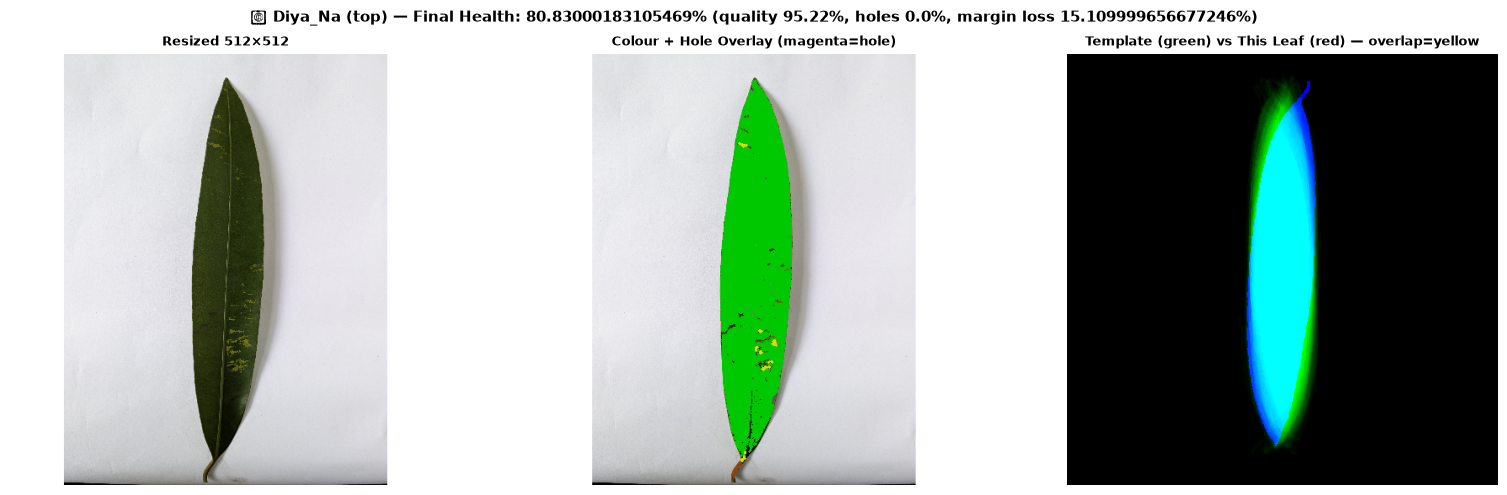

  Tissue quality (colour)   : 95.22%
  Hole area                 : 0.0%
  Margin loss               : 15.109999656677246% (template-based)
  ➜ FINAL HEALTH            : 80.83000183105469%

👉 If the template/leaf overlay looks badly misaligned (rotated wrong,
   mirrored), exclude that calibration image and re-run calibrate_species().


In [88]:
if sample_species is None:
    print('⚠️  No species folders found under HEALTH_RAW_PATH yet — add data first.')
else:
    sample_view = VIEWS[0]
    sample_imgs = get_images(HEALTH_RAW_PATH, sample_species, sample_view)

    if not sample_imgs:
        print(f'⚠️  No images found in {HEALTH_RAW_PATH}/{sample_species}/{sample_view}/')
    else:
        sample_bgr = cv2.imread(random.choice(sample_imgs))
        report = evaluate_single_view_health(sample_bgr, species=sample_species, view=sample_view)

        if report is None:
            print('⚠️  Leaf mask came back empty for this image — check segmentation params.')
        else:
            overlay = report['working_image'].copy()
            overlay[report['masks']['healthy'] > 0] = (0, 200, 0)
            overlay[report['masks']['yellow'] > 0]  = (0, 220, 220)
            overlay[report['masks']['brown'] > 0]   = (19, 69, 139)
            overlay[report['masks']['black'] > 0]   = (0, 0, 0)
            overlay[report['masks']['pale'] > 0]    = (200, 200, 255)
            overlay[report['holes_mask'] > 0]       = (255, 0, 255)

            # NEW: visualize the aligned mask next to the template (if
            # calibrated) so you can SEE whether alignment/scoring makes
            # sense, not just trust the number blindly.
            template = get_shape_template(sample_species)
            aligned = align_leaf_mask(report['leaf_mask'])

            steps = [(bgr2rgb(report['working_image']), 'Resized 512×512'),
                     (bgr2rgb(overlay), 'Colour + Hole Overlay (magenta=hole)')]

            if template is not None and aligned is not None:
                compare = np.zeros((*template.shape, 3), dtype=np.uint8)
                compare[:, :, 1] = (template * 255).astype(np.uint8)   # green = template (expected)
                compare[:, :, 2] = aligned                              # red = this leaf (actual)
                steps.append((compare, 'Template (green) vs This Leaf (red) — overlap=yellow'))
            else:
                steps.append((aligned if aligned is not None else np.zeros((400, 400), dtype=np.uint8),
                               'Aligned shape (no template calibrated yet)'))

            fig, axes = plt.subplots(1, len(steps), figsize=(16, 5))
            fig.suptitle(
                f"🌿 {sample_species} ({sample_view}) — Final Health: {report['final_health_pct']}% "
                f"(quality {report['tissue_quality_pct']}%, holes {report['hole_pct']}%, "
                f"margin loss {report['margin_loss_pct']}%)",
                fontsize=11, fontweight='bold'
            )
            for ax, (img_step, title) in zip(axes, steps):
                ax.imshow(img_step, cmap='gray' if len(img_step.shape) == 2 else None)
                ax.set_title(title, fontsize=9, fontweight='bold')
                ax.axis('off')
            plt.tight_layout()
            plt.savefig(f'{LOGS_PATH}/03_health_eval_steps.png', bbox_inches='tight', dpi=120)
            plt.show()

            print(f"  Tissue quality (colour)   : {report['tissue_quality_pct']}%")
            print(f"  Hole area                 : {report['hole_pct']}%")
            print(f"  Margin loss               : {report['margin_loss_pct']}% "
                  f"({'template-based' if template is not None else 'hull-ratio fallback'})")
            print(f"  ➜ FINAL HEALTH            : {report['final_health_pct']}%")
            print()
            print('👉 If the template/leaf overlay looks badly misaligned (rotated wrong,')
            print('   mirrored), exclude that calibration image and re-run calibrate_species().')

## Cell 10 — Combine Top + Bottom Views (view-aware thresholds, area-weighted FINAL health)

In [ ]:
def evaluate_full_leaf_health(top_bgr, bottom_bgr, species=None):
    top_report = evaluate_single_view_health(top_bgr, species=species, view='top') if top_bgr is not None else None
    bottom_report = evaluate_single_view_health(bottom_bgr, species=species, view='bottom') if bottom_bgr is not None else None

    if top_report is None and bottom_report is None:
        return None

    if top_report is None:
        combined_pct = bottom_report['final_health_pct']
    elif bottom_report is None:
        combined_pct = top_report['final_health_pct']
    else:
        top_area = top_report['leaf_area_px']
        bottom_area = bottom_report['leaf_area_px']
        combined_pct = round(
            (top_report['final_health_pct'] * top_area +
             bottom_report['final_health_pct'] * bottom_area) /
            (top_area + bottom_area),
            2
        )

    return {
        'top_final_health_pct': top_report['final_health_pct'] if top_report else None,
        'bottom_final_health_pct': bottom_report['final_health_pct'] if bottom_report else None,
        'top_leaf_area_px': top_report['leaf_area_px'] if top_report else None,
        'bottom_leaf_area_px': bottom_report['leaf_area_px'] if bottom_report else None,
        'combined_final_health_pct': combined_pct,
    }

In [ ]:
print('✅ evaluate_full_leaf_health() ready!')

## Cell 11 — Quality Control

In [ ]:
print('🔍 QUALITY CONTROL — Sampling 5 physical leaves per species')
print('=' * 62)

In [ ]:
qc_rows = []
for species in species_list:
    leaf_ids_per_view = {}
    for view in VIEWS:
        imgs = get_images(HEALTH_RAW_PATH, species, view)
        leaf_ids_per_view[view] = group_by_leaf(imgs)

    common_ids = sorted(set(leaf_ids_per_view['top']) & set(leaf_ids_per_view['bottom']))
    if not common_ids:
        print(f'  ⚠️  No paired top+bottom leaves found: {species}')
        continue

    for leaf_id in common_ids[:5]:
        top_path = leaf_ids_per_view['top'][leaf_id][0]
        bottom_path = leaf_ids_per_view['bottom'][leaf_id][0]
        top_img = cv2.imread(top_path)
        bottom_img = cv2.imread(bottom_path)

        result = evaluate_full_leaf_health(top_img, bottom_img, species=species)
        if result is None:
            qc_rows.append({'species': species, 'leaf_id': leaf_id, 'status': 'FAIL'})
            continue

        qc_rows.append({
            'species': species, 'leaf_id': leaf_id, 'status': 'PASS',
            'top_final_pct': result['top_final_health_pct'],
            'bottom_final_pct': result['bottom_final_health_pct'],
            'combined_final_pct': result['combined_final_health_pct'],
            'colour_calibrated': species in SPECIES_THRESHOLD_OVERRIDES,
            'shape_calibrated': species in SPECIES_SHAPE_TEMPLATES_B64,
        })

In [ ]:
qc_df = pd.DataFrame(qc_rows)
if len(qc_df):
    pass_rate = (qc_df.status == 'PASS').mean() * 100
    print(f'\n  Total sampled : {len(qc_df)}')
    print(f'  Pass rate     : {pass_rate:.1f}%')
    print(qc_df.to_string(index=False))
else:
    print('  ⚠️  No data to QC yet.')

## Cell 12 — Run on Full Dataset -> CSV

In [ ]:
print('🔄 Starting health evaluation on full dataset...')
print('=' * 65)

In [ ]:
results = []

In [ ]:
for species in species_list:
    leaf_ids_per_view = {}
    for view in VIEWS:
        imgs = get_images(HEALTH_RAW_PATH, species, view)
        leaf_ids_per_view[view] = group_by_leaf(imgs)

    common_ids = sorted(set(leaf_ids_per_view['top']) & set(leaf_ids_per_view['bottom']))

    for leaf_id in tqdm(common_ids, desc=f'  {species}'):
        top_path = leaf_ids_per_view['top'][leaf_id][0]
        bottom_path = leaf_ids_per_view['bottom'][leaf_id][0]

        top_img = cv2.imread(top_path)
        bottom_img = cv2.imread(bottom_path)

        result = evaluate_full_leaf_health(top_img, bottom_img, species=species)
        if result is None:
            continue

        results.append({
            'species': species,
            'leaf_id': leaf_id,
            'top_final_pct': result['top_final_health_pct'],
            'bottom_final_pct': result['bottom_final_health_pct'],
            'combined_final_pct': result['combined_final_health_pct'],
        })

        del top_img, bottom_img
    gc.collect()

In [ ]:
results_df = pd.DataFrame(results)
csv_path = os.path.join(HEALTH_RESULTS_PATH, 'leaf_health_report.csv')
results_df.to_csv(csv_path, index=False)

In [ ]:
print('=' * 65)
print(f'✅ Done! {len(results_df)} physical leaves evaluated.')
print(f'📄 Saved: {csv_path}')

## Cell 13 — Preview Results

In [ ]:
if len(results_df):
    print('📊 Average combined FINAL health % by species:')
    print(results_df.groupby('species')['combined_final_pct'].mean().round(1).to_string())
else:
    print('⚠️  No results to preview yet.')

## Cell 14 — Export Standalone Rule Module (No .pkl needed!)

In [ ]:
health_rules_source = '''# health_rules.py
"""
VedaVision Module 2 -- Health Evaluation (v4: colour + structural damage,
per-view thresholds, shape-template margin loss). Deterministic rule
pipeline -- no .pkl, this module IS the logic.

Import evaluate_full_leaf_health(top_bgr, bottom_bgr, species="Diya Na")
from your FastAPI route.
"""

import base64
import cv2
import numpy as np

WORK_SIZE = (512, 512)

DEFAULT_THRESHOLDS = ''' + repr(DEFAULT_THRESHOLDS) + '''
MIN_DAMAGE_BLOB_AREA = ''' + repr(MIN_DAMAGE_BLOB_AREA) + '''
SPECIES_THRESHOLD_OVERRIDES = ''' + repr(SPECIES_THRESHOLD_OVERRIDES) + '''

BG_COLOR_TOLERANCE = ''' + repr(BG_COLOR_TOLERANCE) + '''
HOLE_BRIDGE_BREAK_PX = ''' + repr(HOLE_BRIDGE_BREAK_PX) + '''

SHAPE_CANVAS_SIZE = ''' + repr(SHAPE_CANVAS_SIZE) + '''
SHAPE_TARGET_LENGTH = ''' + repr(SHAPE_TARGET_LENGTH) + '''

DEFAULT_HULL_RATIO_BASELINE = ''' + repr(DEFAULT_HULL_RATIO_BASELINE) + '''
SPECIES_HULL_BASELINE = ''' + repr(SPECIES_HULL_BASELINE) + '''
SPECIES_SHAPE_TEMPLATES_B64 = ''' + repr(SPECIES_SHAPE_TEMPLATES_B64) + '''


def get_thresholds(species=None, view=None):
    t = dict(DEFAULT_THRESHOLDS)
    species_over = SPECIES_THRESHOLD_OVERRIDES.get(species, {})
    view_over = species_over.get(view, {}) if view else {}
    t.update(view_over)
    return t


def get_hull_baseline(species=None):
    return SPECIES_HULL_BASELINE.get(species, DEFAULT_HULL_RATIO_BASELINE)


def get_shape_template(species=None):
    b64 = SPECIES_SHAPE_TEMPLATES_B64.get(species)
    if b64 is None:
        return None
    png_bytes = base64.b64decode(b64)
    arr = np.frombuffer(png_bytes, dtype=np.uint8)
    template = cv2.imdecode(arr, cv2.IMREAD_GRAYSCALE)
    if template is None:
        return None
    return template.astype(np.float32) / 255.0


def resize_with_padding(image, target_size, pad_value=255):
    h, w = image.shape[:2]
    target_w, target_h = target_size
    scale = min(target_w / w, target_h / h)
    new_w, new_h = int(round(w * scale)), int(round(h * scale))
    resized = cv2.resize(image, (new_w, new_h))
    canvas = np.full((target_h, target_w, 3), pad_value, dtype=np.uint8)
    x_off = (target_w - new_w) // 2
    y_off = (target_h - new_h) // 2
    canvas[y_off:y_off + new_h, x_off:x_off + new_w] = resized
    return canvas


def get_border_connected_background(candidate_bg, bridge_break_px=7):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (bridge_break_px, bridge_break_px))
    eroded_bg = cv2.erode(candidate_bg, kernel)
    h, w = eroded_bg.shape
    padded = cv2.copyMakeBorder(eroded_bg, 1, 1, 1, 1, cv2.BORDER_CONSTANT, value=255)
    flood_seed = np.zeros((h + 4, w + 4), np.uint8)
    filled = padded.copy()
    cv2.floodFill(filled, flood_seed, (0, 0), 128)
    border_bg = ((filled == 128).astype(np.uint8) * 255)[1:-1, 1:-1]
    border_bg = cv2.dilate(border_bg, kernel)
    border_bg = cv2.bitwise_and(border_bg, candidate_bg)
    return border_bg


def remove_small_blobs(mask, min_area=100):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    clean = np.zeros_like(mask)
    for label in range(1, num_labels):
        if stats[label, cv2.CC_STAT_AREA] >= min_area:
            clean[labels == label] = 255
    return clean


def keep_largest_contours(mask, keep_ratio=0.05, min_absolute_area=1500):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return mask
    areas = [cv2.contourArea(c) for c in contours]
    largest_area = max(areas)
    clean = np.zeros_like(mask)
    for c, a in zip(contours, areas):
        if a >= largest_area * keep_ratio or a >= min_absolute_area:
            cv2.drawContours(clean, [c], -1, 255, thickness=cv2.FILLED)
    return clean


def segment_leaf(image, dark_v_thresh=90, min_shadow_area=200, max_artifact_area=150,
                  bridge_break_px=7, morph_kernel_size=3, min_blob_area=100,
                  otsu_relax_factor=0.8):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    s = hsv[:, :, 1]
    v = hsv[:, :, 2]

    otsu_thresh, _ = cv2.threshold(s, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    relaxed_thresh = otsu_thresh * otsu_relax_factor
    _, candidate_leaf = cv2.threshold(s, relaxed_thresh, 255, cv2.THRESH_BINARY)
    candidate_bg = cv2.bitwise_not(candidate_leaf)

    border_bg = get_border_connected_background(candidate_bg, bridge_break_px)
    enclosed = cv2.bitwise_and(candidate_bg, cv2.bitwise_not(border_bg))

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(enclosed, connectivity=8)
    dark_enclosed = np.zeros_like(enclosed)
    undecided = []

    for label in range(1, num_labels):
        comp = (labels == label)
        area = stats[label, cv2.CC_STAT_AREA]
        if area < min_shadow_area:
            undecided.append(label)
            continue
        if np.median(v[comp]) < dark_v_thresh:
            dark_enclosed[comp] = 255
        else:
            undecided.append(label)

    kernel_adj = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    dilated_dark = cv2.dilate(dark_enclosed, kernel_adj, iterations=1)

    for label in undecided:
        comp = (labels == label)
        area = stats[label, cv2.CC_STAT_AREA]
        if area < max_artifact_area and np.any(dilated_dark[comp]):
            dark_enclosed[comp] = 255

    background_mask = cv2.bitwise_or(border_bg, dark_enclosed)
    leaf_mask = cv2.bitwise_not(background_mask)
    leaf_mask = remove_small_blobs(leaf_mask, min_area=min_blob_area)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_kernel_size, morph_kernel_size))
    leaf_mask = cv2.morphologyEx(leaf_mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    leaf_mask = cv2.morphologyEx(leaf_mask, cv2.MORPH_OPEN, kernel, iterations=1)

    leaf_mask = keep_largest_contours(leaf_mask)
    return leaf_mask


def get_background_reference_color(image_bgr, sample_size=20):
    h, w = image_bgr.shape[:2]
    patches = [
        image_bgr[0:sample_size, 0:sample_size],
        image_bgr[0:sample_size, w - sample_size:w],
        image_bgr[h - sample_size:h, 0:sample_size],
        image_bgr[h - sample_size:h, w - sample_size:w],
    ]
    all_px = np.concatenate([p.reshape(-1, 3) for p in patches], axis=0)
    return np.median(all_px, axis=0)


def detect_holes(image_bgr, leaf_mask, bg_color,
                  color_tolerance=BG_COLOR_TOLERANCE,
                  bridge_break_px=HOLE_BRIDGE_BREAK_PX):
    diff = np.linalg.norm(image_bgr.astype(np.float32) - bg_color.astype(np.float32), axis=2)
    is_bg_color = (diff <= color_tolerance).astype(np.uint8) * 255
    true_exterior = get_border_connected_background(is_bg_color, bridge_break_px)
    holes = cv2.bitwise_and(is_bg_color, cv2.bitwise_not(true_exterior))
    holes = cv2.bitwise_and(holes, leaf_mask)
    holes = remove_small_blobs(holes, min_area=10)
    return holes


def align_leaf_mask(mask, canvas_size=SHAPE_CANVAS_SIZE, target_length=SHAPE_TARGET_LENGTH):
    ys, xs = np.nonzero(mask)
    if len(xs) < 50:
        return None

    coords = np.stack([xs, ys], axis=1).astype(np.float64)
    mean = coords.mean(axis=0)
    centered = coords - mean
    cov = np.cov(centered.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    major = eigvecs[:, np.argmax(eigvals)]
    angle_deg = np.degrees(np.arctan2(major[1], major[0]))
    rotation_angle = 90 - angle_deg

    proj = centered @ major
    length = proj.max() - proj.min()
    if length <= 0:
        return None
    scale = target_length / length

    cx, cy = mean
    M = cv2.getRotationMatrix2D((cx, cy), rotation_angle, scale)
    M[0, 2] += canvas_size / 2 - cx
    M[1, 2] += canvas_size / 2 - cy
    aligned = cv2.warpAffine(mask, M, (canvas_size, canvas_size),
                              flags=cv2.INTER_NEAREST, borderValue=0)

    ys2 = np.nonzero(aligned)[0]
    if len(ys2) == 0:
        return None
    y_min, y_max = ys2.min(), ys2.max()
    span = y_max - y_min
    if span >= 10:
        band = max(1, span // 10)
        top_width = np.count_nonzero(aligned[y_min:y_min + band, :].any(axis=0))
        bottom_width = np.count_nonzero(aligned[y_max - band:y_max + 1, :].any(axis=0))
        if bottom_width < top_width:
            aligned = cv2.rotate(aligned, cv2.ROTATE_180)

    return aligned


def score_against_template(leaf_mask, template, canvas_size=SHAPE_CANVAS_SIZE, target_length=SHAPE_TARGET_LENGTH):
    aligned = align_leaf_mask(leaf_mask, canvas_size, target_length)
    if aligned is None:
        return None
    present = (aligned > 0).astype(np.float32)
    expected_mass = template.sum()
    if expected_mass == 0:
        return 0.0
    present_and_expected = (template * present).sum()
    coverage_ratio = present_and_expected / expected_mass
    loss_pct = max(0.0, (1 - coverage_ratio) * 100)
    return round(min(loss_pct, 100.0), 2)


def compute_hull_ratio(leaf_mask):
    contours, _ = cv2.findContours(leaf_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None, 0, 0
    largest = max(contours, key=cv2.contourArea)
    leaf_area = cv2.contourArea(largest)
    hull = cv2.convexHull(largest)
    hull_area = cv2.contourArea(hull)
    if hull_area == 0:
        return None, leaf_area, 0
    return leaf_area / hull_area, leaf_area, hull_area


def estimate_margin_loss_pct(leaf_mask, species=None):
    template = get_shape_template(species)
    if template is not None:
        score = score_against_template(leaf_mask, template)
        if score is not None:
            return score
    ratio, leaf_area, hull_area = compute_hull_ratio(leaf_mask)
    if ratio is None:
        return 0.0
    baseline = get_hull_baseline(species)
    loss_pct = max(0.0, (baseline - ratio) / baseline * 100)
    return round(min(loss_pct, 100.0), 2)


def build_health_masks(image_bgr, tissue_mask, thresholds):
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    h, s, v = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]
    tissue_bool = tissue_mask > 0

    def to_mask(bool_arr):
        return (bool_arr & tissue_bool).astype(np.uint8) * 255

    hh = thresholds["HEALTHY_HUE_RANGE"]
    yh = thresholds["YELLOW_HUE_RANGE"]
    bh = thresholds["BROWN_HUE_RANGE"]

    healthy = to_mask((h >= hh[0]) & (h <= hh[1]) &
                       (s >= thresholds["HEALTHY_MIN_SAT"]) &
                       (v >= thresholds["HEALTHY_MIN_VAL"]))
    yellow = to_mask((h >= yh[0]) & (h <= yh[1]) & (s >= thresholds["YELLOW_MIN_SAT"]))
    brown = to_mask((h >= bh[0]) & (h <= bh[1]) & (v <= thresholds["BROWN_MAX_VAL"]))
    black = to_mask((v <= thresholds["BLACK_MAX_VAL"]) & (s <= thresholds["BLACK_MAX_SAT"]))
    pale = to_mask((s <= thresholds["PALE_MAX_SAT"]) & (v >= thresholds["PALE_MIN_VAL"]))

    yellow = cv2.bitwise_and(yellow, cv2.bitwise_not(healthy))
    brown = cv2.bitwise_and(brown, cv2.bitwise_not(healthy))
    black = cv2.bitwise_and(black, cv2.bitwise_not(healthy))
    pale = cv2.bitwise_and(pale, cv2.bitwise_not(healthy))

    brown = cv2.bitwise_and(brown, cv2.bitwise_not(black))
    pale = cv2.bitwise_and(pale, cv2.bitwise_not(black))
    yellow = cv2.bitwise_and(yellow, cv2.bitwise_not(black))

    pale = cv2.bitwise_and(pale, cv2.bitwise_not(brown))
    yellow = cv2.bitwise_and(yellow, cv2.bitwise_not(brown))

    yellow = cv2.bitwise_and(yellow, cv2.bitwise_not(pale))

    return {"healthy": healthy, "yellow": yellow, "brown": brown, "black": black, "pale": pale}


def clean_health_masks(masks, min_area=MIN_DAMAGE_BLOB_AREA):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    cleaned = {}
    for name, mask in masks.items():
        opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
        cleaned[name] = remove_small_blobs(opened, min_area=min_area)
    return cleaned


def evaluate_single_view_health(image_bgr, species=None, view=None):
    thresholds = get_thresholds(species, view)

    bg_color = get_background_reference_color(image_bgr)

    img = resize_with_padding(image_bgr, WORK_SIZE)
    leaf_mask = segment_leaf(img)

    leaf_silhouette_px = int(cv2.countNonZero(leaf_mask))
    if leaf_silhouette_px == 0:
        return None

    holes_mask = detect_holes(img, leaf_mask, bg_color)
    hole_px = int(cv2.countNonZero(holes_mask))

    tissue_mask = cv2.bitwise_and(leaf_mask, cv2.bitwise_not(holes_mask))
    tissue_px = int(cv2.countNonZero(tissue_mask))
    if tissue_px == 0:
        return None

    masks = build_health_masks(img, tissue_mask, thresholds)
    masks = clean_health_masks(masks)
    counts = {name: int(cv2.countNonZero(m)) for name, m in masks.items()}
    damage_px = counts["yellow"] + counts["brown"] + counts["black"] + counts["pale"]
    unclassified_px = max(0, tissue_px - counts["healthy"] - damage_px)

    tissue_quality_pct = round(counts["healthy"] / tissue_px * 100, 2)
    hole_pct = round(hole_px / leaf_silhouette_px * 100, 2)
    margin_loss_pct = estimate_margin_loss_pct(leaf_mask, species=species)

    final_health_pct = round(
        tissue_quality_pct * (1 - hole_pct / 100) * (1 - margin_loss_pct / 100), 2
    )

    return {
        "leaf_area_px": leaf_silhouette_px,
        "tissue_quality_pct": tissue_quality_pct,
        "yellow_pct": round(counts["yellow"] / tissue_px * 100, 2),
        "brown_pct": round(counts["brown"] / tissue_px * 100, 2),
        "black_pct": round(counts["black"] / tissue_px * 100, 2),
        "pale_pct": round(counts["pale"] / tissue_px * 100, 2),
        "unclassified_pct": round(unclassified_px / tissue_px * 100, 2),
        "hole_pct": hole_pct,
        "margin_loss_pct": margin_loss_pct,
        "final_health_pct": final_health_pct,
    }


def evaluate_full_leaf_health(top_bgr, bottom_bgr, species=None):
    top_report = evaluate_single_view_health(top_bgr, species=species, view="top") if top_bgr is not None else None
    bottom_report = evaluate_single_view_health(bottom_bgr, species=species, view="bottom") if bottom_bgr is not None else None

    if top_report is None and bottom_report is None:
        return None

    if top_report is None:
        combined_pct = bottom_report["final_health_pct"]
    elif bottom_report is None:
        combined_pct = top_report["final_health_pct"]
    else:
        top_area = top_report["leaf_area_px"]
        bottom_area = bottom_report["leaf_area_px"]
        combined_pct = round(
            (top_report["final_health_pct"] * top_area + bottom_report["final_health_pct"] * bottom_area)
            / (top_area + bottom_area),
            2,
        )

    return {
        "top": top_report,
        "bottom": bottom_report,
        "combined_final_health_pct": combined_pct,
    }
'''

In [ ]:
module_out_path = os.path.join(HEALTH_RESULTS_PATH, 'health_rules.py')
with open(module_out_path, 'w') as f:
    f.write(health_rules_source)

In [ ]:
print(f'✅ Exported: {module_out_path}')
print(f'   Species colour-calibrated : {list(SPECIES_THRESHOLD_OVERRIDES.keys())}')
print(f'   Species shape-calibrated  : {list(SPECIES_SHAPE_TEMPLATES_B64.keys())}')

## Cell 15 — Sanity Test the Exported Module

In [ ]:
import importlib.util

In [ ]:
spec = importlib.util.spec_from_file_location('health_rules', module_out_path)
health_rules = importlib.util.module_from_spec(spec)
spec.loader.exec_module(health_rules)

In [ ]:
if sample_species is not None and sample_imgs:
    notebook_result = evaluate_single_view_health(sample_bgr, species=sample_species, view=sample_view)
    module_result = health_rules.evaluate_single_view_health(sample_bgr, species=sample_species, view=sample_view)

    if notebook_result and module_result:
        match = notebook_result['final_health_pct'] == module_result['final_health_pct']
        print(f"  Notebook final health % : {notebook_result['final_health_pct']}")
        print(f"  Module   final health % : {module_result['final_health_pct']}")
        print('  ✅ MATCH — health_rules.py is ready to deploy!' if match else
              '  ⚠️  MISMATCH — re-run Cell 14 to re-export, then retest.')
else:
    print('⚠️  No sample image available to sanity-check against.')

## Cell 16 — Summary

In [ ]:
print('📊 HEALTH EVALUATION SUMMARY')
print('=' * 55)
if len(results_df):
    print(f'  Physical leaves evaluated : {len(results_df)}')
    print(f'  Species covered           : {results_df["species"].nunique()}')
    print(f'  Mean FINAL health %       : {results_df["combined_final_pct"].mean():.1f}%')
else:
    print('  No results yet -- run Cells 11-12 once HEALTH_RAW_PATH has data.')
print('=' * 55)
print(f'📁 CSV    : {os.path.join(HEALTH_RESULTS_PATH, "leaf_health_report.csv")}')
print(f'📁 Module : {os.path.join(HEALTH_RESULTS_PATH, "health_rules.py")}')
print('📋 Next step: calibrate_species(name) per species, paste threshold AND')
print('             template results into Cell 3, re-run Cell 14 to re-export.')